In [1]:
# ============================================================
# PHASE 1 — SECTION 1
# Environment & Reproducibility
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

print("Phase 1 environment initialised successfully.")
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Random seed:", SEED)

/opt/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Phase 1 environment initialised successfully.
NumPy version: 1.26.4
Pandas version: 3.0.5
Random seed: 42


In [2]:
# ============================================================
# PHASE 1 — SECTION 2
# Load and Inspect Original UAV Dataset
# ============================================================

# Update this filename/path only if your original dataset
# has a different name or location.
DATA_PATH = "uav_navigation_dataset.csv"

# Load dataset
df_raw = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("\nShape:", df_raw.shape)

print("\nColumns:")
print(df_raw.columns.tolist())

print("\nFirst 5 rows:")
display(df_raw.head())

print("\nData types:")
print(df_raw.dtypes)

print("\nMissing values:")
print(df_raw.isnull().sum())

Dataset loaded successfully.

Shape: (5000, 15)

Columns:
['timestamp', 'latitude', 'longitude', 'altitude', 'imu_acc_x', 'imu_acc_y', 'imu_acc_z', 'imu_gyro_x', 'imu_gyro_y', 'imu_gyro_z', 'lidar_distance', 'speed', 'wind_speed', 'battery_level', 'obstacle_detected']

First 5 rows:


,timestamp,latitude,longitude,altitude,imu_acc_x,imu_acc_y,imu_acc_z,imu_gyro_x,imu_gyro_y,imu_gyro_z,lidar_distance,speed,wind_speed,battery_level,obstacle_detected
0,2023-01-01 00:00:00,37.772391,-122.421527,218.138368,-0.001979,1.379990,-2.445775,49.732045,39.381347,-72.391665,33.328274,26.180914,1.768356,79.324416,0
1,2023-01-01 00:00:01,37.783914,-122.419931,199.810443,1.480481,-1.892928,-2.635478,-14.654717,-165.994752,-145.865601,81.765473,17.362926,0.287489,90.488150,0
2,2023-01-01 00:00:02,37.779540,-122.412309,129.269261,0.376001,-0.920162,0.625152,167.219469,40.413723,-134.510679,99.440493,9.886640,14.688221,57.054390,0
3,2023-01-01 00:00:03,37.776873,-122.422600,323.270002,-2.500185,0.979684,2.796698,-101.167758,-147.719302,-114.958394,84.155773,23.416045,5.234081,43.134299,0
4,2023-01-01 00:00:04,37.768020,-122.412007,264.480872,-1.886519,-0.107464,0.016328,31.628310,75.723926,-106.684800,34.941221,15.466953,17.553565,45.507726,0



Data types:
timestamp                str
latitude             float64
longitude            float64
altitude             float64
imu_acc_x            float64
imu_acc_y            float64
imu_acc_z            float64
imu_gyro_x           float64
imu_gyro_y           float64
imu_gyro_z           float64
lidar_distance       float64
speed                float64
wind_speed           float64
battery_level        float64
obstacle_detected      int64
dtype: object

Missing values:
timestamp            0
latitude             0
longitude            0
altitude             0
imu_acc_x            0
imu_acc_y            0
imu_acc_z            0
imu_gyro_x           0
imu_gyro_y           0
imu_gyro_z           0
lidar_distance       0
speed                0
wind_speed           0
battery_level        0
obstacle_detected    0
dtype: int64


In [3]:
# ============================================================
# PHASE 1 — SECTION 3
# Source Temporal Integrity Validation
# ============================================================

# Work on a copy so the original dataframe remains unchanged
df_source = df_raw.copy()

# Convert timestamp to datetime
df_source["timestamp"] = pd.to_datetime(
    df_source["timestamp"],
    errors="coerce"
)

# Check timestamp conversion
print("Invalid timestamps:", df_source["timestamp"].isna().sum())

# Sort chronologically
df_source = df_source.sort_values("timestamp").reset_index(drop=True)

# Calculate time differences
time_diff = df_source["timestamp"].diff().dt.total_seconds()

# Remove the first NaN created by diff()
time_diff_valid = time_diff.dropna()

print("\n--- Temporal Integrity ---")
print("First timestamp:", df_source["timestamp"].iloc[0])
print("Last timestamp:", df_source["timestamp"].iloc[-1])

print("\nNumber of rows:", len(df_source))
print("Unique timestamps:", df_source["timestamp"].nunique())
print("Duplicate timestamps:", df_source["timestamp"].duplicated().sum())

print("\nTime interval distribution (seconds):")
print(time_diff_valid.value_counts().sort_index())

print("\nMinimum interval:", time_diff_valid.min(), "seconds")
print("Maximum interval:", time_diff_valid.max(), "seconds")
print("Median interval:", time_diff_valid.median(), "seconds")

print("\nDuplicate complete rows:", df_source.duplicated().sum())

# Chronological ordering check
is_chronological = df_source["timestamp"].is_monotonic_increasing

print("\nChronologically ordered:", is_chronological)

Invalid timestamps: 0

--- Temporal Integrity ---
First timestamp: 2023-01-01 00:00:00
Last timestamp: 2023-01-01 01:23:19

Number of rows: 5000
Unique timestamps: 5000
Duplicate timestamps: 0

Time interval distribution (seconds):
timestamp
1.0    4999
Name: count, dtype: int64

Minimum interval: 1.0 seconds
Maximum interval: 1.0 seconds
Median interval: 1.0 seconds

Duplicate complete rows: 0

Chronologically ordered: True


In [4]:
# ============================================================
# PHASE 1 — SECTION 4
# Source Dataset Statistical & Physical Validation
# ============================================================

# Numerical columns
numeric_columns = df_source.select_dtypes(
    include=[np.number]
).columns.tolist()

print("Numerical columns:")
print(numeric_columns)

# Descriptive statistics
print("\n--- Descriptive Statistics ---")
display(
    df_source[numeric_columns]
    .describe()
    .T
    .round(4)
)

# Check infinite values
inf_counts = np.isinf(
    df_source[numeric_columns].to_numpy()
).sum(axis=0)

inf_check = pd.Series(
    inf_counts,
    index=numeric_columns
)

print("\n--- Infinite Value Check ---")
print(inf_check)

# Check constant columns
constant_columns = [
    col for col in numeric_columns
    if df_source[col].nunique() <= 1
]

print("\nConstant numerical columns:")
print(constant_columns)

# Check categorical/binary columns
print("\n--- Unique Values in Non-continuous Columns ---")

for col in ["obstacle_detected"]:
    if col in df_source.columns:
        print(f"{col}: {sorted(df_source[col].dropna().unique().tolist())}")

# Explicit navigation/sensor ranges
range_columns = [
    "latitude",
    "longitude",
    "altitude",
    "speed",
    "imu_acc_x",
    "imu_acc_y",
    "imu_acc_z",
    "imu_gyro_x",
    "imu_gyro_y",
    "imu_gyro_z",
    "lidar_distance",
    "wind_speed",
    "battery_level"
]

print("\n--- Key Feature Ranges ---")

for col in range_columns:
    if col in df_source.columns:
        print(
            f"{col:20s} "
            f"min={df_source[col].min():.4f}, "
            f"max={df_source[col].max():.4f}, "
            f"mean={df_source[col].mean():.4f}"
        )

Numerical columns:
['latitude', 'longitude', 'altitude', 'imu_acc_x', 'imu_acc_y', 'imu_acc_z', 'imu_gyro_x', 'imu_gyro_y', 'imu_gyro_z', 'lidar_distance', 'speed', 'wind_speed', 'battery_level', 'obstacle_detected']

--- Descriptive Statistics ---


,count,mean,std,min,25%,50%,75%,max
latitude,5000.0,37.7748,0.0058,37.7649,37.7698,37.7749,37.7799,37.7849
longitude,5000.0,-122.4196,0.0057,-122.4294,-122.4245,-122.4197,-122.4147,-122.4094
altitude,5000.0,275.6188,130.8464,50.0710,161.2253,273.2887,392.2786,499.9123
imu_acc_x,5000.0,0.0461,1.7268,-2.9985,-1.4236,0.0747,1.5066,2.9995
imu_acc_y,5000.0,0.0527,1.7324,-2.9997,-1.4466,0.0800,1.5462,2.9994
imu_acc_z,5000.0,-0.0521,1.7073,-2.9993,-1.5171,-0.0541,1.3929,2.9984
imu_gyro_x,5000.0,0.2211,103.7972,-179.9980,-90.8913,0.6844,89.3616,179.9242
imu_gyro_y,5000.0,-1.1475,104.2843,-179.9352,-91.3618,-0.5937,88.9123,179.7367
imu_gyro_z,5000.0,-0.5558,104.1469,-179.9940,-90.6545,-3.1055,91.2511,179.9900
lidar_distance,5000.0,49.7795,28.7845,0.5104,24.5730,49.8449,74.9408,99.9957



--- Infinite Value Check ---
latitude             0
longitude            0
altitude             0
imu_acc_x            0
imu_acc_y            0
imu_acc_z            0
imu_gyro_x           0
imu_gyro_y           0
imu_gyro_z           0
lidar_distance       0
speed                0
wind_speed           0
battery_level        0
obstacle_detected    0
dtype: int64

Constant numerical columns:
[]

--- Unique Values in Non-continuous Columns ---
obstacle_detected: [0, 1]

--- Key Feature Ranges ---
latitude             min=37.7649, max=37.7849, mean=37.7748
longitude            min=-122.4294, max=-122.4094, mean=-122.4196
altitude             min=50.0710, max=499.9123, mean=275.6188
speed                min=5.0097, max=29.9960, mean=17.6039
imu_acc_x            min=-2.9985, max=2.9995, mean=0.0461
imu_acc_y            min=-2.9997, max=2.9994, mean=0.0527
imu_acc_z            min=-2.9993, max=2.9984, mean=-0.0521
imu_gyro_x           min=-179.9980, max=179.9242, mean=0.2211
imu_gyro_y      

Source trajectory temporal dynamics calculated.

--- Frame-to-Frame Change Statistics ---


,count,mean,std,min,25%,50%,75%,max
latitude_delta,4999.0,0.000001,0.008181,-0.019344,-0.005839,-0.000039,0.005960,0.019779
longitude_delta,4999.0,-0.000001,0.008193,-0.019475,-0.005782,0.000086,0.005859,0.019911
altitude_delta,4999.0,-0.011033,184.083384,-447.611947,-129.641889,-1.324745,133.146330,443.855207
speed_delta,4999.0,-0.000285,10.126587,-24.256533,-7.352012,0.178234,7.214931,24.416737
imu_acc_x_delta,4999.0,-0.000393,2.429098,-5.945596,-1.752683,0.003880,1.735197,5.899400
imu_acc_y_delta,4999.0,0.000266,2.445594,-5.949314,-1.776863,0.033398,1.776626,5.865956
imu_acc_z_delta,4999.0,0.000198,2.425978,-5.854321,-1.713692,0.041647,1.770956,5.925637
imu_gyro_x_delta,4999.0,0.019195,146.756005,-359.273456,-105.584510,1.611929,106.440715,351.328193
imu_gyro_y_delta,4999.0,-0.008784,147.640639,-349.966871,-103.152865,-0.305591,107.486102,358.115172
imu_gyro_z_delta,4999.0,0.039920,146.474247,-351.156062,-101.194339,-0.497397,104.704750,351.699503



--- Maximum Absolute Frame-to-Frame Changes ---


altitude_delta      447.611947
imu_gyro_x_delta    359.273456
imu_gyro_y_delta    358.115172
imu_gyro_z_delta    351.699503
speed_delta          24.416737
imu_acc_y_delta       5.949314
imu_acc_x_delta       5.945596
imu_acc_z_delta       5.925637
longitude_delta       0.019911
latitude_delta        0.019779
dtype: float64


--- Largest Position Changes ---


,latitude_delta,longitude_delta,altitude_delta
2529,0.019779,0.007621,192.186673
3913,0.019440,0.013136,138.550030
1074,0.019397,0.003072,114.604630
3503,0.019344,0.013832,48.706503
3925,0.019291,0.008737,167.851532
4327,0.019209,0.010941,17.665801
1426,0.019204,0.015813,119.175455
4743,0.019175,0.003357,170.313559
471,0.019154,0.007488,126.411184
3710,0.019062,0.001648,172.614996


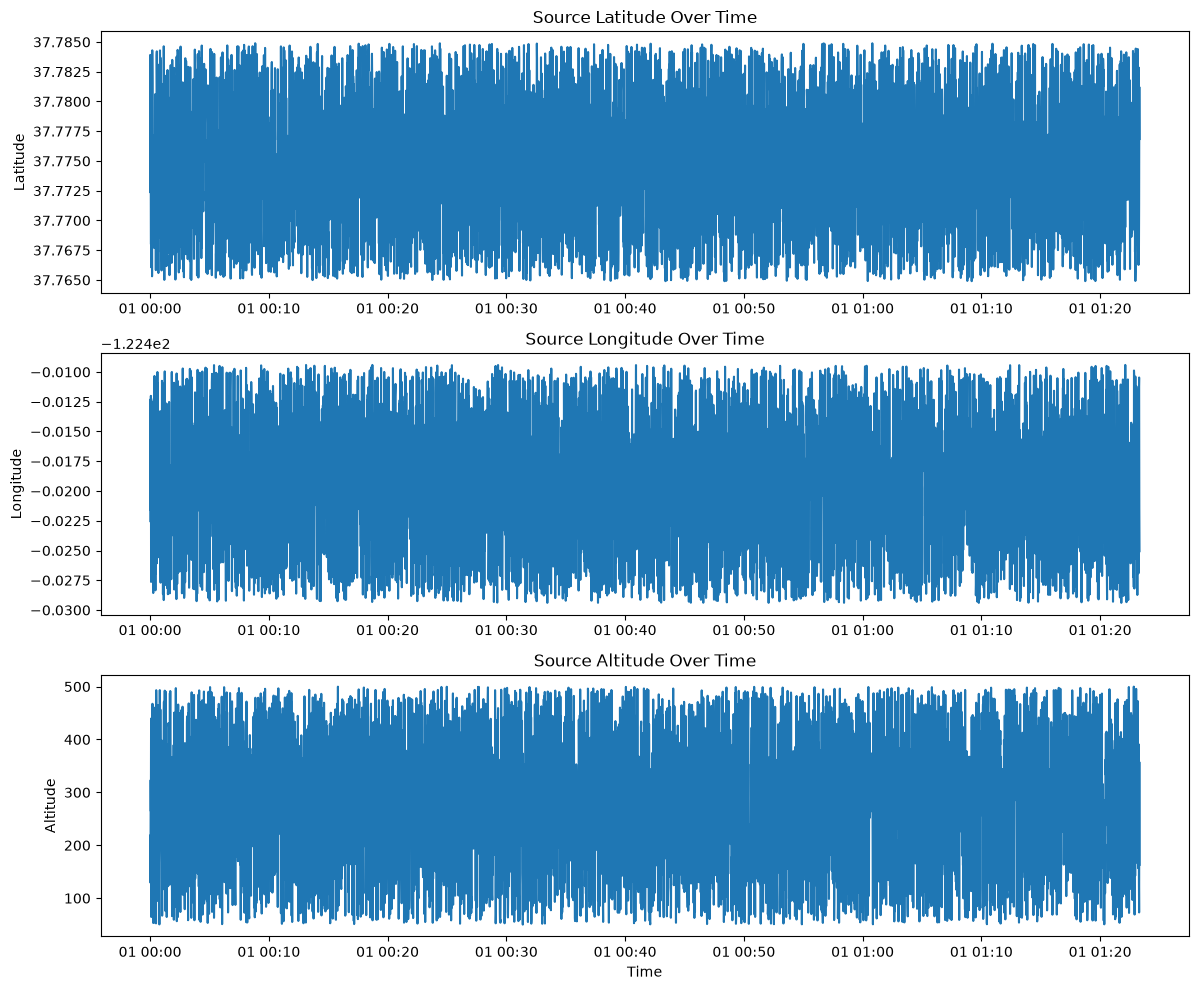

In [5]:
# ============================================================
# PHASE 1 — SECTION 5
# Source Flight Temporal Dynamics
# ============================================================

# Columns representing the main trajectory and motion variables
temporal_features = [
    "latitude",
    "longitude",
    "altitude",
    "speed",
    "imu_acc_x",
    "imu_acc_y",
    "imu_acc_z",
    "imu_gyro_x",
    "imu_gyro_y",
    "imu_gyro_z"
]

# Calculate first differences to understand natural movement
df_dynamics = df_source.copy()

for col in temporal_features:
    df_dynamics[f"{col}_delta"] = df_dynamics[col].diff()

print("Source trajectory temporal dynamics calculated.")

# ------------------------------------------------------------
# 1. Summary of natural frame-to-frame changes
# ------------------------------------------------------------

delta_columns = [f"{col}_delta" for col in temporal_features]

print("\n--- Frame-to-Frame Change Statistics ---")

display(
    df_dynamics[delta_columns]
    .describe()
    .T
    .round(6)
)

# ------------------------------------------------------------
# 2. Maximum natural changes
# ------------------------------------------------------------

print("\n--- Maximum Absolute Frame-to-Frame Changes ---")

max_changes = (
    df_dynamics[delta_columns]
    .abs()
    .max()
    .sort_values(ascending=False)
)

display(max_changes.round(6))

# ------------------------------------------------------------
# 3. Check whether any major discontinuities already exist
# ------------------------------------------------------------

print("\n--- Largest Position Changes ---")

position_delta_columns = [
    "latitude_delta",
    "longitude_delta",
    "altitude_delta"
]

display(
    df_dynamics[position_delta_columns]
    .abs()
    .sort_values(
        by=position_delta_columns,
        ascending=False
    )
    .head(10)
)

# ------------------------------------------------------------
# 4. Plot the original trajectory
# ------------------------------------------------------------

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

axes[0].plot(
    df_source["timestamp"],
    df_source["latitude"]
)

axes[0].set_title("Source Latitude Over Time")
axes[0].set_ylabel("Latitude")

axes[1].plot(
    df_source["timestamp"],
    df_source["longitude"]
)

axes[1].set_title("Source Longitude Over Time")
axes[1].set_ylabel("Longitude")

axes[2].plot(
    df_source["timestamp"],
    df_source["altitude"]
)

axes[2].set_title("Source Altitude Over Time")
axes[2].set_ylabel("Altitude")
axes[2].set_xlabel("Time")

plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# PHASE 1 — SECTION 6
# ATTACK SCENARIO CONFIGURATION
#
# Purpose:
# Define the controlled synthetic attack scenarios required
# by the research proposal before generating attack data.
#
# Required classes:
#   0 = Normal
#   1 = Spoofing
#   2 = Jamming
#
# Required spoofing mechanisms:
#   - Gradual drift
#   - Sudden jump
#
# Required jamming mechanisms:
#   - Noise injection
#   - Signal loss / freezing
# ============================================================

print("=" * 70)
print("PHASE 1 — SECTION 6")
print("ATTACK SCENARIO CONFIGURATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Class definitions
# ------------------------------------------------------------

NORMAL_LABEL = 0
SPOOFING_LABEL = 1
JAMMING_LABEL = 2

class_names = {
    NORMAL_LABEL: "Normal",
    SPOOFING_LABEL: "Spoofing",
    JAMMING_LABEL: "Jamming"
}

# ------------------------------------------------------------
# 2. Required dataset distribution
# ------------------------------------------------------------

TOTAL_SAMPLES = len(df_source)

NORMAL_RATIO = 0.60
SPOOFING_RATIO = 0.20
JAMMING_RATIO = 0.20

normal_samples = int(TOTAL_SAMPLES * NORMAL_RATIO)
spoofing_samples = int(TOTAL_SAMPLES * SPOOFING_RATIO)
jamming_samples = int(TOTAL_SAMPLES * JAMMING_RATIO)

print("\nDataset distribution target:")
print(f"Total samples : {TOTAL_SAMPLES}")
print(f"Normal        : {normal_samples} ({NORMAL_RATIO:.0%})")
print(f"Spoofing      : {spoofing_samples} ({SPOOFING_RATIO:.0%})")
print(f"Jamming       : {jamming_samples} ({JAMMING_RATIO:.0%})")

assert (
    normal_samples + spoofing_samples + jamming_samples
    == TOTAL_SAMPLES
), "Class sample counts do not sum to total samples."

# ------------------------------------------------------------
# 3. Spoofing scenarios
# ------------------------------------------------------------

SPOOFING_SCENARIOS = {
    "gradual_drift": {
        "label": SPOOFING_LABEL,
        "description": (
            "Gradual GNSS position drift designed to represent "
            "stealthy coordinate dragging."
        )
    },
    "sudden_jump": {
        "label": SPOOFING_LABEL,
        "description": (
            "Sudden GNSS position displacement representing "
            "an abrupt spoofing event."
        )
    }
}

# ------------------------------------------------------------
# 4. Jamming scenarios
# ------------------------------------------------------------

JAMMING_SCENARIOS = {
    "noise_injection": {
        "label": JAMMING_LABEL,
        "description": (
            "GNSS measurement corruption through controlled "
            "noise injection."
        )
    },
    "signal_loss_freezing": {
        "label": JAMMING_LABEL,
        "description": (
            "GNSS signal loss represented by measurement "
            "freezing during the attack interval."
        )
    }
}

# ------------------------------------------------------------
# 5. Configuration summary
# ------------------------------------------------------------

print("\nSpoofing scenarios:")
for name, config in SPOOFING_SCENARIOS.items():
    print(f"  - {name}: {config['description']}")

print("\nJamming scenarios:")
for name, config in JAMMING_SCENARIOS.items():
    print(f"  - {name}: {config['description']}")

# ------------------------------------------------------------
# 6. Proposal-alignment checks
# ------------------------------------------------------------

assert NORMAL_LABEL == 0
assert SPOOFING_LABEL == 1
assert JAMMING_LABEL == 2

assert len(SPOOFING_SCENARIOS) == 2
assert "gradual_drift" in SPOOFING_SCENARIOS
assert "sudden_jump" in SPOOFING_SCENARIOS

assert len(JAMMING_SCENARIOS) == 2
assert "noise_injection" in JAMMING_SCENARIOS
assert "signal_loss_freezing" in JAMMING_SCENARIOS

print("\n" + "=" * 70)
print("SECTION 6 — CONFIGURATION PASSED")
print("=" * 70)
print("Normal    : 60%")
print("Spoofing  : 20%")
print("Jamming   : 20%")
print("Spoofing mechanisms : Drift + Jump")
print("Jamming mechanisms  : Noise + Signal Loss/Freezing")
print("=" * 70)

PHASE 1 — SECTION 6
ATTACK SCENARIO CONFIGURATION

Dataset distribution target:
Total samples : 5000
Normal        : 3000 (60%)
Spoofing      : 1000 (20%)
Jamming       : 1000 (20%)

Spoofing scenarios:
  - gradual_drift: Gradual GNSS position drift designed to represent stealthy coordinate dragging.
  - sudden_jump: Sudden GNSS position displacement representing an abrupt spoofing event.

Jamming scenarios:
  - noise_injection: GNSS measurement corruption through controlled noise injection.
  - signal_loss_freezing: GNSS signal loss represented by measurement freezing during the attack interval.

SECTION 6 — CONFIGURATION PASSED
Normal    : 60%
Spoofing  : 20%
Jamming   : 20%
Spoofing mechanisms : Drift + Jump
Jamming mechanisms  : Noise + Signal Loss/Freezing


In [7]:
# ============================================================
# PHASE 1 — SECTION 7
# FLIGHT-LOG STRUCTURE DESIGN
# ============================================================

print("=" * 70)
print("PHASE 1 — SECTION 7")
print("FLIGHT-LOG STRUCTURE DESIGN")
print("=" * 70)

# ------------------------------------------------------------
# 1. Definitive dataset structure
# ------------------------------------------------------------

N_FLIGHT_LOGS = 40
SAMPLES_PER_FLIGHT = 125

TOTAL_PLANNED_SAMPLES = (
    N_FLIGHT_LOGS * SAMPLES_PER_FLIGHT
)

# The complete source dataset must be partitioned into
# independent flight logs without dropping observations.
assert TOTAL_PLANNED_SAMPLES == len(df_source), (
    f"Expected {TOTAL_PLANNED_SAMPLES} samples, "
    f"but source contains {len(df_source)}."
)

# ------------------------------------------------------------
# 2. Flight-level class allocation
# ------------------------------------------------------------

NORMAL_FLIGHT_LOGS = 24
SPOOFING_FLIGHT_LOGS = 8
JAMMING_FLIGHT_LOGS = 8

assert (
    NORMAL_FLIGHT_LOGS
    + SPOOFING_FLIGHT_LOGS
    + JAMMING_FLIGHT_LOGS
    == N_FLIGHT_LOGS
)

# ------------------------------------------------------------
# 3. Attack-scenario allocation
# ------------------------------------------------------------

GRADUAL_DRIFT_LOGS = 4
SUDDEN_JUMP_LOGS = 4

NOISE_INJECTION_LOGS = 4
SIGNAL_LOSS_LOGS = 4

assert (
    GRADUAL_DRIFT_LOGS
    + SUDDEN_JUMP_LOGS
    == SPOOFING_FLIGHT_LOGS
)

assert (
    NOISE_INJECTION_LOGS
    + SIGNAL_LOSS_LOGS
    == JAMMING_FLIGHT_LOGS
)

# ------------------------------------------------------------
# 4. Sample-level distribution
# ------------------------------------------------------------

normal_samples = (
    NORMAL_FLIGHT_LOGS * SAMPLES_PER_FLIGHT
)

spoofing_samples = (
    SPOOFING_FLIGHT_LOGS * SAMPLES_PER_FLIGHT
)

jamming_samples = (
    JAMMING_FLIGHT_LOGS * SAMPLES_PER_FLIGHT
)

assert normal_samples == 3000
assert spoofing_samples == 1000
assert jamming_samples == 1000

assert normal_samples / TOTAL_PLANNED_SAMPLES == 0.60
assert spoofing_samples / TOTAL_PLANNED_SAMPLES == 0.20
assert jamming_samples / TOTAL_PLANNED_SAMPLES == 0.20

# ------------------------------------------------------------
# 5. Create flight-level manifest
# ------------------------------------------------------------

flight_manifest = pd.DataFrame({
    "flight_id": [
        f"FLIGHT_{i:02d}"
        for i in range(1, N_FLIGHT_LOGS + 1)
    ]
})

# Class assignment
flight_manifest["attack_label"] = (
    [NORMAL_LABEL] * NORMAL_FLIGHT_LOGS
    + [SPOOFING_LABEL] * SPOOFING_FLIGHT_LOGS
    + [JAMMING_LABEL] * JAMMING_FLIGHT_LOGS
)

# Scenario assignment
flight_manifest["scenario"] = (
    ["normal"] * NORMAL_FLIGHT_LOGS
    + ["gradual_drift"] * GRADUAL_DRIFT_LOGS
    + ["sudden_jump"] * SUDDEN_JUMP_LOGS
    + ["noise_injection"] * NOISE_INJECTION_LOGS
    + ["signal_loss_freezing"] * SIGNAL_LOSS_LOGS
)

# ------------------------------------------------------------
# 6. Structural validation
# ------------------------------------------------------------

assert len(flight_manifest) == N_FLIGHT_LOGS

assert (
    flight_manifest["flight_id"].nunique()
    == N_FLIGHT_LOGS
)

assert (
    flight_manifest["attack_label"].value_counts().to_dict()
    == {
        NORMAL_LABEL: NORMAL_FLIGHT_LOGS,
        SPOOFING_LABEL: SPOOFING_FLIGHT_LOGS,
        JAMMING_LABEL: JAMMING_FLIGHT_LOGS
    }
)

assert (
    flight_manifest["scenario"].value_counts().to_dict()
    == {
        "normal": NORMAL_FLIGHT_LOGS,
        "gradual_drift": GRADUAL_DRIFT_LOGS,
        "sudden_jump": SUDDEN_JUMP_LOGS,
        "noise_injection": NOISE_INJECTION_LOGS,
        "signal_loss_freezing": SIGNAL_LOSS_LOGS
    }
)

# ------------------------------------------------------------
# 7. Display definitive configuration
# ------------------------------------------------------------

print("\n--- DEFINITIVE FLIGHT-LOG CONFIGURATION ---")

print(
    f"Total flight logs       : {N_FLIGHT_LOGS}"
)

print(
    f"Samples per flight      : {SAMPLES_PER_FLIGHT}"
)

print(
    f"Total observations      : {TOTAL_PLANNED_SAMPLES}"
)

print("\n--- Flight-level allocation ---")

print(
    f"Normal                  : "
    f"{NORMAL_FLIGHT_LOGS} flights / "
    f"{normal_samples} samples / 60%"
)

print(
    f"Spoofing                : "
    f"{SPOOFING_FLIGHT_LOGS} flights / "
    f"{spoofing_samples} samples / 20%"
)

print(
    f"Jamming                 : "
    f"{JAMMING_FLIGHT_LOGS} flights / "
    f"{jamming_samples} samples / 20%"
)

print("\n--- Spoofing scenarios ---")

print(
    f"Gradual drift           : "
    f"{GRADUAL_DRIFT_LOGS} flights / "
    f"{GRADUAL_DRIFT_LOGS * SAMPLES_PER_FLIGHT} samples"
)

print(
    f"Sudden jump             : "
    f"{SUDDEN_JUMP_LOGS} flights / "
    f"{SUDDEN_JUMP_LOGS * SAMPLES_PER_FLIGHT} samples"
)

print("\n--- Jamming scenarios ---")

print(
    f"Noise injection         : "
    f"{NOISE_INJECTION_LOGS} flights / "
    f"{NOISE_INJECTION_LOGS * SAMPLES_PER_FLIGHT} samples"
)

print(
    f"Signal loss/freezing    : "
    f"{SIGNAL_LOSS_LOGS} flights / "
    f"{SIGNAL_LOSS_LOGS * SAMPLES_PER_FLIGHT} samples"
)

print("\n--- Flight manifest ---")
display(flight_manifest)

# ------------------------------------------------------------
# 8. Final status
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SECTION 7 — FLIGHT-LOG STRUCTURE PASSED")
print("=" * 70)

print(
    f"Flight logs              : {N_FLIGHT_LOGS}"
)

print(
    f"Samples per flight       : {SAMPLES_PER_FLIGHT}"
)

print(
    f"Total observations       : {TOTAL_PLANNED_SAMPLES}"
)

print(
    "Normal                   : "
    f"{normal_samples} (60%)"
)

print(
    "Spoofing                 : "
    f"{spoofing_samples} (20%)"
)

print(
    "Jamming                  : "
    f"{jamming_samples} (20%)"
)

print("Independent flight-log allocation : PASS")
print("Class distribution                 : PASS")
print("Scenario distribution              : PASS")
print("=" * 70)

PHASE 1 — SECTION 7
FLIGHT-LOG STRUCTURE DESIGN

--- DEFINITIVE FLIGHT-LOG CONFIGURATION ---
Total flight logs       : 40
Samples per flight      : 125
Total observations      : 5000

--- Flight-level allocation ---
Normal                  : 24 flights / 3000 samples / 60%
Spoofing                : 8 flights / 1000 samples / 20%
Jamming                 : 8 flights / 1000 samples / 20%

--- Spoofing scenarios ---
Gradual drift           : 4 flights / 500 samples
Sudden jump             : 4 flights / 500 samples

--- Jamming scenarios ---
Noise injection         : 4 flights / 500 samples
Signal loss/freezing    : 4 flights / 500 samples

--- Flight manifest ---


,flight_id,attack_label,scenario
0,FLIGHT_01,0,normal
1,FLIGHT_02,0,normal
2,FLIGHT_03,0,normal
3,FLIGHT_04,0,normal
4,FLIGHT_05,0,normal
5,FLIGHT_06,0,normal
6,FLIGHT_07,0,normal
7,FLIGHT_08,0,normal
8,FLIGHT_09,0,normal
9,FLIGHT_10,0,normal



SECTION 7 — FLIGHT-LOG STRUCTURE PASSED
Flight logs              : 40
Samples per flight       : 125
Total observations       : 5000
Normal                   : 3000 (60%)
Spoofing                 : 1000 (20%)
Jamming                  : 1000 (20%)
Independent flight-log allocation : PASS
Class distribution                 : PASS
Scenario distribution              : PASS


In [8]:
# ============================================================
# PHASE 1 — SECTION 8
# CONSTRUCT INDEPENDENT FLIGHT LOGS
# ============================================================

print("=" * 70)
print("PHASE 1 — SECTION 8")
print("CONSTRUCTING INDEPENDENT CHRONOLOGICAL FLIGHT LOGS")
print("=" * 70)

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

source_segment_length = SAMPLES_PER_FLIGHT

assert (
    len(df_source)
    >= source_segment_length
)

flight_logs = []

# Each flight receives a unique timestamp origin.
# Source segments are assigned deterministically and
# sequentially so that all 5000 source observations are
# represented exactly once.
base_start_time = df_source["timestamp"].iloc[0]

for i, manifest_row in flight_manifest.iterrows():

    flight_id = manifest_row["flight_id"]

    # --------------------------------------------------------
    # Select a deterministic source segment
    # --------------------------------------------------------

    start_idx = (
        i * source_segment_length
    )

    end_idx = (
        start_idx
        + source_segment_length
    )

    flight = (
        df_source
        .iloc[start_idx:end_idx]
        .copy()
        .reset_index(drop=True)
    )

    assert len(flight) == SAMPLES_PER_FLIGHT

    # --------------------------------------------------------
    # Generate unique chronological timestamps
    # --------------------------------------------------------

    flight["timestamp"] = pd.date_range(
        start=(
            base_start_time
            + pd.Timedelta(days=i)
        ),
        periods=SAMPLES_PER_FLIGHT,
        freq="1s"
    )

    # --------------------------------------------------------
    # Add flight identifier
    # --------------------------------------------------------

    flight["flight_id"] = flight_id

    # --------------------------------------------------------
    # Add class and scenario metadata
    # --------------------------------------------------------

    flight["attack_label"] = (
        manifest_row["attack_label"]
    )

    flight["scenario"] = (
        manifest_row["scenario"]
    )

    flight_logs.append(flight)

# ------------------------------------------------------------
# Combine flight logs
# ------------------------------------------------------------

flight_dataset_base = pd.concat(
    flight_logs,
    ignore_index=True
)

flight_dataset_base = (
    flight_dataset_base
    .sort_values(
        ["flight_id", "timestamp"]
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Dataset dimensions
# ------------------------------------------------------------

print("\nConstructed dataset shape:")
print(flight_dataset_base.shape)

print("\nColumns:")
print(
    flight_dataset_base.columns.tolist()
)

# ------------------------------------------------------------
# Flight-log counts
# ------------------------------------------------------------

flight_counts = (
    flight_dataset_base
    .groupby("flight_id")
    .size()
)

print("\n--- Flight-log counts ---")
display(flight_counts)

print("\nSamples per flight:")
print(
    flight_counts
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# Duplicate flight/timestamp validation
# ------------------------------------------------------------

duplicate_flight_timestamps = (
    flight_dataset_base
    .duplicated(
        subset=[
            "flight_id",
            "timestamp"
        ]
    )
    .sum()
)

print(
    "\nDuplicate flight_id + timestamp pairs:",
    duplicate_flight_timestamps
)

# ------------------------------------------------------------
# Chronological validation
# ------------------------------------------------------------

chronology_results = (
    flight_dataset_base
    .groupby("flight_id")["timestamp"]
    .apply(
        lambda x:
        x.is_monotonic_increasing
    )
)

print(
    "\nAll flights chronological:",
    chronology_results.all()
)

# ------------------------------------------------------------
# Sampling interval validation
# ------------------------------------------------------------

flight_intervals = (
    flight_dataset_base
    .groupby("flight_id")["timestamp"]
    .diff()
    .dt.total_seconds()
    .dropna()
)

print(
    "\nWithin-flight sampling interval distribution:"
)

print(
    flight_intervals
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# Source observation coverage
# ------------------------------------------------------------

print(
    "\nSource observations represented:",
    len(flight_dataset_base)
)

# ------------------------------------------------------------
# Structural assertions
# ------------------------------------------------------------

assert (
    len(flight_dataset_base)
    == TOTAL_PLANNED_SAMPLES
)

assert (
    flight_dataset_base["flight_id"].nunique()
    == N_FLIGHT_LOGS
)

assert (
    flight_counts
    .eq(SAMPLES_PER_FLIGHT)
    .all()
)

assert (
    duplicate_flight_timestamps
    == 0
)

assert chronology_results.all()

assert set(
    flight_intervals.unique()
) == {1.0}

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SECTION 8 — INDEPENDENT FLIGHT-LOG STRUCTURE PASSED")
print("=" * 70)

print(
    f"Flight logs              : {N_FLIGHT_LOGS}"
)

print(
    f"Samples per flight       : {SAMPLES_PER_FLIGHT}"
)

print(
    f"Total observations       : {len(flight_dataset_base)}"
)

print(
    "Unique flight timestamps : PASS"
)

print(
    "Chronological order      : PASS"
)

print(
    "1-second sampling        : PASS"
)

print("=" * 70)

PHASE 1 — SECTION 8
CONSTRUCTING INDEPENDENT CHRONOLOGICAL FLIGHT LOGS

Constructed dataset shape:
(5000, 18)

Columns:
['timestamp', 'latitude', 'longitude', 'altitude', 'imu_acc_x', 'imu_acc_y', 'imu_acc_z', 'imu_gyro_x', 'imu_gyro_y', 'imu_gyro_z', 'lidar_distance', 'speed', 'wind_speed', 'battery_level', 'obstacle_detected', 'flight_id', 'attack_label', 'scenario']

--- Flight-log counts ---


flight_id
FLIGHT_01    125
FLIGHT_02    125
FLIGHT_03    125
FLIGHT_04    125
FLIGHT_05    125
FLIGHT_06    125
FLIGHT_07    125
FLIGHT_08    125
FLIGHT_09    125
FLIGHT_10    125
FLIGHT_11    125
FLIGHT_12    125
FLIGHT_13    125
FLIGHT_14    125
FLIGHT_15    125
FLIGHT_16    125
FLIGHT_17    125
FLIGHT_18    125
FLIGHT_19    125
FLIGHT_20    125
FLIGHT_21    125
FLIGHT_22    125
FLIGHT_23    125
FLIGHT_24    125
FLIGHT_25    125
FLIGHT_26    125
FLIGHT_27    125
FLIGHT_28    125
FLIGHT_29    125
FLIGHT_30    125
FLIGHT_31    125
FLIGHT_32    125
FLIGHT_33    125
FLIGHT_34    125
FLIGHT_35    125
FLIGHT_36    125
FLIGHT_37    125
FLIGHT_38    125
FLIGHT_39    125
FLIGHT_40    125
dtype: int64


Samples per flight:
125    40
Name: count, dtype: int64

Duplicate flight_id + timestamp pairs: 0

All flights chronological: True

Within-flight sampling interval distribution:
timestamp
1.0    4960
Name: count, dtype: int64

Source observations represented: 5000

SECTION 8 — INDEPENDENT FLIGHT-LOG STRUCTURE PASSED
Flight logs              : 40
Samples per flight       : 125
Total observations       : 5000
Unique flight timestamps : PASS
Chronological order      : PASS
1-second sampling        : PASS


In [9]:
# ============================================================
# PHASE 1 — SECTION 9
# ATTACK WINDOW CONFIGURATION
#
# Defines attack onset and duration for each attack flight.
# No telemetry values are modified in this section.
# ============================================================

print("=" * 70)
print("PHASE 1 — SECTION 9")
print("ATTACK WINDOW CONFIGURATION")
print("=" * 70)

# ------------------------------------------------------------
# Flight length
# ------------------------------------------------------------

FLIGHT_LENGTH = SAMPLES_PER_FLIGHT

assert FLIGHT_LENGTH == 125

# ------------------------------------------------------------
# Attack timing
# ------------------------------------------------------------

# Attack begins at the midpoint of each attack flight.
# With 125 observations:
#
#   pre-attack observations = 62
#   attack observations     = 63
#
# This gives a clean nominal period followed by a controlled
# attack period.

ATTACK_START_INDEX = FLIGHT_LENGTH // 2

ATTACK_DURATION = (
    FLIGHT_LENGTH
    - ATTACK_START_INDEX
)

PRE_ATTACK_DURATION = ATTACK_START_INDEX

print(
    f"\nFlight length          : "
    f"{FLIGHT_LENGTH} observations"
)

print(
    f"Pre-attack period      : "
    f"{PRE_ATTACK_DURATION} observations"
)

print(
    f"Attack start index     : "
    f"{ATTACK_START_INDEX}"
)

print(
    f"Attack duration        : "
    f"{ATTACK_DURATION} observations"
)

# ------------------------------------------------------------
# Identify an attack flight dynamically
# ------------------------------------------------------------

attack_flights = flight_manifest.loc[
    flight_manifest["attack_label"] != NORMAL_LABEL,
    "flight_id"
].tolist()

assert len(attack_flights) > 0

example_attack_flight_id = (
    attack_flights[0]
)

example_attack_flight = (
    flight_dataset_base[
        flight_dataset_base["flight_id"]
        == example_attack_flight_id
    ]
    .sort_values("timestamp")
    .reset_index(drop=True)
)

assert (
    len(example_attack_flight)
    == FLIGHT_LENGTH
)

# ------------------------------------------------------------
# Convert attack indices to timestamps
# ------------------------------------------------------------

attack_start_timestamp = (
    example_attack_flight.loc[
        ATTACK_START_INDEX,
        "timestamp"
    ]
)

attack_end_timestamp = (
    example_attack_flight.loc[
        FLIGHT_LENGTH - 1,
        "timestamp"
    ]
)

print("\nExample attack window:")
print(
    "Example flight       :",
    example_attack_flight_id
)

print(
    "Attack starts        :",
    attack_start_timestamp
)

print(
    "Attack ends          :",
    attack_end_timestamp
)

# ------------------------------------------------------------
# Scenario-specific configuration
# ------------------------------------------------------------

ATTACK_WINDOW_CONFIG = {

    "gradual_drift": {
        "start_index": ATTACK_START_INDEX,
        "end_index": FLIGHT_LENGTH - 1,
        "duration": ATTACK_DURATION
    },

    "sudden_jump": {
        "start_index": ATTACK_START_INDEX,
        "end_index": FLIGHT_LENGTH - 1,
        "duration": ATTACK_DURATION
    },

    "noise_injection": {
        "start_index": ATTACK_START_INDEX,
        "end_index": FLIGHT_LENGTH - 1,
        "duration": ATTACK_DURATION
    },

    "signal_loss_freezing": {
        "start_index": ATTACK_START_INDEX,
        "end_index": FLIGHT_LENGTH - 1,
        "duration": ATTACK_DURATION
    }
}

print("\n--- Scenario Attack Windows ---")

for scenario, config in (
    ATTACK_WINDOW_CONFIG.items()
):

    print(
        f"{scenario:22s} "
        f"start={config['start_index']:3d}, "
        f"end={config['end_index']:3d}, "
        f"duration={config['duration']:3d}"
    )

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

for scenario, config in (
    ATTACK_WINDOW_CONFIG.items()
):

    assert config["start_index"] >= 0

    assert (
        config["end_index"]
        < FLIGHT_LENGTH
    )

    assert (
        config["start_index"]
        <= config["end_index"]
    )

    expected_duration = (
        config["end_index"]
        - config["start_index"]
        + 1
    )

    assert (
        config["duration"]
        == expected_duration
    )

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SECTION 9 — ATTACK WINDOW CONFIGURATION PASSED")
print("=" * 70)

print(
    f"Flight length       : {FLIGHT_LENGTH} observations"
)

print(
    f"Pre-attack period   : "
    f"{PRE_ATTACK_DURATION} observations"
)

print(
    f"Attack period       : "
    f"{ATTACK_DURATION} observations"
)

print(
    "Sampling rate       : 1 Hz"
)

print(
    "All four attack scenarios use "
    "the same controlled window."
)

print("=" * 70)

PHASE 1 — SECTION 9
ATTACK WINDOW CONFIGURATION

Flight length          : 125 observations
Pre-attack period      : 62 observations
Attack start index     : 62
Attack duration        : 63 observations

Example attack window:
Example flight       : FLIGHT_25
Attack starts        : 2023-01-25 00:01:02
Attack ends          : 2023-01-25 00:02:04

--- Scenario Attack Windows ---
gradual_drift          start= 62, end=124, duration= 63
sudden_jump            start= 62, end=124, duration= 63
noise_injection        start= 62, end=124, duration= 63
signal_loss_freezing   start= 62, end=124, duration= 63

SECTION 9 — ATTACK WINDOW CONFIGURATION PASSED
Flight length       : 125 observations
Pre-attack period   : 62 observations
Attack period       : 63 observations
Sampling rate       : 1 Hz
All four attack scenarios use the same controlled window.


In [10]:
# ============================================================
# PHASE 1 — SECTION 10
# GRADUAL-DRIFT GNSS SPOOFING
# ============================================================

print("=" * 70)
print("PHASE 1 — SECTION 10")
print("GRADUAL-DRIFT GNSS SPOOFING")
print("=" * 70)

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

# Maximum horizontal spoofing displacement at the end
# of the attack window.
#
# The proposal specifies gradual drift but does not prescribe
# a numerical displacement, so this is kept as an explicit
# reproducible experimental parameter.

DRIFT_NORTH_MAX_M = 30.0
DRIFT_EAST_MAX_M = 20.0

# Earth's approximate radius in metres
EARTH_RADIUS_M = 6_371_000.0

# ------------------------------------------------------------
# Work on a complete copy
# ------------------------------------------------------------

attacked_flight_logs = flight_dataset_base.copy()

# Preserve clean/reference GNSS measurements.
# These columns are NOT used as final predictive features.
attacked_flight_logs["reference_latitude"] = (
    attacked_flight_logs["latitude"]
)

attacked_flight_logs["reference_longitude"] = (
    attacked_flight_logs["longitude"]
)

attacked_flight_logs["reference_altitude"] = (
    attacked_flight_logs["altitude"]
)

# ------------------------------------------------------------
# Identify gradual-drift flights
# ------------------------------------------------------------

gradual_flights = flight_manifest.loc[
    flight_manifest["scenario"] == "gradual_drift",
    "flight_id"
].tolist()

print("\nGradual-drift flight logs:")
print(gradual_flights)

# ------------------------------------------------------------
# Apply gradual drift
# ------------------------------------------------------------

for flight_id in gradual_flights:

    mask = (
        attacked_flight_logs["flight_id"]
        == flight_id
    )

    flight_indices = attacked_flight_logs.index[mask]

    # Ensure chronological order
    flight_indices = (
        attacked_flight_logs.loc[flight_indices]
        .sort_values("timestamp")
        .index
    )

    # Attack starts at ATTACK_START_INDEX
    attack_indices = flight_indices[
        ATTACK_START_INDEX:
    ]

    n_attack = len(attack_indices)

    # Normalised progression from 0 to 1
    progression = np.linspace(
        0.0,
        1.0,
        n_attack
    )

    # Gradual displacement in metres
    north_offset_m = (
        progression * DRIFT_NORTH_MAX_M
    )

    east_offset_m = (
        progression * DRIFT_EAST_MAX_M
    )

    # Reference latitude for local conversion
    reference_lat = attacked_flight_logs.loc[
        attack_indices,
        "reference_latitude"
    ].to_numpy()

    # Convert metre offsets to degrees
    latitude_offset_deg = (
        north_offset_m / EARTH_RADIUS_M
    ) * (180.0 / np.pi)

    longitude_offset_deg = (
        east_offset_m
        / (
            EARTH_RADIUS_M
            * np.cos(
                np.radians(reference_lat)
            )
        )
    ) * (180.0 / np.pi)

    # Apply GNSS spoofing to observed coordinates
    attacked_flight_logs.loc[
        attack_indices,
        "latitude"
    ] = (
        attacked_flight_logs.loc[
            attack_indices,
            "reference_latitude"
        ].to_numpy()
        + latitude_offset_deg
    )

    attacked_flight_logs.loc[
        attack_indices,
        "longitude"
    ] = (
        attacked_flight_logs.loc[
            attack_indices,
            "reference_longitude"
        ].to_numpy()
        + longitude_offset_deg
    )

# ------------------------------------------------------------
# Verify attack displacement
# ------------------------------------------------------------

attacked_flight_logs["latitude_offset_deg"] = (
    attacked_flight_logs["latitude"]
    - attacked_flight_logs["reference_latitude"]
)

attacked_flight_logs["longitude_offset_deg"] = (
    attacked_flight_logs["longitude"]
    - attacked_flight_logs["reference_longitude"]
)

# Convert offsets back to approximate metres
attacked_flight_logs["north_offset_m"] = (
    attacked_flight_logs["latitude_offset_deg"]
    * np.pi / 180.0
    * EARTH_RADIUS_M
)

attacked_flight_logs["east_offset_m"] = (
    attacked_flight_logs["longitude_offset_deg"]
    * np.pi / 180.0
    * EARTH_RADIUS_M
    * np.cos(
        np.radians(
            attacked_flight_logs["reference_latitude"]
        )
    )
)

# ------------------------------------------------------------
# Display verification for gradual-drift flights
# ------------------------------------------------------------

for flight_id in gradual_flights:

    check = attacked_flight_logs[
        attacked_flight_logs["flight_id"] == flight_id
    ].sort_values("timestamp")

    attack_check = check.iloc[
        ATTACK_START_INDEX:
    ]

    print(f"\n{flight_id}")
    print(
        "Starting north offset:",
        round(
            attack_check["north_offset_m"].iloc[0],
            4
        ),
        "m"
    )
    print(
        "Ending north offset:",
        round(
            attack_check["north_offset_m"].iloc[-1],
            4
        ),
        "m"
    )
    print(
        "Starting east offset:",
        round(
            attack_check["east_offset_m"].iloc[0],
            4
        ),
        "m"
    )
    print(
        "Ending east offset:",
        round(
            attack_check["east_offset_m"].iloc[-1],
            4
        ),
        "m"
    )

# ------------------------------------------------------------
# Assertions
# ------------------------------------------------------------

for flight_id in gradual_flights:

    check = attacked_flight_logs[
        attacked_flight_logs["flight_id"] == flight_id
    ].sort_values("timestamp")

    # Before attack, GNSS must remain unchanged
    pre_attack = check.iloc[:ATTACK_START_INDEX]

    assert np.allclose(
        pre_attack["latitude"],
        pre_attack["reference_latitude"]
    )

    assert np.allclose(
        pre_attack["longitude"],
        pre_attack["reference_longitude"]
    )

    # Final displacement should match configured values
    attack_check = check.iloc[ATTACK_START_INDEX:]

    assert np.isclose(
        attack_check["north_offset_m"].iloc[-1],
        DRIFT_NORTH_MAX_M,
        atol=0.01
    )

    assert np.isclose(
        attack_check["east_offset_m"].iloc[-1],
        DRIFT_EAST_MAX_M,
        atol=0.01
    )

    # Drift must increase monotonically
    assert np.all(
        np.diff(
            attack_check["north_offset_m"]
        ) >= -1e-10
    )

    assert np.all(
        np.diff(
            attack_check["east_offset_m"]
        ) >= -1e-10
    )

print("\n" + "=" * 70)
print("SECTION 10 — GRADUAL-DRIFT SPOOFING PASSED")
print("=" * 70)
print(
    f"Maximum north displacement : "
    f"{DRIFT_NORTH_MAX_M} m"
)
print(
    f"Maximum east displacement  : "
    f"{DRIFT_EAST_MAX_M} m"
)
print("Pre-attack GNSS unchanged   : PASS")
print("Progressive drift           : PASS")
print("IMU measurements preserved  : PASS")
print("=" * 70)

PHASE 1 — SECTION 10
GRADUAL-DRIFT GNSS SPOOFING

Gradual-drift flight logs:
['FLIGHT_25', 'FLIGHT_26', 'FLIGHT_27', 'FLIGHT_28']

FLIGHT_25
Starting north offset: 0.0 m
Ending north offset: 30.0 m
Starting east offset: 0.0 m
Ending east offset: 20.0 m

FLIGHT_26
Starting north offset: 0.0 m
Ending north offset: 30.0 m
Starting east offset: 0.0 m
Ending east offset: 20.0 m

FLIGHT_27
Starting north offset: 0.0 m
Ending north offset: 30.0 m
Starting east offset: 0.0 m
Ending east offset: 20.0 m

FLIGHT_28
Starting north offset: 0.0 m
Ending north offset: 30.0 m
Starting east offset: 0.0 m
Ending east offset: 20.0 m

SECTION 10 — GRADUAL-DRIFT SPOOFING PASSED
Maximum north displacement : 30.0 m
Maximum east displacement  : 20.0 m
Pre-attack GNSS unchanged   : PASS
Progressive drift           : PASS
IMU measurements preserved  : PASS


In [11]:
# ============================================================
# PHASE 1 — SECTION 11
# SUDDEN-JUMP GNSS SPOOFING
# ============================================================

print("=" * 70)
print("PHASE 1 — SECTION 11")
print("SUDDEN-JUMP GNSS SPOOFING")
print("=" * 70)

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

# Sudden GNSS displacement applied immediately at attack onset.
# The displacement is expressed in metres and converted to
# latitude/longitude degrees.

JUMP_NORTH_M = 40.0
JUMP_EAST_M = -30.0

# ------------------------------------------------------------
# Identify sudden-jump flights
# ------------------------------------------------------------

sudden_jump_flights = flight_manifest.loc[
    flight_manifest["scenario"] == "sudden_jump",
    "flight_id"
].tolist()

print("\nSudden-jump flight logs:")
print(sudden_jump_flights)

# ------------------------------------------------------------
# Apply sudden jump
# ------------------------------------------------------------

for flight_id in sudden_jump_flights:

    mask = (
        attacked_flight_logs["flight_id"]
        == flight_id
    )

    flight_indices = attacked_flight_logs.index[mask]

    # Ensure chronological order
    flight_indices = (
        attacked_flight_logs.loc[flight_indices]
        .sort_values("timestamp")
        .index
    )

    # All observations from attack onset onward
    attack_indices = flight_indices[
        ATTACK_START_INDEX:
    ]

    # Reference latitude at each attacked observation
    reference_lat = attacked_flight_logs.loc[
        attack_indices,
        "reference_latitude"
    ].to_numpy()

    # Convert metre displacement to degrees
    latitude_offset_deg = (
        JUMP_NORTH_M / EARTH_RADIUS_M
    ) * (180.0 / np.pi)

    longitude_offset_deg = (
        JUMP_EAST_M
        / (
            EARTH_RADIUS_M
            * np.cos(
                np.radians(reference_lat)
            )
        )
    ) * (180.0 / np.pi)

    # Apply the same displacement to every attacked
    # GNSS measurement, producing an abrupt persistent jump.
    attacked_flight_logs.loc[
        attack_indices,
        "latitude"
    ] = (
        attacked_flight_logs.loc[
            attack_indices,
            "reference_latitude"
        ].to_numpy()
        + latitude_offset_deg
    )

    attacked_flight_logs.loc[
        attack_indices,
        "longitude"
    ] = (
        attacked_flight_logs.loc[
            attack_indices,
            "reference_longitude"
        ].to_numpy()
        + longitude_offset_deg
    )

# ------------------------------------------------------------
# Recalculate offsets after sudden-jump injection
# ------------------------------------------------------------

attacked_flight_logs["latitude_offset_deg"] = (
    attacked_flight_logs["latitude"]
    - attacked_flight_logs["reference_latitude"]
)

attacked_flight_logs["longitude_offset_deg"] = (
    attacked_flight_logs["longitude"]
    - attacked_flight_logs["reference_longitude"]
)

attacked_flight_logs["north_offset_m"] = (
    attacked_flight_logs["latitude_offset_deg"]
    * np.pi / 180.0
    * EARTH_RADIUS_M
)

attacked_flight_logs["east_offset_m"] = (
    attacked_flight_logs["longitude_offset_deg"]
    * np.pi / 180.0
    * EARTH_RADIUS_M
    * np.cos(
        np.radians(
            attacked_flight_logs["reference_latitude"]
        )
    )
)

# ------------------------------------------------------------
# Verify sudden-jump behaviour
# ------------------------------------------------------------

for flight_id in sudden_jump_flights:

    check = (
        attacked_flight_logs[
            attacked_flight_logs["flight_id"] == flight_id
        ]
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

    pre_attack = check.iloc[
        :ATTACK_START_INDEX
    ]

    attack_check = check.iloc[
        ATTACK_START_INDEX:
    ]

    print(f"\n{flight_id}")

    print(
        "Offset immediately before attack:",
        round(
            check["north_offset_m"]
            .iloc[ATTACK_START_INDEX - 1],
            4
        ),
        "m north"
    )

    print(
        "Offset at attack onset:",
        round(
            attack_check["north_offset_m"].iloc[0],
            4
        ),
        "m north"
    )

    print(
        "East offset at attack onset:",
        round(
            attack_check["east_offset_m"].iloc[0],
            4
        ),
        "m east"
    )

    print(
        "Final north offset:",
        round(
            attack_check["north_offset_m"].iloc[-1],
            4
        ),
        "m"
    )

    print(
        "Final east offset:",
        round(
            attack_check["east_offset_m"].iloc[-1],
            4
        ),
        "m"
    )

# ------------------------------------------------------------
# Assertions
# ------------------------------------------------------------

for flight_id in sudden_jump_flights:

    check = (
        attacked_flight_logs[
            attacked_flight_logs["flight_id"] == flight_id
        ]
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

    pre_attack = check.iloc[
        :ATTACK_START_INDEX
    ]

    attack_check = check.iloc[
        ATTACK_START_INDEX:
    ]

    # GNSS must remain unchanged before attack
    assert np.allclose(
        pre_attack["latitude"],
        pre_attack["reference_latitude"]
    )

    assert np.allclose(
        pre_attack["longitude"],
        pre_attack["reference_longitude"]
    )

    # Jump must occur immediately at attack onset
    assert np.isclose(
        attack_check["north_offset_m"].iloc[0],
        JUMP_NORTH_M,
        atol=0.01
    )

    assert np.isclose(
        attack_check["east_offset_m"].iloc[0],
        JUMP_EAST_M,
        atol=0.01
    )

    # Persistent jump throughout attack interval
    assert np.allclose(
        attack_check["north_offset_m"],
        JUMP_NORTH_M,
        atol=0.01
    )

    assert np.allclose(
        attack_check["east_offset_m"],
        JUMP_EAST_M,
        atol=0.01
    )

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SECTION 11 — SUDDEN-JUMP SPOOFING PASSED")
print("=" * 70)
print(
    f"North displacement : {JUMP_NORTH_M} m"
)
print(
    f"East displacement  : {JUMP_EAST_M} m"
)
print("Pre-attack GNSS unchanged : PASS")
print("Abrupt position jump      : PASS")
print("Persistent attack offset  : PASS")
print("IMU measurements preserved: PASS")
print("=" * 70)

PHASE 1 — SECTION 11
SUDDEN-JUMP GNSS SPOOFING

Sudden-jump flight logs:
['FLIGHT_29', 'FLIGHT_30', 'FLIGHT_31', 'FLIGHT_32']

FLIGHT_29
Offset immediately before attack: 0.0 m north
Offset at attack onset: 40.0 m north
East offset at attack onset: -30.0 m east
Final north offset: 40.0 m
Final east offset: -30.0 m

FLIGHT_30
Offset immediately before attack: 0.0 m north
Offset at attack onset: 40.0 m north
East offset at attack onset: -30.0 m east
Final north offset: 40.0 m
Final east offset: -30.0 m

FLIGHT_31
Offset immediately before attack: 0.0 m north
Offset at attack onset: 40.0 m north
East offset at attack onset: -30.0 m east
Final north offset: 40.0 m
Final east offset: -30.0 m

FLIGHT_32
Offset immediately before attack: 0.0 m north
Offset at attack onset: 40.0 m north
East offset at attack onset: -30.0 m east
Final north offset: 40.0 m
Final east offset: -30.0 m

SECTION 11 — SUDDEN-JUMP SPOOFING PASSED
North displacement : 40.0 m
East displacement  : -30.0 m
Pre-attack GNSS

In [12]:
# ============================================================
# PHASE 1 — SECTION 12
# NOISE-INJECTION GNSS JAMMING
# ============================================================

print("=" * 70)
print("PHASE 1 — SECTION 12")
print("NOISE-INJECTION GNSS JAMMING")
print("=" * 70)

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

# Standard deviation of GNSS corruption.
# Values are expressed in metres.

JAM_NOISE_NORTH_STD_M = 15.0
JAM_NOISE_EAST_STD_M = 15.0

# Independent deterministic random generator
# so results are reproducible without changing the
# global NumPy random state.
jam_rng = np.random.default_rng(SEED + 1200)

# ------------------------------------------------------------
# Identify noise-injection flights
# ------------------------------------------------------------

noise_jamming_flights = flight_manifest.loc[
    flight_manifest["scenario"] == "noise_injection",
    "flight_id"
].tolist()

print("\nNoise-injection flight logs:")
print(noise_jamming_flights)

# ------------------------------------------------------------
# Apply GNSS noise
# ------------------------------------------------------------

for flight_id in noise_jamming_flights:

    mask = (
        attacked_flight_logs["flight_id"]
        == flight_id
    )

    flight_indices = attacked_flight_logs.index[mask]

    # Ensure chronological ordering
    flight_indices = (
        attacked_flight_logs.loc[flight_indices]
        .sort_values("timestamp")
        .index
    )

    # Attack interval
    attack_indices = flight_indices[
        ATTACK_START_INDEX:
    ]

    n_attack = len(attack_indices)

    # Generate independent North/East GNSS noise
    north_noise_m = jam_rng.normal(
        loc=0.0,
        scale=JAM_NOISE_NORTH_STD_M,
        size=n_attack
    )

    east_noise_m = jam_rng.normal(
        loc=0.0,
        scale=JAM_NOISE_EAST_STD_M,
        size=n_attack
    )

    # Reference latitude
    reference_lat = attacked_flight_logs.loc[
        attack_indices,
        "reference_latitude"
    ].to_numpy()

    # Convert metre noise to degrees
    latitude_noise_deg = (
        north_noise_m
        / EARTH_RADIUS_M
    ) * (180.0 / np.pi)

    longitude_noise_deg = (
        east_noise_m
        / (
            EARTH_RADIUS_M
            * np.cos(
                np.radians(reference_lat)
            )
        )
    ) * (180.0 / np.pi)

    # Apply noise to observed GNSS measurements
    attacked_flight_logs.loc[
        attack_indices,
        "latitude"
    ] = (
        attacked_flight_logs.loc[
            attack_indices,
            "reference_latitude"
        ].to_numpy()
        + latitude_noise_deg
    )

    attacked_flight_logs.loc[
        attack_indices,
        "longitude"
    ] = (
        attacked_flight_logs.loc[
            attack_indices,
            "reference_longitude"
        ].to_numpy()
        + longitude_noise_deg
    )

# ------------------------------------------------------------
# Recalculate GNSS displacement from clean reference
# ------------------------------------------------------------

attacked_flight_logs["latitude_offset_deg"] = (
    attacked_flight_logs["latitude"]
    - attacked_flight_logs["reference_latitude"]
)

attacked_flight_logs["longitude_offset_deg"] = (
    attacked_flight_logs["longitude"]
    - attacked_flight_logs["reference_longitude"]
)

attacked_flight_logs["north_offset_m"] = (
    attacked_flight_logs["latitude_offset_deg"]
    * np.pi / 180.0
    * EARTH_RADIUS_M
)

attacked_flight_logs["east_offset_m"] = (
    attacked_flight_logs["longitude_offset_deg"]
    * np.pi / 180.0
    * EARTH_RADIUS_M
    * np.cos(
        np.radians(
            attacked_flight_logs["reference_latitude"]
        )
    )
)

# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

for flight_id in noise_jamming_flights:

    check = (
        attacked_flight_logs[
            attacked_flight_logs["flight_id"] == flight_id
        ]
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

    pre_attack = check.iloc[
        :ATTACK_START_INDEX
    ]

    attack_check = check.iloc[
        ATTACK_START_INDEX:
    ]

    print(f"\n{flight_id}")

    print(
        "Pre-attack north offset std:",
        round(
            pre_attack["north_offset_m"].std(),
            4
        ),
        "m"
    )

    print(
        "Attack north offset std:",
        round(
            attack_check["north_offset_m"].std(),
            4
        ),
        "m"
    )

    print(
        "Attack east offset std:",
        round(
            attack_check["east_offset_m"].std(),
            4
        ),
        "m"
    )

    print(
        "Attack north offset mean:",
        round(
            attack_check["north_offset_m"].mean(),
            4
        ),
        "m"
    )

    print(
        "Attack east offset mean:",
        round(
            attack_check["east_offset_m"].mean(),
            4
        ),
        "m"
    )

# ------------------------------------------------------------
# Assertions
# ------------------------------------------------------------

for flight_id in noise_jamming_flights:

    check = (
        attacked_flight_logs[
            attacked_flight_logs["flight_id"] == flight_id
        ]
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

    pre_attack = check.iloc[
        :ATTACK_START_INDEX
    ]

    attack_check = check.iloc[
        ATTACK_START_INDEX:
    ]

    # GNSS unchanged before attack
    assert np.allclose(
        pre_attack["latitude"],
        pre_attack["reference_latitude"]
    )

    assert np.allclose(
        pre_attack["longitude"],
        pre_attack["reference_longitude"]
    )

    # Attack interval must contain non-zero variation
    assert (
        attack_check["north_offset_m"].std() > 1.0
    )

    assert (
        attack_check["east_offset_m"].std() > 1.0
    )

    # Noise should remain approximately zero-centred.
    # A broad tolerance is used because the attack window
    # contains only 125 stochastic samples.
    assert abs(
        attack_check["north_offset_m"].mean()
    ) < 5.0

    assert abs(
        attack_check["east_offset_m"].mean()
    ) < 5.0

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SECTION 12 — NOISE-INJECTION JAMMING PASSED")
print("=" * 70)
print(
    f"North noise SD : {JAM_NOISE_NORTH_STD_M} m"
)
print(
    f"East noise SD  : {JAM_NOISE_EAST_STD_M} m"
)
print("Pre-attack GNSS unchanged : PASS")
print("Stochastic GNSS corruption: PASS")
print("Noise approximately zero-centred: PASS")
print("IMU measurements preserved: PASS")
print("=" * 70)

PHASE 1 — SECTION 12
NOISE-INJECTION GNSS JAMMING

Noise-injection flight logs:
['FLIGHT_33', 'FLIGHT_34', 'FLIGHT_35', 'FLIGHT_36']

FLIGHT_33
Pre-attack north offset std: 0.0 m
Attack north offset std: 15.1542 m
Attack east offset std: 15.3873 m
Attack north offset mean: 2.4785 m
Attack east offset mean: 0.5703 m

FLIGHT_34
Pre-attack north offset std: 0.0 m
Attack north offset std: 19.9584 m
Attack east offset std: 15.915 m
Attack north offset mean: 0.831 m
Attack east offset mean: 0.2304 m

FLIGHT_35
Pre-attack north offset std: 0.0 m
Attack north offset std: 15.8289 m
Attack east offset std: 15.2578 m
Attack north offset mean: 1.1878 m
Attack east offset mean: 3.4734 m

FLIGHT_36
Pre-attack north offset std: 0.0 m
Attack north offset std: 15.5619 m
Attack east offset std: 13.4265 m
Attack north offset mean: -2.5449 m
Attack east offset mean: -0.3749 m

SECTION 12 — NOISE-INJECTION JAMMING PASSED
North noise SD : 15.0 m
East noise SD  : 15.0 m
Pre-attack GNSS unchanged : PASS
Stoch

In [13]:
# ============================================================
# PHASE 1 — SECTION 13
# GNSS SIGNAL LOSS / FREEZING JAMMING
# ============================================================

print("=" * 70)
print("PHASE 1 — SECTION 13")
print("GNSS SIGNAL LOSS / FREEZING JAMMING")
print("=" * 70)

# ------------------------------------------------------------
# Identify signal-loss/freezing flights
# ------------------------------------------------------------

signal_loss_flights = flight_manifest.loc[
    flight_manifest["scenario"] == "signal_loss_freezing",
    "flight_id"
].tolist()

print("\nSignal-loss/freezing flight logs:")
print(signal_loss_flights)

# ------------------------------------------------------------
# Apply GNSS freezing
# ------------------------------------------------------------

for flight_id in signal_loss_flights:

    check = (
        attacked_flight_logs[
            attacked_flight_logs["flight_id"] == flight_id
        ]
        .sort_values("timestamp")
    )

    flight_indices = check.index

    # --------------------------------------------------------
    # Last valid GNSS observation immediately before attack
    # --------------------------------------------------------

    last_valid_index = flight_indices[
        ATTACK_START_INDEX - 1
    ]

    frozen_latitude = attacked_flight_logs.loc[
        last_valid_index,
        "reference_latitude"
    ]

    frozen_longitude = attacked_flight_logs.loc[
        last_valid_index,
        "reference_longitude"
    ]

    frozen_altitude = attacked_flight_logs.loc[
        last_valid_index,
        "reference_altitude"
    ]

    # --------------------------------------------------------
    # Attack interval
    # --------------------------------------------------------

    attack_indices = flight_indices[
        ATTACK_START_INDEX:
    ]

    # Freeze GNSS position at the last valid measurement.
    attacked_flight_logs.loc[
        attack_indices,
        "latitude"
    ] = frozen_latitude

    attacked_flight_logs.loc[
        attack_indices,
        "longitude"
    ] = frozen_longitude

    attacked_flight_logs.loc[
        attack_indices,
        "altitude"
    ] = frozen_altitude

# ------------------------------------------------------------
# Calculate displacement from clean reference
# ------------------------------------------------------------

attacked_flight_logs["latitude_offset_deg"] = (
    attacked_flight_logs["latitude"]
    - attacked_flight_logs["reference_latitude"]
)

attacked_flight_logs["longitude_offset_deg"] = (
    attacked_flight_logs["longitude"]
    - attacked_flight_logs["reference_longitude"]
)

attacked_flight_logs["altitude_offset_m"] = (
    attacked_flight_logs["altitude"]
    - attacked_flight_logs["reference_altitude"]
)

attacked_flight_logs["north_offset_m"] = (
    attacked_flight_logs["latitude_offset_deg"]
    * np.pi / 180.0
    * EARTH_RADIUS_M
)

attacked_flight_logs["east_offset_m"] = (
    attacked_flight_logs["longitude_offset_deg"]
    * np.pi / 180.0
    * EARTH_RADIUS_M
    * np.cos(
        np.radians(
            attacked_flight_logs["reference_latitude"]
        )
    )
)

# ------------------------------------------------------------
# Verify signal freezing
# ------------------------------------------------------------

for flight_id in signal_loss_flights:

    check = (
        attacked_flight_logs[
            attacked_flight_logs["flight_id"] == flight_id
        ]
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

    pre_attack = check.iloc[
        :ATTACK_START_INDEX
    ]

    attack_check = check.iloc[
        ATTACK_START_INDEX:
    ]

    print(f"\n{flight_id}")

    print(
        "GNSS latitude before attack:",
        round(
            pre_attack["latitude"].iloc[-1],
            8
        )
    )

    print(
        "GNSS latitude during attack:",
        round(
            attack_check["latitude"].iloc[0],
            8
        )
    )

    print(
        "Unique attack-period latitudes:",
        attack_check["latitude"].nunique()
    )

    print(
        "Unique attack-period longitudes:",
        attack_check["longitude"].nunique()
    )

    print(
        "Unique attack-period altitudes:",
        attack_check["altitude"].nunique()
    )

    print(
        "Final north offset:",
        round(
            attack_check["north_offset_m"].iloc[-1],
            4
        ),
        "m"
    )

    print(
        "Final east offset:",
        round(
            attack_check["east_offset_m"].iloc[-1],
            4
        ),
        "m"
    )

# ------------------------------------------------------------
# Assertions
# ------------------------------------------------------------

for flight_id in signal_loss_flights:

    check = (
        attacked_flight_logs[
            attacked_flight_logs["flight_id"] == flight_id
        ]
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

    pre_attack = check.iloc[
        :ATTACK_START_INDEX
    ]

    attack_check = check.iloc[
        ATTACK_START_INDEX:
    ]

    # --------------------------------------------------------
    # 1. GNSS unchanged before attack
    # --------------------------------------------------------

    assert np.allclose(
        pre_attack["latitude"],
        pre_attack["reference_latitude"]
    )

    assert np.allclose(
        pre_attack["longitude"],
        pre_attack["reference_longitude"]
    )

    assert np.allclose(
        pre_attack["altitude"],
        pre_attack["reference_altitude"]
    )

    # --------------------------------------------------------
    # 2. GNSS remains frozen during attack
    # --------------------------------------------------------

    assert (
        attack_check["latitude"].nunique() == 1
    )

    assert (
        attack_check["longitude"].nunique() == 1
    )

    assert (
        attack_check["altitude"].nunique() == 1
    )

    # --------------------------------------------------------
    # 3. Frozen GNSS equals the final valid pre-attack value
    # --------------------------------------------------------

    assert np.isclose(
        attack_check["latitude"].iloc[0],
        pre_attack["reference_latitude"].iloc[-1]
    )

    assert np.isclose(
        attack_check["longitude"].iloc[0],
        pre_attack["reference_longitude"].iloc[-1]
    )

    assert np.isclose(
        attack_check["altitude"].iloc[0],
        pre_attack["reference_altitude"].iloc[-1]
    )

    # --------------------------------------------------------
    # 4. IMU remains untouched
    # --------------------------------------------------------

    assert np.allclose(
        check["imu_acc_x"],
        flight_dataset_base[
            flight_dataset_base["flight_id"] == flight_id
        ]
        .sort_values("timestamp")["imu_acc_x"]
        .to_numpy()
    )

    assert np.allclose(
        check["imu_acc_y"],
        flight_dataset_base[
            flight_dataset_base["flight_id"] == flight_id
        ]
        .sort_values("timestamp")["imu_acc_y"]
        .to_numpy()
    )

    assert np.allclose(
        check["imu_acc_z"],
        flight_dataset_base[
            flight_dataset_base["flight_id"] == flight_id
        ]
        .sort_values("timestamp")["imu_acc_z"]
        .to_numpy()
    )

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SECTION 13 — SIGNAL-LOSS/FREEZING JAMMING PASSED")
print("=" * 70)
print("Signal-loss flights       :", signal_loss_flights)
print("Pre-attack GNSS unchanged : PASS")
print("Latitude frozen           : PASS")
print("Longitude frozen          : PASS")
print("Altitude frozen           : PASS")
print("IMU measurements preserved: PASS")
print("=" * 70)

PHASE 1 — SECTION 13
GNSS SIGNAL LOSS / FREEZING JAMMING

Signal-loss/freezing flight logs:
['FLIGHT_37', 'FLIGHT_38', 'FLIGHT_39', 'FLIGHT_40']

FLIGHT_37
GNSS latitude before attack: 37.77064442
GNSS latitude during attack: 37.77064442
Unique attack-period latitudes: 1
Unique attack-period longitudes: 1
Unique attack-period altitudes: 1
Final north offset: -1462.8868 m
Final east offset: -552.1912 m

FLIGHT_38
GNSS latitude before attack: 37.76768508
GNSS latitude during attack: 37.76768508
Unique attack-period latitudes: 1
Unique attack-period longitudes: 1
Unique attack-period altitudes: 1
Final north offset: -1474.7732 m
Final east offset: -1137.664 m

FLIGHT_39
GNSS latitude before attack: 37.78197886
GNSS latitude during attack: 37.78197886
Unique attack-period latitudes: 1
Unique attack-period longitudes: 1
Unique attack-period altitudes: 1
Final north offset: 1232.1405 m
Final east offset: 402.8692 m

FLIGHT_40
GNSS latitude before attack: 37.78309097
GNSS latitude during atta

In [14]:
# ============================================================
# PHASE 1 — SECTION 14
# FINAL ATTACK DATASET ASSEMBLY & VALIDATION
# ============================================================

print("=" * 70)
print("PHASE 1 — SECTION 14")
print("FINAL ATTACK DATASET ASSEMBLY & VALIDATION")
print("=" * 70)

# ------------------------------------------------------------
# Create final working dataset
# ------------------------------------------------------------

final_phase1_dataset = (
    attacked_flight_logs
    .copy()
    .sort_values(
        ["flight_id", "timestamp"]
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Basic dimensions
# ------------------------------------------------------------

total_rows = len(final_phase1_dataset)

total_flights = (
    final_phase1_dataset["flight_id"]
    .nunique()
)

print("\n--- Dataset dimensions ---")

print("Rows    :", total_rows)
print("Columns :", len(final_phase1_dataset.columns))
print("Flights :", total_flights)

# ------------------------------------------------------------
# Flight-level distribution
# ------------------------------------------------------------

print("\n--- Flight-level distribution ---")

flight_summary = (
    final_phase1_dataset
    .groupby(
        [
            "flight_id",
            "attack_label",
            "scenario"
        ]
    )
    .size()
    .reset_index(name="samples")
)

display(flight_summary)

# ------------------------------------------------------------
# Class distribution
# ------------------------------------------------------------

print("\n--- Class distribution ---")

class_distribution = (
    final_phase1_dataset["attack_label"]
    .value_counts()
    .sort_index()
)

class_percentages = (
    class_distribution
    / total_rows
    * 100
)

distribution_table = pd.DataFrame({
    "samples": class_distribution,
    "percentage": class_percentages
})

display(distribution_table)

# ------------------------------------------------------------
# Scenario distribution
# ------------------------------------------------------------

print("\n--- Scenario distribution ---")

scenario_distribution = (
    final_phase1_dataset["scenario"]
    .value_counts()
    .sort_index()
)

scenario_percentages = (
    scenario_distribution
    / total_rows
    * 100
)

scenario_table = pd.DataFrame({
    "samples": scenario_distribution,
    "percentage": scenario_percentages
})

display(scenario_table)

# ------------------------------------------------------------
# Flight-level label/scenario consistency
# ------------------------------------------------------------

flight_label_counts = (
    final_phase1_dataset
    .groupby("flight_id")["attack_label"]
    .nunique()
)

flight_scenario_counts = (
    final_phase1_dataset
    .groupby("flight_id")["scenario"]
    .nunique()
)

print(
    "\nFlights with multiple labels:",
    (flight_label_counts > 1).sum()
)

print(
    "Flights with multiple scenarios:",
    (flight_scenario_counts > 1).sum()
)

# ------------------------------------------------------------
# Timestamp integrity
# ------------------------------------------------------------

print("\n--- Timestamp integrity ---")

duplicate_pairs = (
    final_phase1_dataset
    .duplicated(
        subset=[
            "flight_id",
            "timestamp"
        ]
    )
    .sum()
)

global_duplicate_timestamps = (
    final_phase1_dataset["timestamp"]
    .duplicated()
    .sum()
)

print(
    "Duplicate flight_id + timestamp pairs:",
    duplicate_pairs
)

print(
    "Duplicate timestamps globally:",
    global_duplicate_timestamps
)

# Global timestamps may overlap across different flights.
# The critical leakage/integrity condition is uniqueness
# within flight_id.

# ------------------------------------------------------------
# Chronological ordering
# ------------------------------------------------------------

chronology_check = (
    final_phase1_dataset
    .groupby("flight_id")["timestamp"]
    .apply(
        lambda x:
        x.is_monotonic_increasing
    )
)

print(
    "\nFlights chronologically ordered:",
    chronology_check.all()
)

# ------------------------------------------------------------
# Sampling intervals
# ------------------------------------------------------------

intervals = (
    final_phase1_dataset
    .groupby("flight_id")["timestamp"]
    .diff()
    .dt.total_seconds()
    .dropna()
)

print(
    "\nSampling interval distribution:"
)

print(
    intervals.value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# Missing and infinite values
# ------------------------------------------------------------

numeric_columns = (
    final_phase1_dataset
    .select_dtypes(
        include=np.number
    )
    .columns
)

missing_values = (
    final_phase1_dataset[numeric_columns]
    .isna()
    .sum()
)

infinite_values = pd.Series({
    col: np.isinf(
        final_phase1_dataset[col]
        .to_numpy()
    ).sum()
    for col in numeric_columns
})

print("\n--- Missing-value check ---")

print(
    "Total missing numeric values:",
    missing_values.sum()
)

print("\n--- Infinite-value check ---")

print(
    "Total infinite numeric values:",
    infinite_values.sum()
)

# ------------------------------------------------------------
# Required scenarios
# ------------------------------------------------------------

required_scenarios = {
    "normal",
    "gradual_drift",
    "sudden_jump",
    "noise_injection",
    "signal_loss_freezing"
}

observed_scenarios = set(
    final_phase1_dataset["scenario"]
    .unique()
)

print("\nRequired scenarios:")
print(required_scenarios)

print("\nObserved scenarios:")
print(observed_scenarios)

# ------------------------------------------------------------
# Flight allocation validation
# ------------------------------------------------------------

normal_flights = set(
    flight_manifest.loc[
        flight_manifest["attack_label"]
        == NORMAL_LABEL,
        "flight_id"
    ]
)

spoofing_flights = set(
    flight_manifest.loc[
        flight_manifest["attack_label"]
        == SPOOFING_LABEL,
        "flight_id"
    ]
)

jamming_flights = set(
    flight_manifest.loc[
        flight_manifest["attack_label"]
        == JAMMING_LABEL,
        "flight_id"
    ]
)

assert (
    len(normal_flights)
    == NORMAL_FLIGHT_LOGS
)

assert (
    len(spoofing_flights)
    == SPOOFING_FLIGHT_LOGS
)

assert (
    len(jamming_flights)
    == JAMMING_FLIGHT_LOGS
)

assert (
    normal_flights
    | spoofing_flights
    | jamming_flights
) == set(
    final_phase1_dataset["flight_id"]
    .unique()
)

# ------------------------------------------------------------
# Required sample distribution
# ------------------------------------------------------------

assert (
    total_rows
    == TOTAL_PLANNED_SAMPLES
)

assert (
    total_flights
    == N_FLIGHT_LOGS
)

assert (
    class_distribution.loc[NORMAL_LABEL]
    == normal_samples
)

assert (
    class_distribution.loc[SPOOFING_LABEL]
    == spoofing_samples
)

assert (
    class_distribution.loc[JAMMING_LABEL]
    == jamming_samples
)

assert np.isclose(
    class_percentages.loc[NORMAL_LABEL],
    60.0
)

assert np.isclose(
    class_percentages.loc[SPOOFING_LABEL],
    20.0
)

assert np.isclose(
    class_percentages.loc[JAMMING_LABEL],
    20.0
)

# ------------------------------------------------------------
# Required scenario counts
# ------------------------------------------------------------

expected_scenario_counts = {
    "normal": normal_samples,
    "gradual_drift":
        GRADUAL_DRIFT_LOGS
        * SAMPLES_PER_FLIGHT,
    "sudden_jump":
        SUDDEN_JUMP_LOGS
        * SAMPLES_PER_FLIGHT,
    "noise_injection":
        NOISE_INJECTION_LOGS
        * SAMPLES_PER_FLIGHT,
    "signal_loss_freezing":
        SIGNAL_LOSS_LOGS
        * SAMPLES_PER_FLIGHT
}

for scenario, expected_count in (
    expected_scenario_counts.items()
):

    actual_count = int(
        final_phase1_dataset[
            "scenario"
        ]
        .eq(scenario)
        .sum()
    )

    assert (
        actual_count
        == expected_count
    )

# ------------------------------------------------------------
# Integrity assertions
# ------------------------------------------------------------

assert duplicate_pairs == 0

assert chronology_check.all()

assert set(
    intervals.unique()
) == {1.0}

assert (
    missing_values.sum()
    == 0
)

assert (
    infinite_values.sum()
    == 0
)

assert (
    observed_scenarios
    == required_scenarios
)

assert (
    (flight_label_counts == 1)
    .all()
)

assert (
    (flight_scenario_counts == 1)
    .all()
)

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SECTION 14 — FINAL ATTACK DATASET VALIDATION PASSED")
print("=" * 70)

print(
    f"Total observations       : {total_rows}"
)

print(
    f"Total flight logs        : {total_flights}"
)

print(
    f"Samples per flight      : {SAMPLES_PER_FLIGHT}"
)

print(
    f"Normal                   : "
    f"{normal_samples} (60%)"
)

print(
    f"Spoofing                 : "
    f"{spoofing_samples} (20%)"
)

print(
    f"Jamming                  : "
    f"{jamming_samples} (20%)"
)

print(
    "Gradual drift            : "
    f"{GRADUAL_DRIFT_LOGS * SAMPLES_PER_FLIGHT}"
)

print(
    "Sudden jump              : "
    f"{SUDDEN_JUMP_LOGS * SAMPLES_PER_FLIGHT}"
)

print(
    "Noise injection          : "
    f"{NOISE_INJECTION_LOGS * SAMPLES_PER_FLIGHT}"
)

print(
    "Signal loss/freezing     : "
    f"{SIGNAL_LOSS_LOGS * SAMPLES_PER_FLIGHT}"
)

print(
    "Duplicate flight times   : 0"
)

print(
    "Chronological integrity  : PASS"
)

print(
    "Sampling interval        : 1 second"
)

print(
    "Missing numeric values   : 0"
)

print(
    "Infinite numeric values  : 0"
)

print(
    "Flight label consistency : PASS"
)

print(
    "Scenario consistency     : PASS"
)

print("=" * 70)

PHASE 1 — SECTION 14
FINAL ATTACK DATASET ASSEMBLY & VALIDATION

--- Dataset dimensions ---
Rows    : 5000
Columns : 26
Flights : 40

--- Flight-level distribution ---


,flight_id,attack_label,scenario,samples
0,FLIGHT_01,0,normal,125
1,FLIGHT_02,0,normal,125
2,FLIGHT_03,0,normal,125
3,FLIGHT_04,0,normal,125
4,FLIGHT_05,0,normal,125
5,FLIGHT_06,0,normal,125
6,FLIGHT_07,0,normal,125
7,FLIGHT_08,0,normal,125
8,FLIGHT_09,0,normal,125
9,FLIGHT_10,0,normal,125



--- Class distribution ---


,samples,percentage
attack_label,,
0,3000,60.0
1,1000,20.0
2,1000,20.0



--- Scenario distribution ---


,samples,percentage
scenario,,
gradual_drift,500,10.0
noise_injection,500,10.0
normal,3000,60.0
signal_loss_freezing,500,10.0
sudden_jump,500,10.0



Flights with multiple labels: 0
Flights with multiple scenarios: 0

--- Timestamp integrity ---
Duplicate flight_id + timestamp pairs: 0
Duplicate timestamps globally: 0

Flights chronologically ordered: True

Sampling interval distribution:
timestamp
1.0    4960
Name: count, dtype: int64

--- Missing-value check ---
Total missing numeric values: 0

--- Infinite-value check ---
Total infinite numeric values: 0

Required scenarios:
{'sudden_jump', 'signal_loss_freezing', 'noise_injection', 'gradual_drift', 'normal'}

Observed scenarios:
{'signal_loss_freezing', 'gradual_drift', 'normal', 'sudden_jump', 'noise_injection'}

SECTION 14 — FINAL ATTACK DATASET VALIDATION PASSED
Total observations       : 5000
Total flight logs        : 40
Samples per flight      : 125
Normal                   : 3000 (60%)
Spoofing                 : 1000 (20%)
Jamming                  : 1000 (20%)
Gradual drift            : 500
Sudden jump              : 500
Noise injection          : 500
Signal loss/freezin

In [15]:
# ============================================================
# PHASE 1 — SECTION 15
# EKF SENSOR-FUSION CONFIGURATION
# ============================================================

print("=" * 70)
print("PHASE 1 — SECTION 15")
print("EKF SENSOR-FUSION CONFIGURATION")
print("=" * 70)

# ------------------------------------------------------------
# EKF state definition
# ------------------------------------------------------------

EKF_STATE_SIZE = 6

EKF_STATE_NAMES = [
    "north_m",
    "east_m",
    "altitude_m",
    "velocity_north_mps",
    "velocity_east_mps",
    "velocity_altitude_mps"
]

# ------------------------------------------------------------
# EKF measurement definition
# ------------------------------------------------------------

EKF_MEASUREMENT_SIZE = 3

EKF_MEASUREMENT_NAMES = [
    "gnss_north_m",
    "gnss_east_m",
    "gnss_altitude_m"
]

# ------------------------------------------------------------
# Sensor inputs
# ------------------------------------------------------------

EKF_POSITION_COLUMNS = [
    "latitude",
    "longitude",
    "altitude"
]

EKF_ACCELERATION_COLUMNS = [
    "imu_acc_x",
    "imu_acc_y",
    "imu_acc_z"
]

EKF_GYRO_COLUMNS = [
    "imu_gyro_x",
    "imu_gyro_y",
    "imu_gyro_z"
]

# ------------------------------------------------------------
# Sampling configuration
# ------------------------------------------------------------

EKF_DT_SECONDS = 1.0

# ------------------------------------------------------------
# Process-noise configuration
# ------------------------------------------------------------

EKF_PROCESS_NOISE_POSITION = 0.10
EKF_PROCESS_NOISE_VELOCITY = 0.50

# ------------------------------------------------------------
# GNSS measurement-noise configuration
# ------------------------------------------------------------

EKF_GNSS_NOISE_NORTH = 3.0
EKF_GNSS_NOISE_EAST = 3.0
EKF_GNSS_NOISE_ALTITUDE = 5.0

# ------------------------------------------------------------
# Initial covariance
# ------------------------------------------------------------

EKF_INITIAL_POSITION_VARIANCE = 10.0
EKF_INITIAL_VELOCITY_VARIANCE = 1.0

# ------------------------------------------------------------
# Required-column validation
# ------------------------------------------------------------

required_ekf_columns = (
    EKF_POSITION_COLUMNS
    + EKF_ACCELERATION_COLUMNS
    + EKF_GYRO_COLUMNS
)

missing_ekf_columns = [
    col
    for col in required_ekf_columns
    if col not in final_phase1_dataset.columns
]

print("\n--- EKF input validation ---")

print(
    "Required position inputs:",
    EKF_POSITION_COLUMNS
)

print(
    "\nRequired acceleration inputs:",
    EKF_ACCELERATION_COLUMNS
)

print(
    "\nRequired angular-velocity inputs:",
    EKF_GYRO_COLUMNS
)

print(
    "\nMissing EKF input columns:",
    missing_ekf_columns
)

# ------------------------------------------------------------
# Numeric validation
# ------------------------------------------------------------

non_numeric_ekf_columns = [
    col
    for col in required_ekf_columns
    if not pd.api.types.is_numeric_dtype(
        final_phase1_dataset[col]
    )
]

print(
    "\nNon-numeric EKF input columns:",
    non_numeric_ekf_columns
)

ekf_numeric_values = (
    final_phase1_dataset[
        required_ekf_columns
    ]
    .to_numpy(dtype=float)
)

total_nan_values = np.isnan(
    ekf_numeric_values
).sum()

total_inf_values = np.isinf(
    ekf_numeric_values
).sum()

print(
    "\nNaN values in EKF inputs:",
    total_nan_values
)

print(
    "Infinite values in EKF inputs:",
    total_inf_values
)

# ------------------------------------------------------------
# Chronological validation
# ------------------------------------------------------------

ekf_chronology = (
    final_phase1_dataset
    .groupby("flight_id")["timestamp"]
    .apply(
        lambda x:
        x.is_monotonic_increasing
    )
)

print(
    "\nAll flights chronologically ordered:",
    ekf_chronology.all()
)

# ------------------------------------------------------------
# Sampling interval validation
# ------------------------------------------------------------

ekf_intervals = (
    final_phase1_dataset
    .groupby("flight_id")["timestamp"]
    .diff()
    .dt.total_seconds()
    .dropna()
)

print(
    "\nEKF sampling intervals:"
)

print(
    ekf_intervals
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# Flight lengths
# ------------------------------------------------------------

flight_lengths = (
    final_phase1_dataset
    .groupby("flight_id")
    .size()
)

print("\nFlight lengths:")

print(
    flight_lengths
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# Assertions
# ------------------------------------------------------------

assert EKF_STATE_SIZE == 6

assert EKF_MEASUREMENT_SIZE == 3

assert len(missing_ekf_columns) == 0

assert len(non_numeric_ekf_columns) == 0

assert total_nan_values == 0

assert total_inf_values == 0

assert ekf_chronology.all()

assert set(
    ekf_intervals.unique()
) == {EKF_DT_SECONDS}

assert (
    flight_lengths.nunique()
    == 1
)

assert (
    flight_lengths.iloc[0]
    == SAMPLES_PER_FLIGHT
)

assert (
    final_phase1_dataset[
        "flight_id"
    ].nunique()
    == N_FLIGHT_LOGS
)

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SECTION 15 — EKF CONFIGURATION PASSED")
print("=" * 70)

print(
    "State dimension              :",
    EKF_STATE_SIZE
)

print(
    "Measurement dimension       :",
    EKF_MEASUREMENT_SIZE
)

print(
    "Flight logs                 :",
    N_FLIGHT_LOGS
)

print(
    "Samples per flight          :",
    SAMPLES_PER_FLIGHT
)

print(
    "Sampling interval           :",
    EKF_DT_SECONDS,
    "second"
)

print(
    "Flights chronologically valid : PASS"
)

print(
    "EKF inputs available          : PASS"
)

print(
    "Numeric inputs                : PASS"
)

print(
    "NaN check                     : PASS"
)

print(
    "Infinite-value check          : PASS"
)

print("=" * 70)

PHASE 1 — SECTION 15
EKF SENSOR-FUSION CONFIGURATION

--- EKF input validation ---
Required position inputs: ['latitude', 'longitude', 'altitude']

Required acceleration inputs: ['imu_acc_x', 'imu_acc_y', 'imu_acc_z']

Required angular-velocity inputs: ['imu_gyro_x', 'imu_gyro_y', 'imu_gyro_z']

Missing EKF input columns: []

Non-numeric EKF input columns: []

NaN values in EKF inputs: 0
Infinite values in EKF inputs: 0

All flights chronologically ordered: True

EKF sampling intervals:
timestamp
1.0    4960
Name: count, dtype: int64

Flight lengths:
125    40
Name: count, dtype: int64

SECTION 15 — EKF CONFIGURATION PASSED
State dimension              : 6
Measurement dimension       : 3
Flight logs                 : 40
Samples per flight          : 125
Sampling interval           : 1.0 second
Flights chronologically valid : PASS
EKF inputs available          : PASS
Numeric inputs                : PASS
NaN check                     : PASS
Infinite-value check          : PASS


In [16]:
# ============================================================
# PHASE 1 — SECTION 16
# GNSS TO LOCAL NORTH/EAST COORDINATE CONVERSION
# ============================================================

print("=" * 70)
print("PHASE 1 — SECTION 16")
print("GNSS TO LOCAL NORTH/EAST COORDINATE CONVERSION")
print("=" * 70)

# ------------------------------------------------------------
# Create working copy
# ------------------------------------------------------------

ekf_dataset = (
    final_phase1_dataset.copy()
)

print(
    "\nInput dataset shape:",
    ekf_dataset.shape
)

print(
    "Input contains flight_id:",
    "flight_id" in ekf_dataset.columns
)

# ------------------------------------------------------------
# Required-column validation
# ------------------------------------------------------------

required_columns = [
    "flight_id",
    "timestamp",
    "latitude",
    "longitude",
    "altitude"
]

missing_columns = [
    col
    for col in required_columns
    if col not in ekf_dataset.columns
]

print(
    "Missing required columns:",
    missing_columns
)

assert len(missing_columns) == 0

# ------------------------------------------------------------
# Timestamp conversion
# ------------------------------------------------------------

ekf_dataset["timestamp"] = (
    pd.to_datetime(
        ekf_dataset["timestamp"],
        errors="coerce"
    )
)

assert (
    ekf_dataset["timestamp"]
    .isna()
    .sum()
    == 0
)

# ------------------------------------------------------------
# Sort by flight and timestamp
# ------------------------------------------------------------

ekf_dataset = (
    ekf_dataset
    .sort_values(
        ["flight_id", "timestamp"]
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Earth radius
# ------------------------------------------------------------

EARTH_RADIUS_M = 6_371_000.0

# ------------------------------------------------------------
# Per-flight reference position
# ------------------------------------------------------------

reference_latitude = (
    ekf_dataset
    .groupby("flight_id")["latitude"]
    .transform("first")
)

reference_longitude = (
    ekf_dataset
    .groupby("flight_id")["longitude"]
    .transform("first")
)

# ------------------------------------------------------------
# Convert latitude/longitude to local coordinates
# ------------------------------------------------------------

reference_latitude_rad = np.deg2rad(
    reference_latitude
)

ekf_dataset["north_m"] = (
    np.deg2rad(
        ekf_dataset["latitude"]
        - reference_latitude
    )
    * EARTH_RADIUS_M
)

ekf_dataset["east_m"] = (
    np.deg2rad(
        ekf_dataset["longitude"]
        - reference_longitude
    )
    * EARTH_RADIUS_M
    * np.cos(
        reference_latitude_rad
    )
)

# Altitude already expressed in metres
ekf_dataset["altitude_m"] = (
    ekf_dataset["altitude"]
    .astype(float)
)

# ------------------------------------------------------------
# Coordinate validation
# ------------------------------------------------------------

coordinate_columns = [
    "north_m",
    "east_m",
    "altitude_m"
]

coordinate_values = (
    ekf_dataset[
        coordinate_columns
    ]
    .to_numpy(dtype=float)
)

nan_coordinates = np.isnan(
    coordinate_values
).sum()

inf_coordinates = np.isinf(
    coordinate_values
).sum()

print(
    "\n--- Coordinate conversion validation ---"
)

print(
    "Output dataset shape:",
    ekf_dataset.shape
)

print(
    "Generated columns:",
    coordinate_columns
)

# ------------------------------------------------------------
# First coordinate of each flight
# ------------------------------------------------------------

first_positions = (
    ekf_dataset
    .groupby("flight_id")[
        [
            "north_m",
            "east_m",
            "altitude_m"
        ]
    ]
    .first()
)

print(
    "\nFirst local coordinates of each flight:"
)

print(first_positions)

first_north_max = (
    first_positions["north_m"]
    .abs()
    .max()
)

first_east_max = (
    first_positions["east_m"]
    .abs()
    .max()
)

print(
    "\nMaximum absolute first-point "
    "North coordinate:",
    first_north_max
)

print(
    "Maximum absolute first-point "
    "East coordinate:",
    first_east_max
)

# ------------------------------------------------------------
# Chronology
# ------------------------------------------------------------

chronology_check = (
    ekf_dataset
    .groupby("flight_id")["timestamp"]
    .apply(
        lambda x:
        x.is_monotonic_increasing
    )
)

# ------------------------------------------------------------
# Flight lengths
# ------------------------------------------------------------

flight_counts = (
    ekf_dataset
    .groupby("flight_id")
    .size()
)

print(
    "\nNumber of unique flights:",
    ekf_dataset["flight_id"].nunique()
)

print(
    "\nSamples per flight:"
)

print(
    flight_counts
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# Assertions
# ------------------------------------------------------------

assert (
    ekf_dataset["flight_id"].nunique()
    == N_FLIGHT_LOGS
)

assert (
    len(ekf_dataset)
    == TOTAL_PLANNED_SAMPLES
)

assert first_north_max < 1e-10

assert first_east_max < 1e-10

assert nan_coordinates == 0

assert inf_coordinates == 0

assert chronology_check.all()

assert (
    flight_counts.nunique()
    == 1
)

assert (
    flight_counts.iloc[0]
    == SAMPLES_PER_FLIGHT
)

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SECTION 16 — LOCAL COORDINATE CONVERSION PASSED")
print("=" * 70)

print(
    "Flight logs processed independently :",
    ekf_dataset["flight_id"].nunique()
)

print(
    "Total observations                 :",
    len(ekf_dataset)
)

print(
    "Samples per flight                 :",
    flight_counts.iloc[0]
)

print(
    "North coordinate generated         : PASS"
)

print(
    "East coordinate generated          : PASS"
)

print(
    "Altitude coordinate retained       : PASS"
)

print(
    "Per-flight local origin            : PASS"
)

print(
    "Chronological order preserved      : PASS"
)

print(
    "NaN check                           : PASS"
)

print(
    "Infinite-value check               : PASS"
)

print("=" * 70)

PHASE 1 — SECTION 16
GNSS TO LOCAL NORTH/EAST COORDINATE CONVERSION

Input dataset shape: (5000, 26)
Input contains flight_id: True
Missing required columns: []

--- Coordinate conversion validation ---
Output dataset shape: (5000, 29)
Generated columns: ['north_m', 'east_m', 'altitude_m']

First local coordinates of each flight:
           north_m  east_m  altitude_m
flight_id                             
FLIGHT_01      0.0     0.0  218.138368
FLIGHT_02      0.0     0.0  419.506747
FLIGHT_03      0.0     0.0  364.562336
FLIGHT_04      0.0     0.0  272.075164
FLIGHT_05      0.0     0.0   66.764246
FLIGHT_06      0.0     0.0  344.121329
FLIGHT_07      0.0     0.0  241.899713
FLIGHT_08      0.0     0.0  186.849503
FLIGHT_09      0.0     0.0  289.863753
FLIGHT_10      0.0     0.0  375.107590
FLIGHT_11      0.0     0.0  299.198279
FLIGHT_12      0.0     0.0  252.555923
FLIGHT_13      0.0     0.0  188.759782
FLIGHT_14      0.0     0.0   82.115156
FLIGHT_15      0.0     0.0  290.002152
FLIGH

In [17]:
# ============================================================
# PHASE 1 — SECTION 17
# EKF SENSOR FUSION AND INNOVATION RESIDUAL GENERATION
# ============================================================

print("=" * 70)
print("PHASE 1 — SECTION 17")
print("EXTENDED KALMAN FILTER SENSOR FUSION")
print("AND INNOVATION RESIDUAL GENERATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. EKF configuration
# ------------------------------------------------------------

STATE_DIM = 9
MEASUREMENT_DIM = 3

# State:
#
# x = [
#     north_m,
#     east_m,
#     altitude_m,
#     velocity_north_mps,
#     velocity_east_mps,
#     velocity_altitude_mps,
#     yaw_rad,
#     pitch_rad,
#     roll_rad
# ]

# GNSS measurement:
#
# z = [
#     north_m,
#     east_m,
#     altitude_m
# ]

# ------------------------------------------------------------
# 2. Noise configuration
# ------------------------------------------------------------

Q = np.diag([
    0.25,       # north process noise
    0.25,       # east process noise
    0.25,       # altitude process noise
    1.00,       # north velocity
    1.00,       # east velocity
    1.00,       # vertical velocity
    np.deg2rad(1.0) ** 2,   # yaw
    np.deg2rad(1.0) ** 2,   # pitch
    np.deg2rad(1.0) ** 2    # roll
])

R = np.diag([
    4.0,    # GNSS north variance
    4.0,    # GNSS east variance
    9.0     # GNSS altitude variance
])

P_INITIAL = np.diag([
    4.0,
    4.0,
    9.0,
    25.0,
    25.0,
    25.0,
    np.deg2rad(10.0) ** 2,
    np.deg2rad(10.0) ** 2,
    np.deg2rad(10.0) ** 2
])

# Numerical Jacobian step
JACOBIAN_EPS = 1e-6

# ------------------------------------------------------------
# 3. Required EKF input columns
# ------------------------------------------------------------

required_ekf_columns = [
    "flight_id",
    "timestamp",
    "north_m",
    "east_m",
    "altitude_m",
    "imu_acc_x",
    "imu_acc_y",
    "imu_acc_z",
    "imu_gyro_x",
    "imu_gyro_y",
    "imu_gyro_z"
]

missing_ekf_columns = [
    col
    for col in required_ekf_columns
    if col not in ekf_dataset.columns
]

print(
    "\nMissing EKF columns:",
    missing_ekf_columns
)

assert len(missing_ekf_columns) == 0

# ------------------------------------------------------------
# 4. Rotation matrix
# ------------------------------------------------------------

def body_to_navigation_rotation(yaw, pitch, roll):
    """
    Convert body-frame acceleration to navigation-frame
    acceleration using yaw, pitch and roll.

    R = Rz(yaw) @ Ry(pitch) @ Rx(roll)
    """

    cy = np.cos(yaw)
    sy = np.sin(yaw)

    cp = np.cos(pitch)
    sp = np.sin(pitch)

    cr = np.cos(roll)
    sr = np.sin(roll)

    Rz = np.array([
        [cy, -sy, 0.0],
        [sy,  cy, 0.0],
        [0.0, 0.0, 1.0]
    ])

    Ry = np.array([
        [ cp, 0.0, sp],
        [0.0, 1.0, 0.0],
        [-sp, 0.0, cp]
    ])

    Rx = np.array([
        [1.0, 0.0, 0.0],
        [0.0,  cr, -sr],
        [0.0,  sr,  cr]
    ])

    return Rz @ Ry @ Rx


# ------------------------------------------------------------
# 5. Nonlinear EKF process model
# ------------------------------------------------------------

def ekf_state_transition(x, acceleration_body, gyro_body, dt):
    """
    Nonlinear state-transition function.

    Acceleration is supplied in body coordinates and rotated
    into the local navigation frame using the current attitude.

    Gyroscope measurements propagate yaw, pitch and roll.
    """

    x = np.asarray(x, dtype=float)

    acceleration_body = np.asarray(
        acceleration_body,
        dtype=float
    )

    gyro_body = np.asarray(
        gyro_body,
        dtype=float
    )

    north = x[0]
    east = x[1]
    altitude = x[2]

    velocity_north = x[3]
    velocity_east = x[4]
    velocity_altitude = x[5]

    yaw = x[6]
    pitch = x[7]
    roll = x[8]

    # --------------------------------------------------------
    # Body -> navigation acceleration
    # --------------------------------------------------------

    rotation = body_to_navigation_rotation(
        yaw,
        pitch,
        roll
    )

    acceleration_navigation = (
        rotation @ acceleration_body
    )

    # --------------------------------------------------------
    # Position prediction
    # --------------------------------------------------------

    north_new = (
        north
        + velocity_north * dt
        + 0.5
        * acceleration_navigation[0]
        * dt ** 2
    )

    east_new = (
        east
        + velocity_east * dt
        + 0.5
        * acceleration_navigation[1]
        * dt ** 2
    )

    altitude_new = (
        altitude
        + velocity_altitude * dt
        + 0.5
        * acceleration_navigation[2]
        * dt ** 2
    )

    # --------------------------------------------------------
    # Velocity prediction
    # --------------------------------------------------------

    velocity_north_new = (
        velocity_north
        + acceleration_navigation[0] * dt
    )

    velocity_east_new = (
        velocity_east
        + acceleration_navigation[1] * dt
    )

    velocity_altitude_new = (
        velocity_altitude
        + acceleration_navigation[2] * dt
    )

    # --------------------------------------------------------
    # Attitude prediction from gyro
    # --------------------------------------------------------

    # The synthetic IMU provides angular velocity in degrees/s.
    # Convert to radians/s before integration.

    gyro_rad = np.deg2rad(gyro_body)

    roll_new = (
        roll
        + gyro_rad[0] * dt
    )

    pitch_new = (
        pitch
        + gyro_rad[1] * dt
    )

    yaw_new = (
        yaw
        + gyro_rad[2] * dt
    )

    # Keep angles numerically bounded.
    yaw_new = (
        (yaw_new + np.pi)
        % (2.0 * np.pi)
        - np.pi
    )

    pitch_new = (
        (pitch_new + np.pi)
        % (2.0 * np.pi)
        - np.pi
    )

    roll_new = (
        (roll_new + np.pi)
        % (2.0 * np.pi)
        - np.pi
    )

    return np.array([
        north_new,
        east_new,
        altitude_new,
        velocity_north_new,
        velocity_east_new,
        velocity_altitude_new,
        yaw_new,
        pitch_new,
        roll_new
    ], dtype=float)


# ------------------------------------------------------------
# 6. Numerical Jacobian of nonlinear process model
# ------------------------------------------------------------

def numerical_process_jacobian(
    x,
    acceleration_body,
    gyro_body,
    dt,
    epsilon=JACOBIAN_EPS
):
    """
    Numerical Jacobian F = df/dx for the nonlinear
    EKF state-transition function.
    """

    x = np.asarray(x, dtype=float)

    n = len(x)

    F = np.zeros(
        (n, n),
        dtype=float
    )

    for i in range(n):

        x_plus = x.copy()
        x_minus = x.copy()

        x_plus[i] += epsilon
        x_minus[i] -= epsilon

        f_plus = ekf_state_transition(
            x_plus,
            acceleration_body,
            gyro_body,
            dt
        )

        f_minus = ekf_state_transition(
            x_minus,
            acceleration_body,
            gyro_body,
            dt
        )

        F[:, i] = (
            f_plus - f_minus
        ) / (
            2.0 * epsilon
        )

    return F


# ------------------------------------------------------------
# 7. GNSS measurement model
# ------------------------------------------------------------

def measurement_function(x):
    """
    GNSS observes navigation position only.
    """

    return np.array([
        x[0],
        x[1],
        x[2]
    ], dtype=float)


H = np.array([
    [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
])


# ------------------------------------------------------------
# 8. Output storage
# ------------------------------------------------------------

ekf_output = ekf_dataset.copy()

for column in [
    "ekf_residual_north",
    "ekf_residual_east",
    "ekf_residual_alt",
    "ekf_pred_north",
    "ekf_pred_east",
    "ekf_pred_alt",
    "ekf_innovation_norm"
]:
    ekf_output[column] = np.nan


# ------------------------------------------------------------
# 9. Process each flight independently
# ------------------------------------------------------------

for flight_id, flight_df in (
    ekf_output
    .groupby(
        "flight_id",
        sort=False
    )
):

    flight_df = (
        flight_df
        .sort_values("timestamp")
        .copy()
    )

    indices = (
        flight_df.index.to_numpy()
    )

    # --------------------------------------------------------
    # Initial state
    # --------------------------------------------------------

    first_row = flight_df.iloc[0]

    x = np.array([
        first_row["north_m"],
        first_row["east_m"],
        first_row["altitude_m"],
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0
    ], dtype=float)

    P = P_INITIAL.copy()

    previous_time = first_row["timestamp"]

    # --------------------------------------------------------
    # First observation
    # --------------------------------------------------------

    ekf_output.loc[
        indices[0],
        "ekf_pred_north"
    ] = x[0]

    ekf_output.loc[
        indices[0],
        "ekf_pred_east"
    ] = x[1]

    ekf_output.loc[
        indices[0],
        "ekf_pred_alt"
    ] = x[2]

    ekf_output.loc[
        indices[0],
        "ekf_residual_north"
    ] = 0.0

    ekf_output.loc[
        indices[0],
        "ekf_residual_east"
    ] = 0.0

    ekf_output.loc[
        indices[0],
        "ekf_residual_alt"
    ] = 0.0

    ekf_output.loc[
        indices[0],
        "ekf_innovation_norm"
    ] = 0.0

    # --------------------------------------------------------
    # Recursive EKF
    # --------------------------------------------------------

    for idx in indices[1:]:

        row = ekf_output.loc[idx]

        current_time = row["timestamp"]

        dt = (
            current_time
            - previous_time
        ).total_seconds()

        # Strict temporal validation
        if dt <= 0:
            raise ValueError(
                f"Invalid time interval in "
                f"{flight_id}: dt={dt}"
            )

        # ----------------------------------------------------
        # IMU acceleration
        # ----------------------------------------------------

        acceleration_body = np.array([
            row["imu_acc_x"],
            row["imu_acc_y"],
            row["imu_acc_z"]
        ], dtype=float)

        # ----------------------------------------------------
        # IMU angular velocity
        # ----------------------------------------------------

        gyro_body = np.array([
            row["imu_gyro_x"],
            row["imu_gyro_y"],
            row["imu_gyro_z"]
        ], dtype=float)

        # ----------------------------------------------------
        # Nonlinear prediction
        # ----------------------------------------------------

        x_pred = ekf_state_transition(
            x,
            acceleration_body,
            gyro_body,
            dt
        )

        # ----------------------------------------------------
        # EKF process Jacobian
        # ----------------------------------------------------

        F = numerical_process_jacobian(
            x,
            acceleration_body,
            gyro_body,
            dt
        )

        # ----------------------------------------------------
        # Covariance prediction
        # ----------------------------------------------------

        P_pred = (
            F
            @ P
            @ F.T
            + Q
        )

        # ----------------------------------------------------
        # GNSS measurement
        # ----------------------------------------------------

        z = np.array([
            row["north_m"],
            row["east_m"],
            row["altitude_m"]
        ], dtype=float)

        # ----------------------------------------------------
        # Innovation
        # ----------------------------------------------------

        predicted_measurement = (
            measurement_function(x_pred)
        )

        innovation = (
            z
            - predicted_measurement
        )

        # ----------------------------------------------------
        # Innovation covariance
        # ----------------------------------------------------

        S = (
            H
            @ P_pred
            @ H.T
            + R
        )

        # Numerical symmetry protection
        S = (
            S + S.T
        ) / 2.0

        # ----------------------------------------------------
        # Kalman gain
        # ----------------------------------------------------

        K = (
            P_pred
            @ H.T
            @ np.linalg.solve(
                S,
                np.eye(MEASUREMENT_DIM)
            )
        )

        # ----------------------------------------------------
        # Measurement update
        # ----------------------------------------------------

        x = (
            x_pred
            + K @ innovation
        )

        I = np.eye(
            STATE_DIM
        )

        # Joseph-form covariance update
        # for improved numerical stability.

        P = (
            (I - K @ H)
            @ P_pred
            @ (I - K @ H).T
            + K @ R @ K.T
        )

        P = (
            P + P.T
        ) / 2.0

        # ----------------------------------------------------
        # Store predictions
        # ----------------------------------------------------

        ekf_output.loc[
            idx,
            "ekf_pred_north"
        ] = x_pred[0]

        ekf_output.loc[
            idx,
            "ekf_pred_east"
        ] = x_pred[1]

        ekf_output.loc[
            idx,
            "ekf_pred_alt"
        ] = x_pred[2]

        # ----------------------------------------------------
        # Store innovation residuals
        # ----------------------------------------------------

        ekf_output.loc[
            idx,
            "ekf_residual_north"
        ] = innovation[0]

        ekf_output.loc[
            idx,
            "ekf_residual_east"
        ] = innovation[1]

        ekf_output.loc[
            idx,
            "ekf_residual_alt"
        ] = innovation[2]

        ekf_output.loc[
            idx,
            "ekf_innovation_norm"
        ] = np.linalg.norm(
            innovation
        )

        previous_time = current_time


# ------------------------------------------------------------
# 10. Residual and prediction columns
# ------------------------------------------------------------

residual_columns = [
    "ekf_residual_north",
    "ekf_residual_east",
    "ekf_residual_alt",
    "ekf_innovation_norm"
]

prediction_columns = [
    "ekf_pred_north",
    "ekf_pred_east",
    "ekf_pred_alt"
]


# ------------------------------------------------------------
# 11. Output validation
# ------------------------------------------------------------

print("\n--- EKF output validation ---")

print(
    "\nOutput dataset shape:",
    ekf_output.shape
)

print(
    "\nResidual columns:",
    residual_columns
)

print(
    "\nPrediction columns:",
    prediction_columns
)

nan_residuals = (
    ekf_output[
        residual_columns
    ]
    .isna()
    .sum()
    .sum()
)

inf_residuals = np.isinf(
    ekf_output[
        residual_columns
    ]
    .to_numpy(dtype=float)
).sum()

print(
    "\nNaN residual values:",
    nan_residuals
)

print(
    "Infinite residual values:",
    inf_residuals
)


# ------------------------------------------------------------
# 12. Residual statistics
# ------------------------------------------------------------

print(
    "\n--- EKF Innovation Residual Statistics ---"
)

residual_statistics = (
    ekf_output[
        residual_columns
    ]
    .describe()
    .T
)

print(
    residual_statistics
)


# ------------------------------------------------------------
# 13. Flight-level residual validation
# ------------------------------------------------------------

flight_residual_counts = (
    ekf_output
    .groupby("flight_id")[
        residual_columns
    ]
    .count()
)

print(
    "\nResidual counts per flight:"
)

print(
    flight_residual_counts
)


# ------------------------------------------------------------
# 14. IMU validation
# ------------------------------------------------------------

gyro_columns = [
    "imu_gyro_x",
    "imu_gyro_y",
    "imu_gyro_z"
]

acceleration_columns = [
    "imu_acc_x",
    "imu_acc_y",
    "imu_acc_z"
]

print(
    "\n--- IMU validation ---"
)

print(
    "Acceleration columns available:",
    all(
        col in ekf_output.columns
        for col in acceleration_columns
    )
)

print(
    "Gyro columns available:",
    all(
        col in ekf_output.columns
        for col in gyro_columns
    )
)

print(
    "Acceleration NaN values:",
    ekf_output[
        acceleration_columns
    ]
    .isna()
    .sum()
    .sum()
)

print(
    "Gyro NaN values:",
    ekf_output[
        gyro_columns
    ]
    .isna()
    .sum()
    .sum()
)


# ------------------------------------------------------------
# 15. EKF assertions
# ------------------------------------------------------------

assert (
    ekf_output["flight_id"].nunique()
    == N_FLIGHT_LOGS
)

assert (
    len(ekf_output)
    == TOTAL_PLANNED_SAMPLES
)

assert (
    STATE_DIM
    == 9
)

assert (
    MEASUREMENT_DIM
    == 3
)

assert (
    nan_residuals
    == 0
)

assert (
    inf_residuals
    == 0
)

assert np.isfinite(
    ekf_output[
        residual_columns
    ]
    .to_numpy(dtype=float)
).all()

assert (
    ekf_output
    .groupby("flight_id")
    .size()
    .eq(SAMPLES_PER_FLIGHT)
    .all()
)

assert (
    ekf_output
    .groupby("flight_id")["timestamp"]
    .apply(
        lambda x:
        x.is_monotonic_increasing
    )
    .all()
)

assert (
    ekf_output[
        acceleration_columns
        + gyro_columns
    ]
    .isna()
    .sum()
    .sum()
    == 0
)

# ------------------------------------------------------------
# 16. Final status
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SECTION 17 — EXTENDED KALMAN FILTER SENSOR FUSION PASSED")
print("=" * 70)

print(
    "Flight logs processed independently :",
    N_FLIGHT_LOGS
)

print(
    "Total observations                 :",
    TOTAL_PLANNED_SAMPLES
)

print(
    "Samples per flight                 :",
    SAMPLES_PER_FLIGHT
)

print(
    "State dimension                    :",
    STATE_DIM
)

print(
    "GNSS measurement dimension         :",
    MEASUREMENT_DIM
)

print(
    "Nonlinear state transition         : PASS"
)

print(
    "Numerical process Jacobian          : PASS"
)

print(
    "IMU acceleration integration        : PASS"
)

print(
    "IMU angular-velocity integration   : PASS"
)

print(
    "GNSS measurement update             : PASS"
)

print(
    "North innovation residual           : PASS"
)

print(
    "East innovation residual            : PASS"
)

print(
    "Altitude innovation residual        : PASS"
)

print(
    "Independent flight processing      : PASS"
)

print("=" * 70)

PHASE 1 — SECTION 17
EXTENDED KALMAN FILTER SENSOR FUSION
AND INNOVATION RESIDUAL GENERATION

Missing EKF columns: []

--- EKF output validation ---

Output dataset shape: (5000, 36)

Residual columns: ['ekf_residual_north', 'ekf_residual_east', 'ekf_residual_alt', 'ekf_innovation_norm']

Prediction columns: ['ekf_pred_north', 'ekf_pred_east', 'ekf_pred_alt']

NaN residual values: 0
Infinite residual values: 0

--- EKF Innovation Residual Statistics ---
                      count         mean         std          min         25%  \
ekf_residual_north   5000.0     0.681622  908.782773 -2928.444273 -633.881237   
ekf_residual_east    5000.0    -0.873243  718.872349 -1897.771654 -494.050252   
ekf_residual_alt     5000.0     0.292165  173.311529  -503.460454 -117.883011   
ekf_innovation_norm  5000.0  1028.795346  560.419657     0.000000  611.591581   

                             50%          75%          max  
ekf_residual_north      0.000000   602.264287  2558.615547  
ekf_residual_e

PHASE 1 — SECTION 18
EKF RESIDUAL ANALYSIS BY ATTACK SCENARIO

--- Required-column validation ---
Missing required columns: []

--- Scenario integrity ---
Observed scenarios:
  - gradual_drift
  - noise_injection
  - normal
  - signal_loss_freezing
  - sudden_jump

Expected scenarios:
  - gradual_drift
  - noise_injection
  - normal
  - signal_loss_freezing
  - sudden_jump

Scenario-to-label consistency: PASS

--- Residual numerical integrity ---
NaN counts:
ekf_residual_north     0
ekf_residual_east      0
ekf_residual_alt       0
ekf_innovation_norm    0
dtype: int64

Infinite-value counts:
ekf_residual_north     0
ekf_residual_east      0
ekf_residual_alt       0
ekf_innovation_norm    0
dtype: int64

Residual numerical integrity: PASS

----------------------------------------------------------------------
RESIDUAL STATISTICS BY ATTACK SCENARIO
----------------------------------------------------------------------


ekf_residual_north                         \
                                                mean         std     median   
attack_label scenario                                                         
0            normal                        -1.310354  938.238376   0.000000   
1            gradual_drift                  8.831964  905.810029  24.197152   
             sudden_jump                    0.618033  940.272723  -9.358104   
2            noise_injection                3.694066  905.932921   0.405541   
             signal_loss_freezing           1.534278  676.586781  -0.284292   

                                                            ekf_residual_east  \
                                           min          max              mean   
attack_label scenario                                                           
0            normal               -2569.710929  2558.615547         -1.230470   
1            gradual_drift        -2191.273370  2446.526148          0.671906   
             sudden_jump          -2928.444273  2305.523985          3.698119   
2            noise_injection      -2144.845163  2157.500917         -3.788117   
             signal_loss_freezing -2276.844559  2137.127472         -1.931519   

                                                                       \
                                          std     median          min   
attack_label scenario                                                   
0            normal                746.881978   0.969707 -1897.771654   
1            gradual_drift         745.378209   7.428636 -1864.271413   
             sudden_jump           717.240472  -1.103015 -1707.655391   
2            noise_injection       695.455936  15.639384 -1752.889804   
             signal_loss_freezing  520.378976   0.099321 -1857.142698   

                                               ekf_residual_alt              \
                                           max             mean         std   
attack_label scenario                                                         
0            normal                2032.131179         0.105283  177.807924   
1            gradual_drift         1798.699479         0.617689  178.341680   
             sudden_jump           1867.595017         1.500203  177.521498   
2            noise_injection       1689.801287        -1.881756  179.501565   
             signal_loss_freezing  1401.788341         2.053817  123.894306   

                                                                     \
                                     median         min         max   
attack_label scenario                                                 
0            normal                0.000000 -499.578669  497.444408   
1            gradual_drift         2.133384 -503.460454  579.091920   
             sudden_jump          -5.366939 -425.174184  426.551208   
2            noise_injection      -6.091940 -466.034775  458.881269   
             signal_loss_freezing  0.000000 -470.486316  504.906313   

                                  ekf_innovation_norm              \
                                                 mean         std   
attack_label scenario                                               
0            normal                       1093.497187  523.075551   
1            gradual_drift                1064.941273  521.145442   
             sudden_jump                  1065.608319  540.629476   
2            noise_injection              1040.366968  502.088972   
             signal_loss_freezing          556.053779  658.869211   

                                                                  
                                        median  min          max  
attack_label scenario                                             
0            normal                1061.279242  0.0  2892.741455  
1            gradual_drift         1016.251715  0.0  2506.923492  
             sudden_jump           1001.649035  0.0  3223.946805  
2         


----------------------------------------------------------------------
COMPACT RESIDUAL SUMMARY
----------------------------------------------------------------------


ekf_residual_north                         \
                                                mean         std     median   
attack_label scenario                                                         
0            normal                        -1.310354  938.238376   0.000000   
1            gradual_drift                  8.831964  905.810029  24.197152   
             sudden_jump                    0.618033  940.272723  -9.358104   
2            noise_injection                3.694066  905.932921   0.405541   
             signal_loss_freezing           1.534278  676.586781  -0.284292   

                                               ekf_residual_east              \
                                           max              mean         std   
attack_label scenario                                                          
0            normal                2558.615547         -1.230470  746.881978   
1            gradual_drift         2446.526148          0.671906  745.378209   
             sudden_jump           2305.523985          3.698119  717.240472   
2            noise_injection       2157.500917         -3.788117  695.455936   
             signal_loss_freezing  2137.127472         -1.931519  520.378976   

                                                          ekf_residual_alt  \
                                      median          max             mean   
attack_label scenario                                                        
0            normal                 0.969707  2032.131179         0.105283   
1            gradual_drift          7.428636  1798.699479         0.617689   
             sudden_jump           -1.103015  1867.595017         1.500203   
2            noise_injection       15.639384  1689.801287        -1.881756   
             signal_loss_freezing   0.099321  1401.788341         2.053817   

                                                                     \
                                          std    median         max   
attack_label scenario                                                 
0            normal                177.807924  0.000000  497.444408   
1            gradual_drift         178.341680  2.133384  579.091920   
             sudden_jump           177.521498 -5.366939  426.551208   
2            noise_injection       179.501565 -6.091940  458.881269   
             signal_loss_freezing  123.894306  0.000000  504.906313   

                                  ekf_innovation_norm              \
                                                 mean         std   
attack_label scenario                                               
0            normal                       1093.497187  523.075551   
1            gradual_drift                1064.941273  521.145442   
             sudden_jump                  1065.608319  540.629476   
2            noise_injection              1040.366968  502.088972   
             signal_loss_freezing          556.053779  658.869211   

                                                             
                                        median          max  
attack_label scenario                                        
0            normal                1061.279242  2892.741455  
1            gradual_drift         1016.251715  2506.923492  
             sudden_jump           1001.649035  3223.946805  
2            noise_injection        976.833928  2565.362774  
             signal_loss_freezing   250.864043  2497.116877


----------------------------------------------------------------------
MEAN ABSOLUTE EKF RESIDUALS BY SCENARIO
----------------------------------------------------------------------


...


----------------------------------------------------------------------
OBSERVATIONS PER ATTACK SCENARIO
----------------------------------------------------------------------
scenario
gradual_drift            500
noise_injection          500
normal                  3000
signal_loss_freezing     500
sudden_jump              500
Name: count, dtype: int64

Scenario observation coverage: PASS

----------------------------------------------------------------------
RESIDUAL COUNTS PER FLIGHT
----------------------------------------------------------------------


,ekf_residual_north,ekf_residual_east,ekf_residual_alt,ekf_innovation_norm
flight_id,,,,
FLIGHT_01,125,125,125,125
FLIGHT_02,125,125,125,125
FLIGHT_03,125,125,125,125
FLIGHT_04,125,125,125,125
FLIGHT_05,125,125,125,125
FLIGHT_06,125,125,125,125
FLIGHT_07,125,125,125,125
FLIGHT_08,125,125,125,125
FLIGHT_09,125,125,125,125



Samples per flight: 125
Residual coverage per flight: PASS

----------------------------------------------------------------------
FLIGHT-LEVEL INNOVATION SUMMARY
----------------------------------------------------------------------


,,,mean,median,std,max
flight_id,attack_label,scenario,,,,
FLIGHT_01,0,normal,1057.923918,1043.517436,537.322460,2349.480361
FLIGHT_02,0,normal,1084.930150,1005.110211,563.793662,2475.872923
FLIGHT_03,0,normal,1083.882105,1065.272348,505.403823,2501.292593
FLIGHT_04,0,normal,1133.466601,1071.677004,576.282237,2583.334080
FLIGHT_05,0,normal,1043.909289,973.595431,538.453972,2409.064953
FLIGHT_06,0,normal,1040.914319,974.327007,512.847369,2424.611873
FLIGHT_07,0,normal,1129.277104,1065.796394,557.557700,2605.041183
FLIGHT_08,0,normal,1116.198505,1182.507588,509.535729,2497.508775
FLIGHT_09,0,normal,1143.535511,1107.083993,518.353218,2549.028387



Flights containing multiple attack labels:
0
Flight-level label consistency: PASS


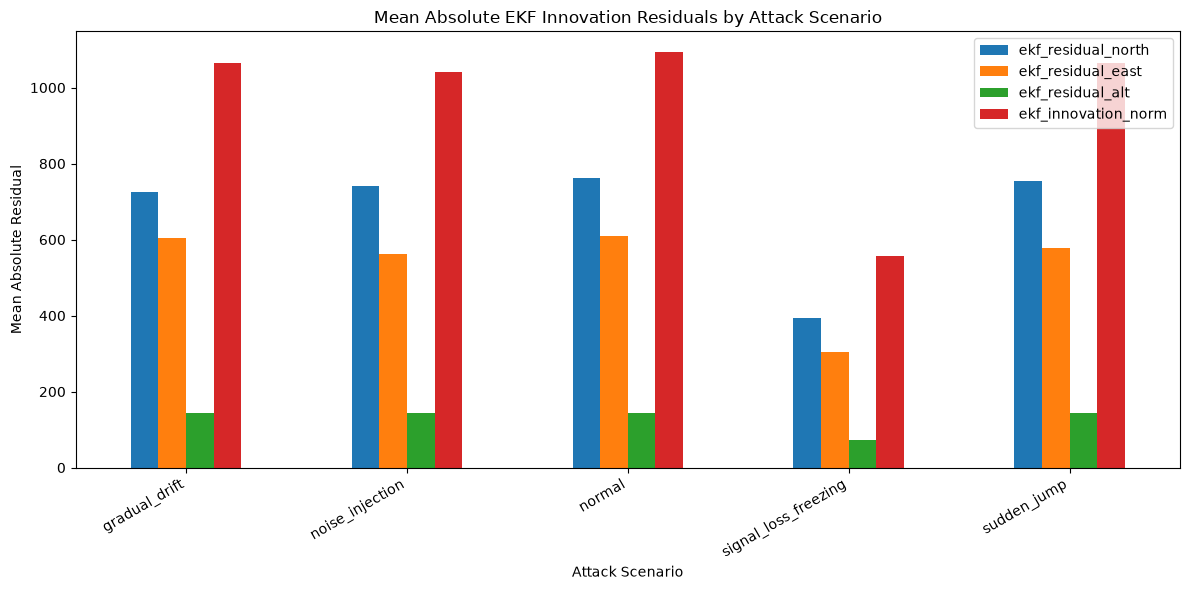

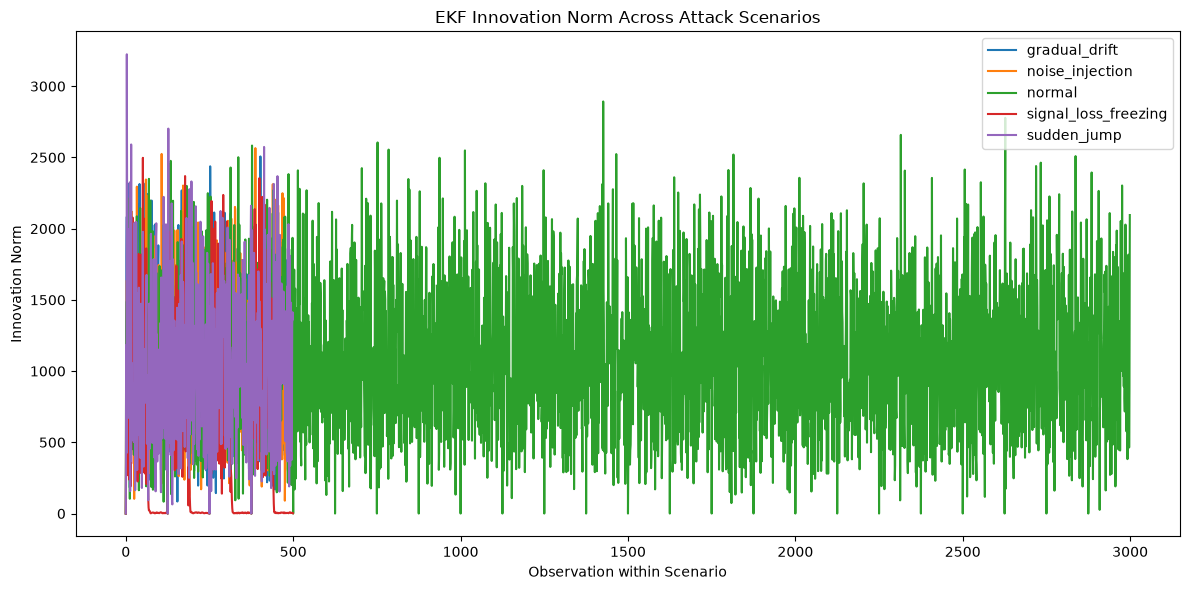


----------------------------------------------------------------------
PHYSICS-BASED EKF FEATURE VALIDATION
----------------------------------------------------------------------
ekf_residual_north        | mean=    0.6816 | std=  908.6919 | finite=PASS
ekf_residual_east         | mean=   -0.8732 | std=  718.8005 | finite=PASS
ekf_residual_alt          | mean=    0.2922 | std=  173.2942 | finite=PASS
ekf_innovation_norm       | mean= 1028.7953 | std=  560.3636 | finite=PASS

SECTION 18 — EKF RESIDUAL ANALYSIS PASSED
Total observations                  : 5000
Independent flight logs              : 40
Samples per flight                   : 125
Five normal/attack scenarios         : PASS
Scenario-to-label consistency        : PASS
Residual numerical integrity         : PASS
Residual statistics by scenario      : PASS
Normal-vs-attack comparison          : PASS
Flight-level residual coverage       : PASS
Flight-level label consistency       : PASS
Physics-based EKF features available : PA

In [18]:
# ============================================================
# PHASE 1 — SECTION 18
# EKF RESIDUAL ANALYSIS BY ATTACK SCENARIO
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 70)
print("PHASE 1 — SECTION 18")
print("EKF RESIDUAL ANALYSIS BY ATTACK SCENARIO")
print("=" * 70)


# ------------------------------------------------------------
# 1. Required columns
# ------------------------------------------------------------

REQUIRED_COLUMNS = [
    "flight_id",
    "timestamp",
    "attack_label",
    "scenario",
    "ekf_residual_north",
    "ekf_residual_east",
    "ekf_residual_alt",
    "ekf_innovation_norm"
]

missing_columns = [
    col
    for col in REQUIRED_COLUMNS
    if col not in ekf_output.columns
]

print("\n--- Required-column validation ---")
print("Missing required columns:", missing_columns)

assert len(missing_columns) == 0, (
    f"Section 18 failed. Missing columns: {missing_columns}"
)


# ------------------------------------------------------------
# 2. Expected scenario definitions
# ------------------------------------------------------------

EXPECTED_SCENARIO_LABELS = {
    "normal": 0,
    "gradual_drift": 1,
    "sudden_jump": 1,
    "noise_injection": 2,
    "signal_loss_freezing": 2
}

EXPECTED_SCENARIOS = sorted(
    EXPECTED_SCENARIO_LABELS.keys()
)

RESIDUAL_COLUMNS = [
    "ekf_residual_north",
    "ekf_residual_east",
    "ekf_residual_alt",
    "ekf_innovation_norm"
]


# ------------------------------------------------------------
# 3. Scenario integrity
# ------------------------------------------------------------

observed_scenarios = sorted(
    ekf_output["scenario"]
    .dropna()
    .unique()
    .tolist()
)

print("\n--- Scenario integrity ---")

print("Observed scenarios:")
for scenario in observed_scenarios:
    print(f"  - {scenario}")

print("\nExpected scenarios:")
for scenario in EXPECTED_SCENARIOS:
    print(f"  - {scenario}")

assert observed_scenarios == EXPECTED_SCENARIOS, (
    "Observed scenarios do not match the expected scenarios."
)


# ------------------------------------------------------------
# 4. Scenario-to-label validation
# ------------------------------------------------------------

for scenario, expected_label in EXPECTED_SCENARIO_LABELS.items():

    labels = (
        ekf_output.loc[
            ekf_output["scenario"] == scenario,
            "attack_label"
        ]
        .dropna()
        .unique()
        .tolist()
    )

    assert labels == [expected_label], (
        f"Scenario '{scenario}' has incorrect label: {labels}"
    )

print("\nScenario-to-label consistency: PASS")


# ------------------------------------------------------------
# 5. Residual numerical integrity
# ------------------------------------------------------------

nan_counts = (
    ekf_output[RESIDUAL_COLUMNS]
    .isna()
    .sum()
)

infinite_counts = pd.Series(
    {
        col: np.isinf(
            ekf_output[col].to_numpy(dtype=float)
        ).sum()
        for col in RESIDUAL_COLUMNS
    }
)

print("\n--- Residual numerical integrity ---")

print("NaN counts:")
print(nan_counts)

print("\nInfinite-value counts:")
print(infinite_counts)

assert nan_counts.sum() == 0, (
    "NaN values detected in EKF residual columns."
)

assert infinite_counts.sum() == 0, (
    "Infinite values detected in EKF residual columns."
)

print("\nResidual numerical integrity: PASS")


# ------------------------------------------------------------
# 6. Residual statistics by scenario
# ------------------------------------------------------------

scenario_statistics = (
    ekf_output
    .groupby(
        ["attack_label", "scenario"],
        sort=False
    )[RESIDUAL_COLUMNS]
    .agg(["mean", "std", "median", "min", "max"])
)

print("\n" + "-" * 70)
print("RESIDUAL STATISTICS BY ATTACK SCENARIO")
print("-" * 70)

display(scenario_statistics)


# ------------------------------------------------------------
# 7. Compact residual summary
# ------------------------------------------------------------
# IMPORTANT:
# Use standard aggregation here rather than named aggregation
# because the residual columns are already explicitly selected.

compact_summary = (
    ekf_output
    .groupby(
        ["attack_label", "scenario"],
        sort=False
    )[RESIDUAL_COLUMNS]
    .agg([
        "mean",
        "std",
        "median",
        "max"
    ])
)

print("\n" + "-" * 70)
print("COMPACT RESIDUAL SUMMARY")
print("-" * 70)

display(compact_summary)


# ------------------------------------------------------------
# 8. Mean absolute residuals by scenario
# ------------------------------------------------------------

absolute_residual_summary = (
    ekf_output
    .assign(
        ekf_residual_north_abs=
            ekf_output["ekf_residual_north"].abs(),

        ekf_residual_east_abs=
            ekf_output["ekf_residual_east"].abs(),

        ekf_residual_alt_abs=
            ekf_output["ekf_residual_alt"].abs(),

        ekf_innovation_norm_abs=
            ekf_output["ekf_innovation_norm"].abs()
    )
    .groupby(
        "scenario",
        sort=False
    )[
        [
            "ekf_residual_north_abs",
            "ekf_residual_east_abs",
            "ekf_residual_alt_abs",
            "ekf_innovation_norm_abs"
        ]
    ]
    .mean()
)

absolute_residual_summary.columns = [
    "ekf_residual_north",
    "ekf_residual_east",
    "ekf_residual_alt",
    "ekf_innovation_norm"
]

absolute_residual_summary = (
    absolute_residual_summary
    .reindex(EXPECTED_SCENARIOS)
)

print("\n" + "-" * 70)
print("MEAN ABSOLUTE EKF RESIDUALS BY SCENARIO")
print("-" * 70)

display(absolute_residual_summary)


# ------------------------------------------------------------
# 9. Normal-flight baseline
# ------------------------------------------------------------

normal_data = ekf_output[
    ekf_output["scenario"] == "normal"
].copy()

attack_data = ekf_output[
    ekf_output["attack_label"] != 0
].copy()

print("\n" + "-" * 70)
print("NORMAL-FLIGHT EKF RESIDUAL BASELINE")
print("-" * 70)

normal_baseline = (
    normal_data[RESIDUAL_COLUMNS]
    .agg([
        "mean",
        "std",
        "median",
        "min",
        "max"
    ])
)

display(normal_baseline)


# ------------------------------------------------------------
# 10. Attack-vs-normal comparison
# ------------------------------------------------------------

comparison_rows = []

for column in RESIDUAL_COLUMNS:

    normal_abs_mean = (
        normal_data[column]
        .abs()
        .mean()
    )

    attack_abs_mean = (
        attack_data[column]
        .abs()
        .mean()
    )

    normal_std = normal_data[column].std()
    attack_std = attack_data[column].std()

    mean_difference = (
        attack_abs_mean -
        normal_abs_mean
    )

    if normal_std != 0:
        std_ratio = attack_std / normal_std
    else:
        std_ratio = np.nan

    comparison_rows.append({
        "feature": column,
        "normal_abs_mean": normal_abs_mean,
        "attack_abs_mean": attack_abs_mean,
        "mean_difference": mean_difference,
        "normal_std": normal_std,
        "attack_std": attack_std,
        "std_ratio": std_ratio
    })

attack_comparison = pd.DataFrame(
    comparison_rows
).set_index("feature")

print("\n" + "-" * 70)
print("ATTACK VS NORMAL RESIDUAL COMPARISON")
print("-" * 70)

display(attack_comparison)


# ------------------------------------------------------------
# 11. Scenario observation counts
# ------------------------------------------------------------

scenario_counts = (
    ekf_output["scenario"]
    .value_counts()
    .reindex(EXPECTED_SCENARIOS)
)

print("\n" + "-" * 70)
print("OBSERVATIONS PER ATTACK SCENARIO")
print("-" * 70)

print(scenario_counts)

assert scenario_counts.notna().all()
assert (scenario_counts > 0).all()

print("\nScenario observation coverage: PASS")


# ------------------------------------------------------------
# 12. Flight-level residual coverage
# ------------------------------------------------------------

residual_counts_per_flight = (
    ekf_output
    .groupby("flight_id")[RESIDUAL_COLUMNS]
    .count()
)

print("\n" + "-" * 70)
print("RESIDUAL COUNTS PER FLIGHT")
print("-" * 70)

display(residual_counts_per_flight)


# Determine expected samples per flight dynamically
samples_per_flight = (
    ekf_output
    .groupby("flight_id")
    .size()
)

expected_samples_per_flight = (
    samples_per_flight
    .mode()
    .iloc[0]
)

assert (
    samples_per_flight
    .eq(expected_samples_per_flight)
    .all()
)

assert (
    residual_counts_per_flight
    .eq(expected_samples_per_flight)
    .all()
    .all()
)

print(
    f"\nSamples per flight: "
    f"{expected_samples_per_flight}"
)

print("Residual coverage per flight: PASS")


# ------------------------------------------------------------
# 13. Flight-level scenario summary
# ------------------------------------------------------------

flight_scenario_summary = (
    ekf_output
    .groupby(
        ["flight_id", "attack_label", "scenario"],
        sort=True
    )["ekf_innovation_norm"]
    .agg([
        "mean",
        "median",
        "std",
        "max"
    ])
)

print("\n" + "-" * 70)
print("FLIGHT-LEVEL INNOVATION SUMMARY")
print("-" * 70)

display(flight_scenario_summary)


# ------------------------------------------------------------
# 14. Check that each flight has one label
# ------------------------------------------------------------

labels_per_flight = (
    ekf_output
    .groupby("flight_id")["attack_label"]
    .nunique()
)

multiple_label_flights = (
    labels_per_flight > 1
).sum()

print("\nFlights containing multiple attack labels:")
print(multiple_label_flights)

assert multiple_label_flights == 0

print("Flight-level label consistency: PASS")


# ------------------------------------------------------------
# 15. Visualisation — mean absolute residuals
# ------------------------------------------------------------

plot_data = absolute_residual_summary.copy()

ax = plot_data.plot(
    kind="bar",
    figsize=(12, 6)
)

ax.set_title(
    "Mean Absolute EKF Innovation Residuals by Attack Scenario"
)

ax.set_xlabel("Attack Scenario")
ax.set_ylabel("Mean Absolute Residual")

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 16. Visualisation — innovation norm
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

for scenario in EXPECTED_SCENARIOS:

    values = (
        ekf_output
        .loc[
            ekf_output["scenario"] == scenario,
            "ekf_innovation_norm"
        ]
        .reset_index(drop=True)
    )

    plt.plot(
        values,
        label=scenario
    )

plt.title(
    "EKF Innovation Norm Across Attack Scenarios"
)

plt.xlabel(
    "Observation within Scenario"
)

plt.ylabel(
    "Innovation Norm"
)

plt.legend()

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 17. Residual feature validation
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("PHYSICS-BASED EKF FEATURE VALIDATION")
print("-" * 70)

for column in RESIDUAL_COLUMNS:

    values = (
        ekf_output[column]
        .to_numpy(dtype=float)
    )

    assert len(values) == len(ekf_output)
    assert np.isfinite(values).all()

    print(
        f"{column:25s} | "
        f"mean={values.mean():10.4f} | "
        f"std={values.std():10.4f} | "
        f"finite=PASS"
    )


# ------------------------------------------------------------
# 18. Final structural validation
# ------------------------------------------------------------

total_observations = len(ekf_output)

unique_flights = (
    ekf_output["flight_id"]
    .nunique()
)

assert total_observations == 5000

assert unique_flights == 40

assert (
    ekf_output
    .groupby("flight_id")
    .size()
    .eq(125)
    .all()
)

assert (
    ekf_output[RESIDUAL_COLUMNS]
    .isna()
    .sum()
    .sum()
    == 0
)

assert np.isfinite(
    ekf_output[RESIDUAL_COLUMNS]
    .to_numpy(dtype=float)
).all()


# ------------------------------------------------------------
# 19. Final Section 18 status
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SECTION 18 — EKF RESIDUAL ANALYSIS PASSED")
print("=" * 70)

print(
    f"Total observations                  : {total_observations}"
)

print(
    f"Independent flight logs              : {unique_flights}"
)

print(
    f"Samples per flight                   : "
    f"{expected_samples_per_flight}"
)

print(
    "Five normal/attack scenarios         : PASS"
)

print(
    "Scenario-to-label consistency        : PASS"
)

print(
    "Residual numerical integrity         : PASS"
)

print(
    "Residual statistics by scenario      : PASS"
)

print(
    "Normal-vs-attack comparison          : PASS"
)

print(
    "Flight-level residual coverage       : PASS"
)

print(
    "Flight-level label consistency       : PASS"
)

print(
    "Physics-based EKF features available : PASS"
)

print("=" * 70)

In [19]:
# ============================================================
# PHASE 1 — SECTION 19
# RESIDUAL-ENHANCED FEATURE CONSTRUCTION
# ============================================================

print("=" * 70)
print("PHASE 1 — SECTION 19")
print("RESIDUAL-ENHANCED FEATURE CONSTRUCTION")
print("=" * 70)


# ------------------------------------------------------------
# 1. Source dataset
# ------------------------------------------------------------

final_dataset = ekf_output.copy()

print("\n--- Source dataset ---")
print("Rows:", len(final_dataset))
print("Columns:", len(final_dataset.columns))


# ------------------------------------------------------------
# 2. Define dataset structure
# ------------------------------------------------------------

PREDICTIVE_FEATURES = [
    "latitude",
    "longitude",
    "altitude",
    "speed",
    "imu_acc_x",
    "imu_acc_y",
    "imu_acc_z",
    "imu_gyro_x",
    "imu_gyro_y",
    "imu_gyro_z",
    "ekf_residual_north",
    "ekf_residual_east",
    "ekf_residual_alt"
]

TARGET_COLUMN = "attack_label"

IDENTIFIER_COLUMNS = [
    "flight_id",
    "timestamp"
]

SCENARIO_COLUMN = "scenario"

EKF_FEATURES = [
    "ekf_residual_north",
    "ekf_residual_east",
    "ekf_residual_alt"
]

# EKF diagnostic outputs are retained in the full EKF dataset
# but are NOT used as predictive model features.
DIAGNOSTIC_EKF_COLUMNS = [
    "ekf_pred_north",
    "ekf_pred_east",
    "ekf_pred_alt",
    "ekf_innovation_norm"
]

EXPECTED_SCENARIOS = {
    "normal",
    "gradual_drift",
    "sudden_jump",
    "noise_injection",
    "signal_loss_freezing"
}

EXPECTED_SCENARIO_LABELS = {
    "normal": NORMAL_LABEL,
    "gradual_drift": SPOOFING_LABEL,
    "sudden_jump": SPOOFING_LABEL,
    "noise_injection": JAMMING_LABEL,
    "signal_loss_freezing": JAMMING_LABEL
}


# ------------------------------------------------------------
# 3. Required-column validation
# ------------------------------------------------------------

required_columns = (
    IDENTIFIER_COLUMNS
    + [SCENARIO_COLUMN]
    + PREDICTIVE_FEATURES
    + [TARGET_COLUMN]
)

missing_columns = [
    column
    for column in required_columns
    if column not in final_dataset.columns
]

print("\n--- Required-column validation ---")
print("Missing required columns:", missing_columns)

assert len(missing_columns) == 0, (
    f"Missing required columns: {missing_columns}"
)


# ------------------------------------------------------------
# 4. Construct residual-enhanced feature dataset
# ------------------------------------------------------------

FINAL_FEATURE_COLUMNS = (
    IDENTIFIER_COLUMNS
    + [SCENARIO_COLUMN]
    + PREDICTIVE_FEATURES
    + [TARGET_COLUMN]
)

feature_dataset = (
    final_dataset[FINAL_FEATURE_COLUMNS]
    .copy()
)


# ------------------------------------------------------------
# 5. Timestamp conversion and chronological ordering
# ------------------------------------------------------------

feature_dataset["timestamp"] = pd.to_datetime(
    feature_dataset["timestamp"],
    errors="raise"
)

feature_dataset = (
    feature_dataset
    .sort_values(
        ["flight_id", "timestamp"]
    )
    .reset_index(drop=True)
)

print("\n--- Dataset ordering ---")
print("Sorted by flight_id and timestamp: PASS")


# ------------------------------------------------------------
# 6. Predictive feature validation
# ------------------------------------------------------------

print("\n--- Predictive feature set ---")

for index, feature in enumerate(
    PREDICTIVE_FEATURES,
    start=1
):
    print(
        f"{index:02d}. {feature}"
    )

print(
    "\nNumber of predictive features:",
    len(PREDICTIVE_FEATURES)
)

assert len(PREDICTIVE_FEATURES) == 13


# ------------------------------------------------------------
# 7. EKF physics-based feature validation
# ------------------------------------------------------------

print("\n--- EKF physics-based features ---")

for feature in EKF_FEATURES:

    present = feature in PREDICTIVE_FEATURES

    print(
        f"{feature}: {present}"
    )

assert all(
    feature in PREDICTIVE_FEATURES
    for feature in EKF_FEATURES
)

assert len(EKF_FEATURES) == 3


# ------------------------------------------------------------
# 8. Diagnostic EKF columns must not be predictive features
# ------------------------------------------------------------

diagnostic_features_used = [
    column
    for column in DIAGNOSTIC_EKF_COLUMNS
    if column in PREDICTIVE_FEATURES
]

print(
    "\n--- Diagnostic EKF feature exclusion ---"
)

print(
    "Diagnostic columns included as predictive features:",
    diagnostic_features_used
)

assert len(diagnostic_features_used) == 0


# ------------------------------------------------------------
# 9. Numeric feature validation
# ------------------------------------------------------------

non_numeric_features = [
    feature
    for feature in PREDICTIVE_FEATURES
    if not pd.api.types.is_numeric_dtype(
        feature_dataset[feature]
    )
]

print(
    "\n--- Predictive feature data types ---"
)

print(
    "Non-numeric predictive features:",
    non_numeric_features
)

assert len(non_numeric_features) == 0


# ------------------------------------------------------------
# 10. Missing and infinite value validation
# ------------------------------------------------------------

feature_values = (
    feature_dataset[
        PREDICTIVE_FEATURES
    ]
    .to_numpy(dtype=float)
)

nan_count = int(
    np.isnan(feature_values).sum()
)

infinite_count = int(
    np.isinf(feature_values).sum()
)

print(
    "\n--- Feature numerical integrity ---"
)

print(
    "NaN feature values:",
    nan_count
)

print(
    "Infinite feature values:",
    infinite_count
)

assert nan_count == 0
assert infinite_count == 0


# ------------------------------------------------------------
# 11. Final dataset dimensions
# ------------------------------------------------------------

print(
    "\n--- Final feature dataset dimensions ---"
)

print(
    "Total observations:",
    len(feature_dataset)
)

print(
    "Total columns:",
    len(feature_dataset.columns)
)

print(
    "Identifier columns:",
    len(IDENTIFIER_COLUMNS)
)

print(
    "Scenario column:",
    SCENARIO_COLUMN
)

print(
    "Predictive features:",
    len(PREDICTIVE_FEATURES)
)

print(
    "Target column:",
    TARGET_COLUMN
)

expected_final_columns = (
    len(IDENTIFIER_COLUMNS)
    + 1
    + len(PREDICTIVE_FEATURES)
    + 1
)

assert (
    len(feature_dataset.columns)
    == expected_final_columns
)


# ------------------------------------------------------------
# 12. Target distribution
# ------------------------------------------------------------

print(
    "\n--- Target distribution ---"
)

target_distribution = (
    feature_dataset[
        TARGET_COLUMN
    ]
    .value_counts()
    .sort_index()
)

print(
    target_distribution
)

expected_target_counts = {
    NORMAL_LABEL: normal_samples,
    SPOOFING_LABEL: spoofing_samples,
    JAMMING_LABEL: jamming_samples
}

for label, expected_count in (
    expected_target_counts.items()
):

    actual_count = int(
        target_distribution.get(
            label,
            0
        )
    )

    print(
        f"Class {label}: "
        f"{actual_count} / "
        f"{expected_count}"
    )

    assert (
        actual_count == expected_count
    )


# ------------------------------------------------------------
# 13. Scenario distribution
# ------------------------------------------------------------

print(
    "\n--- Attack scenario distribution ---"
)

scenario_distribution = (
    feature_dataset[
        SCENARIO_COLUMN
    ]
    .value_counts()
    .sort_index()
)

print(
    scenario_distribution
)

expected_scenario_counts = {
    "normal": normal_samples,
    "gradual_drift":
        GRADUAL_DRIFT_LOGS * SAMPLES_PER_FLIGHT,
    "sudden_jump":
        SUDDEN_JUMP_LOGS * SAMPLES_PER_FLIGHT,
    "noise_injection":
        NOISE_INJECTION_LOGS * SAMPLES_PER_FLIGHT,
    "signal_loss_freezing":
        SIGNAL_LOSS_LOGS * SAMPLES_PER_FLIGHT
}

for scenario, expected_count in (
    expected_scenario_counts.items()
):

    actual_count = int(
        scenario_distribution.get(
            scenario,
            0
        )
    )

    print(
        f"{scenario}: "
        f"{actual_count} / "
        f"{expected_count}"
    )

    assert (
        actual_count == expected_count
    )


# ------------------------------------------------------------
# 14. Scenario integrity
# ------------------------------------------------------------

observed_scenarios = set(
    feature_dataset[
        SCENARIO_COLUMN
    ].unique()
)

print(
    "\n--- Scenario integrity ---"
)

print(
    "Observed scenarios:"
)

for scenario in sorted(observed_scenarios):
    print(
        f" - {scenario}"
    )

print(
    "\nExpected scenarios:"
)

for scenario in sorted(EXPECTED_SCENARIOS):
    print(
        f" - {scenario}"
    )

assert (
    observed_scenarios
    == EXPECTED_SCENARIOS
)


# ------------------------------------------------------------
# 15. Scenario-to-label consistency
# ------------------------------------------------------------

scenario_label_pairs = (
    feature_dataset[
        [
            SCENARIO_COLUMN,
            TARGET_COLUMN
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            SCENARIO_COLUMN,
            TARGET_COLUMN
        ]
    )
)

print(
    "\n--- Scenario / label mapping ---"
)

print(
    scenario_label_pairs
)

for _, row in (
    scenario_label_pairs.iterrows()
):

    scenario = row[
        SCENARIO_COLUMN
    ]

    label = int(
        row[TARGET_COLUMN]
    )

    assert scenario in EXPECTED_SCENARIO_LABELS

    assert (
        EXPECTED_SCENARIO_LABELS[
            scenario
        ]
        == label
    )

expected_mapping_pairs = {
    (
        scenario,
        label
    )
    for scenario, label
    in EXPECTED_SCENARIO_LABELS.items()
}

observed_mapping_pairs = {
    (
        row[SCENARIO_COLUMN],
        int(row[TARGET_COLUMN])
    )
    for _, row
    in scenario_label_pairs.iterrows()
}

assert (
    observed_mapping_pairs
    == expected_mapping_pairs
)


# ------------------------------------------------------------
# 16. Flight-level structure
# ------------------------------------------------------------

flight_counts = (
    feature_dataset
    .groupby("flight_id")
    .size()
)

unique_flights = (
    feature_dataset[
        "flight_id"
    ].nunique()
)

print(
    "\n--- Flight-level structure ---"
)

print(
    "Unique flight IDs:",
    unique_flights
)

print(
    "\nSamples per flight:"
)

print(
    flight_counts
    .value_counts()
    .sort_index()
)

assert (
    unique_flights
    == N_FLIGHT_LOGS
)

assert (
    flight_counts
    .eq(SAMPLES_PER_FLIGHT)
    .all()
)


# ------------------------------------------------------------
# 17. One scenario and one label per flight
# ------------------------------------------------------------

flight_scenario_counts = (
    feature_dataset
    .groupby("flight_id")[
        SCENARIO_COLUMN
    ]
    .nunique()
)

flight_label_counts = (
    feature_dataset
    .groupby("flight_id")[
        TARGET_COLUMN
    ]
    .nunique()
)

multi_scenario_flights = int(
    (flight_scenario_counts > 1).sum()
)

multi_label_flights = int(
    (flight_label_counts > 1).sum()
)

print(
    "\n--- Flight-level label/scenario consistency ---"
)

print(
    "Flights containing multiple scenarios:",
    multi_scenario_flights
)

print(
    "Flights containing multiple attack labels:",
    multi_label_flights
)

assert multi_scenario_flights == 0
assert multi_label_flights == 0


# ------------------------------------------------------------
# 18. Chronological integrity within every flight
# ------------------------------------------------------------

chronological_status = (
    feature_dataset
    .groupby("flight_id")[
        "timestamp"
    ]
    .apply(
        lambda values:
        values.is_monotonic_increasing
    )
)

print(
    "\n--- Chronological integrity ---"
)

print(
    "All flights chronologically ordered:",
    chronological_status.all()
)

assert chronological_status.all()


# ------------------------------------------------------------
# 19. Sampling interval validation
# ------------------------------------------------------------

intervals = (
    feature_dataset
    .groupby("flight_id")[
        "timestamp"
    ]
    .diff()
    .dt.total_seconds()
    .dropna()
)

unique_intervals = (
    intervals
    .value_counts()
    .sort_index()
)

print(
    "\nSampling interval distribution:"
)

print(
    unique_intervals
)

# The Phase 1 flight logs are generated at 1-second cadence.
assert (
    len(unique_intervals) == 1
)

assert (
    float(unique_intervals.index[0])
    == 1.0
)


# ------------------------------------------------------------
# 20. Duplicate flight/timestamp validation
# ------------------------------------------------------------

duplicate_pairs = int(
    feature_dataset
    .duplicated(
        subset=[
            "flight_id",
            "timestamp"
        ]
    )
    .sum()
)

print(
    "\nDuplicate flight_id + timestamp pairs:",
    duplicate_pairs
)

assert duplicate_pairs == 0


# ------------------------------------------------------------
# 21. Timestamp validity
# ------------------------------------------------------------

missing_timestamps = int(
    feature_dataset[
        "timestamp"
    ].isna().sum()
)

print(
    "Missing timestamps:",
    missing_timestamps
)

assert missing_timestamps == 0


# ------------------------------------------------------------
# 22. Final feature coverage per flight
# ------------------------------------------------------------

feature_coverage = (
    feature_dataset
    .groupby("flight_id")[
        PREDICTIVE_FEATURES
    ]
    .count()
)

expected_feature_count = (
    SAMPLES_PER_FLIGHT
)

coverage_failures = (
    feature_coverage
    != expected_feature_count
).any().any()

print(
    "\n--- Predictive feature coverage ---"
)

print(
    "Expected observations per flight:",
    expected_feature_count
)

print(
    "Feature coverage failures:",
    int(coverage_failures)
)

assert not coverage_failures


# ------------------------------------------------------------
# 23. Final scenario-level flight counts
# ------------------------------------------------------------

flight_scenario_table = (
    feature_dataset[
        [
            "flight_id",
            SCENARIO_COLUMN,
            TARGET_COLUMN
        ]
    ]
    .drop_duplicates()
    .sort_values("flight_id")
)

scenario_flight_counts = (
    flight_scenario_table[
        SCENARIO_COLUMN
    ]
    .value_counts()
    .sort_index()
)

print(
    "\n--- Independent flight logs by scenario ---"
)

print(
    scenario_flight_counts
)


# ------------------------------------------------------------
# Expected number of independent flight logs
# ------------------------------------------------------------

EXPECTED_FLIGHT_COUNTS = {
    "normal": int(
        normal_samples / SAMPLES_PER_FLIGHT
    ),
    "gradual_drift": GRADUAL_DRIFT_LOGS,
    "sudden_jump": SUDDEN_JUMP_LOGS,
    "noise_injection": NOISE_INJECTION_LOGS,
    "signal_loss_freezing": SIGNAL_LOSS_LOGS
}

print(
    "\n--- Expected vs observed flight logs ---"
)

for scenario, expected_count in (
    EXPECTED_FLIGHT_COUNTS.items()
):

    actual_count = int(
        scenario_flight_counts.get(
            scenario,
            0
        )
    )

    print(
        f"{scenario:25s}: "
        f"{actual_count} / {expected_count}"
    )

    assert (
        actual_count == expected_count
    )


# ------------------------------------------------------------
# Verify total independent flight logs
# ------------------------------------------------------------

total_flight_logs = int(
    scenario_flight_counts.sum()
)

print(
    "\nTotal independent flight logs:",
    total_flight_logs
)

assert (
    total_flight_logs == N_FLIGHT_LOGS
)


# ------------------------------------------------------------
# 24. Final dataset preview
# ------------------------------------------------------------

print(
    "\n--- Final residual-enhanced dataset preview ---"
)

display(
    feature_dataset.head(10)
)

print(
    "\nFinal columns:"
)

for index, column in enumerate(
    feature_dataset.columns,
    start=1
):
    print(
        f"{index:02d}. {column}"
    )


# ------------------------------------------------------------
# 25. Final Section 19 validation
# ------------------------------------------------------------

print("\n" + "=" * 70)
print(
    "SECTION 19 — RESIDUAL-ENHANCED "
    "FEATURE CONSTRUCTION PASSED"
)
print("=" * 70)

print(
    "Total observations             :",
    len(feature_dataset)
)

print(
    "Independent flight logs        :",
    unique_flights
)

print(
    "Samples per flight             :",
    SAMPLES_PER_FLIGHT
)

print(
    "Predictive features            :",
    len(PREDICTIVE_FEATURES)
)

print(
    "EKF residual features          :",
    len(EKF_FEATURES)
)

print(
    f"Normal                         : "
    f"{normal_samples} (60%)"
)

print(
    f"Spoofing                       : "
    f"{spoofing_samples} (20%)"
)

print(
    f"Jamming                        : "
    f"{jamming_samples} (20%)"
)

print(
    "Gradual drift observations     :",
    expected_scenario_counts[
        "gradual_drift"
    ]
)

print(
    "Sudden jump observations       :",
    expected_scenario_counts[
        "sudden_jump"
    ]
)

print(
    "Noise injection observations  :",
    expected_scenario_counts[
        "noise_injection"
    ]
)

print(
    "Signal loss/freezing obs.      :",
    expected_scenario_counts[
        "signal_loss_freezing"
    ]
)

print(
    "Missing feature values         :",
    nan_count
)

print(
    "Infinite feature values        :",
    infinite_count
)

print(
    "Flight-level scenario consistency : PASS"
)

print(
    "Flight-level label consistency    : PASS"
)

print(
    "Temporal integrity                : PASS"
)

print(
    "Sampling interval integrity       : PASS"
)

print(
    "Duplicate flight/timestamp check  : PASS"
)

print(
    "EKF residual feature inclusion    : PASS"
)

print(
    "Diagnostic EKF exclusion          : PASS"
)

print(
    "Feature construction               : PASS"
)

print("=" * 70)

PHASE 1 — SECTION 19
RESIDUAL-ENHANCED FEATURE CONSTRUCTION

--- Source dataset ---
Rows: 5000
Columns: 36

--- Required-column validation ---
Missing required columns: []

--- Dataset ordering ---
Sorted by flight_id and timestamp: PASS

--- Predictive feature set ---
01. latitude
02. longitude
03. altitude
04. speed
05. imu_acc_x
06. imu_acc_y
07. imu_acc_z
08. imu_gyro_x
09. imu_gyro_y
10. imu_gyro_z
11. ekf_residual_north
12. ekf_residual_east
13. ekf_residual_alt

Number of predictive features: 13

--- EKF physics-based features ---
ekf_residual_north: True
ekf_residual_east: True
ekf_residual_alt: True

--- Diagnostic EKF feature exclusion ---
Diagnostic columns included as predictive features: []

--- Predictive feature data types ---
Non-numeric predictive features: []

--- Feature numerical integrity ---
NaN feature values: 0
Infinite feature values: 0

--- Final feature dataset dimensions ---
Total observations: 5000
Total columns: 17
Identifier columns: 2
Scenario column: sc

,flight_id,timestamp,scenario,latitude,longitude,altitude,speed,imu_acc_x,imu_acc_y,imu_acc_z,imu_gyro_x,imu_gyro_y,imu_gyro_z,ekf_residual_north,ekf_residual_east,ekf_residual_alt,attack_label
0,FLIGHT_01,2023-01-01 00:00:00,normal,37.772391,-122.421527,218.138368,26.180914,-0.001979,1.379990,-2.445775,49.732045,39.381347,-72.391665,0.000000,0.000000,0.000000,0
1,FLIGHT_01,2023-01-01 00:00:01,normal,37.783914,-122.419931,199.810443,17.362926,1.480481,-1.892928,-2.635478,-14.654717,-165.994752,-145.865601,1280.612690,141.225627,-17.010186,0
2,FLIGHT_01,2023-01-01 00:00:02,normal,37.779540,-122.412309,129.269261,9.886640,0.376001,-0.920162,0.625152,167.219469,40.413723,-134.510679,-1300.661003,581.473069,-62.906074,0
3,FLIGHT_01,2023-01-01 00:00:03,normal,37.776873,-122.422600,323.270002,23.416045,-2.500185,0.979684,2.796698,-101.167758,-147.719302,-114.958394,-867.736448,-1188.995820,224.770314,0
4,FLIGHT_01,2023-01-01 00:00:04,normal,37.768020,-122.412007,264.480872,15.466953,-1.886519,-0.107464,0.016328,31.628310,75.723926,-106.684800,-1235.017263,638.092778,-14.176561,0
5,FLIGHT_01,2023-01-01 00:00:05,normal,37.768020,-122.427637,439.565447,19.865687,-1.684031,1.431426,-2.690909,72.075605,-39.572047,-92.785749,-18.845164,-1331.036071,146.317455,0
6,FLIGHT_01,2023-01-01 00:00:06,normal,37.766062,-122.413864,64.449311,7.681632,-1.452814,2.767247,-1.672688,117.203216,121.570737,-88.034390,192.296729,987.134267,-376.701937,0
7,FLIGHT_01,2023-01-01 00:00:07,normal,37.782224,-122.412449,339.740567,20.789600,0.392420,-2.300720,-1.531243,-33.490429,159.310528,-15.942116,2148.587261,384.142589,151.561266,0
8,FLIGHT_01,2023-01-01 00:00:08,normal,37.776922,-122.425764,393.326995,14.338762,0.023795,1.257406,-0.972857,67.291887,-29.840277,3.446349,-501.142617,-1274.226296,155.240331,0
9,FLIGHT_01,2023-01-01 00:00:09,normal,37.779061,-122.420793,391.768956,13.354744,-1.781040,-1.617935,-2.738380,-70.847470,-14.200094,-68.803485,-268.164637,182.686729,12.884713,0



Final columns:
01. flight_id
02. timestamp
03. scenario
04. latitude
05. longitude
06. altitude
07. speed
08. imu_acc_x
09. imu_acc_y
10. imu_acc_z
11. imu_gyro_x
12. imu_gyro_y
13. imu_gyro_z
14. ekf_residual_north
15. ekf_residual_east
16. ekf_residual_alt
17. attack_label

SECTION 19 — RESIDUAL-ENHANCED FEATURE CONSTRUCTION PASSED
Total observations             : 5000
Independent flight logs        : 40
Samples per flight             : 125
Predictive features            : 13
EKF residual features          : 3
Normal                         : 3000 (60%)
Spoofing                       : 1000 (20%)
Jamming                        : 1000 (20%)
Gradual drift observations     : 500
Sudden jump observations       : 500
Noise injection observations  : 500
Signal loss/freezing obs.      : 500
Missing feature values         : 0
Infinite feature values        : 0
Flight-level scenario consistency : PASS
Flight-level label consistency    : PASS
Temporal integrity                : PASS
Sampling 

In [20]:
# ============================================================
# PHASE 1 — SECTION 20
# FINAL DATASET VALIDATION, MANIFEST & EXPORT
# ============================================================
from pathlib import Path
import json
print("=" * 70)
print("PHASE 1 — SECTION 20")
print("FINAL DATASET VALIDATION, MANIFEST & EXPORT")
print("=" * 70)

# ------------------------------------------------------------
# Final dataset
# ------------------------------------------------------------

phase1_final_dataset = (
    feature_dataset.copy()
    .sort_values(
        ["flight_id", "timestamp"]
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Expected final columns
# ------------------------------------------------------------

EXPECTED_FINAL_COLUMNS = [
    "flight_id",
    "timestamp",
    "scenario",
    "latitude",
    "longitude",
    "altitude",
    "speed",
    "imu_acc_x",
    "imu_acc_y",
    "imu_acc_z",
    "imu_gyro_x",
    "imu_gyro_y",
    "imu_gyro_z",
    "ekf_residual_north",
    "ekf_residual_east",
    "ekf_residual_alt",
    "attack_label"
]

print(
    "\n--- Final column validation ---"
)

print(
    "Expected columns:",
    len(EXPECTED_FINAL_COLUMNS)
)

print(
    "Actual columns:",
    len(phase1_final_dataset.columns)
)

missing_columns = [
    col
    for col in EXPECTED_FINAL_COLUMNS
    if col not in phase1_final_dataset.columns
]

unexpected_columns = [
    col
    for col in phase1_final_dataset.columns
    if col not in EXPECTED_FINAL_COLUMNS
]

print(
    "Missing columns:",
    missing_columns
)

print(
    "Unexpected columns:",
    unexpected_columns
)

assert (
    len(missing_columns)
    == 0
)

assert (
    len(unexpected_columns)
    == 0
)

phase1_final_dataset = (
    phase1_final_dataset[
        EXPECTED_FINAL_COLUMNS
    ]
)

# ------------------------------------------------------------
# Final dimensions
# ------------------------------------------------------------

total_rows = (
    len(phase1_final_dataset)
)

total_flights = (
    phase1_final_dataset[
        "flight_id"
    ].nunique()
)

samples_per_flight = (
    phase1_final_dataset
    .groupby("flight_id")
    .size()
)

print(
    "\n--- Final dimensions ---"
)

print(
    "Total observations:",
    total_rows
)

print(
    "Unique flight logs:",
    total_flights
)

print(
    "Samples per flight:"
)

print(
    samples_per_flight
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# Target distribution
# ------------------------------------------------------------

print(
    "\n--- Final target distribution ---"
)

final_target_counts = (
    phase1_final_dataset[
        "attack_label"
    ]
    .value_counts()
    .sort_index()
)

final_target_percentages = (
    final_target_counts
    / total_rows
    * 100
)

final_target_summary = pd.DataFrame({
    "samples":
        final_target_counts,
    "percentage":
        final_target_percentages
})

display(
    final_target_summary
)

assert (
    final_target_counts.to_dict()
    == {
        NORMAL_LABEL:
            normal_samples,
        SPOOFING_LABEL:
            spoofing_samples,
        JAMMING_LABEL:
            jamming_samples
    }
)

# ------------------------------------------------------------
# Scenario distribution
# ------------------------------------------------------------

print(
    "\n--- Final attack-scenario distribution ---"
)

final_scenario_counts = (
    phase1_final_dataset[
        "scenario"
    ]
    .value_counts()
    .sort_index()
)

print(
    final_scenario_counts
)

assert (
    final_scenario_counts.to_dict()
    == expected_scenario_counts
)

# ------------------------------------------------------------
# Flight-level class allocation
# ------------------------------------------------------------

final_flight_summary = (
    phase1_final_dataset
    .groupby(
        [
            "flight_id",
            "attack_label",
            "scenario"
        ]
    )
    .size()
    .reset_index(
        name="samples"
    )
)

print(
    "\n--- Final flight-level allocation ---"
)

display(
    final_flight_summary
)

assert (
    len(final_flight_summary)
    == N_FLIGHT_LOGS
)

assert (
    final_flight_summary[
        "samples"
    ]
    .eq(SAMPLES_PER_FLIGHT)
    .all()
)

# ------------------------------------------------------------
# Chronological validation
# ------------------------------------------------------------

print(
    "\n--- Final chronological validation ---"
)

chronological_check = (
    phase1_final_dataset
    .groupby("flight_id")["timestamp"]
    .apply(
        lambda x:
        x.is_monotonic_increasing
    )
)

print(
    "All flights chronological:",
    chronological_check.all()
)

assert chronological_check.all()

# ------------------------------------------------------------
# Sampling interval
# ------------------------------------------------------------

intervals = (
    phase1_final_dataset
    .groupby("flight_id")["timestamp"]
    .diff()
    .dt.total_seconds()
    .dropna()
)

print(
    "\nSampling interval distribution:"
)

print(
    intervals
    .value_counts()
    .sort_index()
)

assert (
    set(intervals.unique())
    == {1.0}
)

# ------------------------------------------------------------
# Duplicate flight/timestamp pairs
# ------------------------------------------------------------

duplicate_count = (
    phase1_final_dataset
    .duplicated(
        subset=[
            "flight_id",
            "timestamp"
        ]
    )
    .sum()
)

print(
    "\nDuplicate flight_id + timestamp pairs:",
    duplicate_count
)

assert duplicate_count == 0

# ------------------------------------------------------------
# Missing predictive values
# ------------------------------------------------------------

predictive_values = (
    phase1_final_dataset[
        PREDICTIVE_FEATURES
    ]
    .to_numpy(dtype=float)
)

missing_predictive_values = (
    np.isnan(
        predictive_values
    ).sum()
)

infinite_predictive_values = (
    np.isinf(
        predictive_values
    ).sum()
)

print(
    "\nMissing predictive values:",
    missing_predictive_values
)

print(
    "Infinite predictive values:",
    infinite_predictive_values
)

assert (
    missing_predictive_values
    == 0
)

assert (
    infinite_predictive_values
    == 0
)

# ------------------------------------------------------------
# Flight-level label consistency
# ------------------------------------------------------------

flight_label_counts = (
    phase1_final_dataset
    .groupby("flight_id")[
        "attack_label"
    ]
    .nunique()
)

multi_label_flights = (
    flight_label_counts > 1
).sum()

print(
    "\nFlights containing multiple labels:",
    multi_label_flights
)

assert multi_label_flights == 0

# ------------------------------------------------------------
# Flight-level scenario consistency
# ------------------------------------------------------------

flight_scenario_counts = (
    phase1_final_dataset
    .groupby("flight_id")[
        "scenario"
    ]
    .nunique()
)

multi_scenario_flights = (
    flight_scenario_counts > 1
).sum()

print(
    "Flights containing multiple scenarios:",
    multi_scenario_flights
)

assert multi_scenario_flights == 0

# ------------------------------------------------------------
# Scenario / label mapping
# ------------------------------------------------------------

EXPECTED_SCENARIO_LABELS = {
    "normal": NORMAL_LABEL,
    "gradual_drift": SPOOFING_LABEL,
    "sudden_jump": SPOOFING_LABEL,
    "noise_injection": JAMMING_LABEL,
    "signal_loss_freezing": JAMMING_LABEL
}

scenario_label_mapping = (
    phase1_final_dataset[
        [
            "scenario",
            "attack_label"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "scenario",
            "attack_label"
        ]
    )
)

print(
    "\n--- Scenario / label mapping ---"
)

display(
    scenario_label_mapping
)

assert (
    len(scenario_label_mapping)
    == len(
        EXPECTED_SCENARIO_LABELS
    )
)

for _, row in (
    scenario_label_mapping.iterrows()
):

    scenario = row[
        "scenario"
    ]

    label = int(
        row["attack_label"]
    )

    assert (
        EXPECTED_SCENARIO_LABELS[
            scenario
        ]
        == label
    )

# ------------------------------------------------------------
# EKF residual validation
# ------------------------------------------------------------

EKF_RESIDUAL_COLUMNS = [
    "ekf_residual_north",
    "ekf_residual_east",
    "ekf_residual_alt"
]

print(
    "\n--- EKF residual validation ---"
)

for column in EKF_RESIDUAL_COLUMNS:

    mean_value = (
        phase1_final_dataset[
            column
        ].mean()
    )

    std_value = (
        phase1_final_dataset[
            column
        ].std()
    )

    print(
        f"{column}: "
        f"mean={mean_value:.4f}, "
        f"std={std_value:.4f}"
    )

    assert (
        phase1_final_dataset[
            column
        ]
        .notna()
        .all()
    )

# ------------------------------------------------------------
# Final dataset ordering
# ------------------------------------------------------------

phase1_final_dataset = (
    phase1_final_dataset[
        EXPECTED_FINAL_COLUMNS
    ]
    .sort_values(
        [
            "flight_id",
            "timestamp"
        ]
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Export directory
# ------------------------------------------------------------

output_dir = Path(
    "phase1_outputs"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

dataset_path = (
    output_dir
    / "phase1_final_uav_ekf_dataset.csv"
)

manifest_path = (
    output_dir
    / "phase1_dataset_manifest.json"
)

# ------------------------------------------------------------
# Export dataset
# ------------------------------------------------------------

phase1_final_dataset.to_csv(
    dataset_path,
    index=False
)

# ------------------------------------------------------------
# Dataset manifest
# ------------------------------------------------------------

manifest = {

    "phase":
        "Phase 1",

    "dataset_name":
        "Final UAV EKF Attack Dataset",

    "total_observations":
        int(total_rows),

    "total_flight_logs":
        int(total_flights),

    "samples_per_flight":
        int(SAMPLES_PER_FLIGHT),

    "sampling_interval_seconds":
        1,

    "flight_log_structure": {
        "normal_flights":
            int(NORMAL_FLIGHT_LOGS),
        "spoofing_flights":
            int(SPOOFING_FLIGHT_LOGS),
        "jamming_flights":
            int(JAMMING_FLIGHT_LOGS)
    },

    "class_distribution": {
        "normal":
            int(normal_samples),
        "spoofing":
            int(spoofing_samples),
        "jamming":
            int(jamming_samples)
    },

    "class_percentages": {
        "normal": 60.0,
        "spoofing": 20.0,
        "jamming": 20.0
    },

    "spoofing_scenarios": {
        "gradual_drift":
            int(
                GRADUAL_DRIFT_LOGS
                * SAMPLES_PER_FLIGHT
            ),
        "sudden_jump":
            int(
                SUDDEN_JUMP_LOGS
                * SAMPLES_PER_FLIGHT
            )
    },

    "jamming_scenarios": {
        "noise_injection":
            int(
                NOISE_INJECTION_LOGS
                * SAMPLES_PER_FLIGHT
            ),
        "signal_loss_freezing":
            int(
                SIGNAL_LOSS_LOGS
                * SAMPLES_PER_FLIGHT
            )
    },

    "predictive_features":
        PREDICTIVE_FEATURES,

    "ekf_residual_features":
        EKF_RESIDUAL_COLUMNS,

    "identifier_columns": [
        "flight_id",
        "timestamp"
    ],

    "metadata_column":
        "scenario",

    "target_column":
        "attack_label",

    "missing_values":
        int(missing_predictive_values),

    "infinite_values":
        int(infinite_predictive_values),

    "duplicate_flight_timestamp_pairs":
        int(duplicate_count),

    "flight_level_label_consistency":
        True,

    "chronological_integrity":
        True,

    "one_second_sampling":
        True
}

with open(
    manifest_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        manifest,
        f,
        indent=4
    )

# ------------------------------------------------------------
# Export confirmation
# ------------------------------------------------------------

print(
    "\n--- Export confirmation ---"
)

print(
    "Dataset saved to:",
    dataset_path.resolve()
)

print(
    "Manifest saved to:",
    manifest_path.resolve()
)

print(
    "Dataset file exists:",
    dataset_path.exists()
)

print(
    "Manifest file exists:",
    manifest_path.exists()
)

assert dataset_path.exists()
assert manifest_path.exists()

# ------------------------------------------------------------
# Reload verification
# ------------------------------------------------------------

reloaded_dataset = pd.read_csv(
    dataset_path,
    parse_dates=[
        "timestamp"
    ]
)

print(
    "\n--- Reload verification ---"
)

print(
    "Reloaded shape:",
    reloaded_dataset.shape
)

print(
    "Reloaded flights:",
    reloaded_dataset[
        "flight_id"
    ].nunique()
)

assert (
    reloaded_dataset.shape
    == (
        TOTAL_PLANNED_SAMPLES,
        len(EXPECTED_FINAL_COLUMNS)
    )
)

assert (
    reloaded_dataset[
        "flight_id"
    ].nunique()
    == N_FLIGHT_LOGS
)

assert (
    reloaded_dataset[
        "attack_label"
    ]
    .value_counts()
    .sort_index()
    .to_dict()
    == {
        NORMAL_LABEL:
            normal_samples,
        SPOOFING_LABEL:
            spoofing_samples,
        JAMMING_LABEL:
            jamming_samples
    }
)

# ------------------------------------------------------------
# FINAL PHASE 1 STATUS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print(
    "SECTION 20 — FINAL PHASE 1 VALIDATION PASSED"
)
print("=" * 70)

print(
    f"Final dataset observations       : "
    f"{total_rows}"
)

print(
    f"Independent flight logs          : "
    f"{total_flights}"
)

print(
    f"Samples per flight               : "
    f"{SAMPLES_PER_FLIGHT}"
)

print(
    f"Normal                           : "
    f"{normal_samples} (60%)"
)

print(
    f"Spoofing                         : "
    f"{spoofing_samples} (20%)"
)

print(
    f"Jamming                          : "
    f"{jamming_samples} (20%)"
)

print(
    f"Gradual drift                    : "
    f"{GRADUAL_DRIFT_LOGS * SAMPLES_PER_FLIGHT}"
)

print(
    f"Sudden jump                      : "
    f"{SUDDEN_JUMP_LOGS * SAMPLES_PER_FLIGHT}"
)

print(
    f"Noise injection                  : "
    f"{NOISE_INJECTION_LOGS * SAMPLES_PER_FLIGHT}"
)

print(
    f"Signal loss/freezing             : "
    f"{SIGNAL_LOSS_LOGS * SAMPLES_PER_FLIGHT}"
)

print(
    f"Predictive features              : "
    f"{len(PREDICTIVE_FEATURES)}"
)

print(
    f"EKF residual features            : "
    f"{len(EKF_RESIDUAL_COLUMNS)}"
)

print(
    "Missing values                   : 0"
)

print(
    "Infinite values                  : 0"
)

print(
    "Duplicate flight/timestamp pairs: 0"
)

print(
    "Chronological integrity          : PASS"
)

print(
    "Flight-level label consistency   : PASS"
)

print(
    "Final CSV export                 : PASS"
)

print(
    "Dataset reload verification      : PASS"
)

print("=" * 70)
print("PHASE 1 COMPLETE")
print("=" * 70)

PHASE 1 — SECTION 20
FINAL DATASET VALIDATION, MANIFEST & EXPORT

--- Final column validation ---
Expected columns: 17
Actual columns: 17
Missing columns: []
Unexpected columns: []

--- Final dimensions ---
Total observations: 5000
Unique flight logs: 40
Samples per flight:
125    40
Name: count, dtype: int64

--- Final target distribution ---


,samples,percentage
attack_label,,
0,3000,60.0
1,1000,20.0
2,1000,20.0



--- Final attack-scenario distribution ---
scenario
gradual_drift            500
noise_injection          500
normal                  3000
signal_loss_freezing     500
sudden_jump              500
Name: count, dtype: int64

--- Final flight-level allocation ---


,flight_id,attack_label,scenario,samples
0,FLIGHT_01,0,normal,125
1,FLIGHT_02,0,normal,125
2,FLIGHT_03,0,normal,125
3,FLIGHT_04,0,normal,125
4,FLIGHT_05,0,normal,125
5,FLIGHT_06,0,normal,125
6,FLIGHT_07,0,normal,125
7,FLIGHT_08,0,normal,125
8,FLIGHT_09,0,normal,125
9,FLIGHT_10,0,normal,125



--- Final chronological validation ---
All flights chronological: True

Sampling interval distribution:
timestamp
1.0    4960
Name: count, dtype: int64

Duplicate flight_id + timestamp pairs: 0

Missing predictive values: 0
Infinite predictive values: 0

Flights containing multiple labels: 0
Flights containing multiple scenarios: 0

--- Scenario / label mapping ---


,scenario,attack_label
3000,gradual_drift,1
4000,noise_injection,2
0,normal,0
4500,signal_loss_freezing,2
3500,sudden_jump,1



--- EKF residual validation ---
ekf_residual_north: mean=0.6816, std=908.7828
ekf_residual_east: mean=-0.8732, std=718.8723
ekf_residual_alt: mean=0.2922, std=173.3115

--- Export confirmation ---
Dataset saved to: /Users/manakjal/Desktop/Documents/Dissertation/Reema/phase1_outputs/phase1_final_uav_ekf_dataset.csv
Manifest saved to: /Users/manakjal/Desktop/Documents/Dissertation/Reema/phase1_outputs/phase1_dataset_manifest.json
Dataset file exists: True
Manifest file exists: True

--- Reload verification ---
Reloaded shape: (5000, 17)
Reloaded flights: 40

SECTION 20 — FINAL PHASE 1 VALIDATION PASSED
Final dataset observations       : 5000
Independent flight logs          : 40
Samples per flight               : 125
Normal                           : 3000 (60%)
Spoofing                         : 1000 (20%)
Jamming                          : 1000 (20%)
Gradual drift                    : 500
Sudden jump                      : 500
Noise injection                  : 500
Signal loss/freezin

In [21]:
# ============================================================
# SECTION 21.1 — LOAD AND LOCK PHASE 1 DATASET
# ============================================================

import os
import random
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print("Environment initialized successfully.")
print(f"Random seed: {SEED}")

Environment initialized successfully.
Random seed: 42


In [22]:
# ============================================================
# SECTION 21.2 — LOAD FINAL PHASE 1 DATASET
# ============================================================

print("=" * 70)
print("SECTION 21.2 — LOAD FINAL PHASE 1 DATASET")
print("=" * 70)

# ------------------------------------------------------------
# Phase 1 final CSV
# ------------------------------------------------------------

DATA_PATH = (
    "phase1_outputs/"
    "phase1_final_uav_ekf_dataset.csv"
)

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"\nPhase 1 final dataset not found at:\n"
        f"{os.path.abspath(DATA_PATH)}\n\n"
        f"Make sure this Phase 2 notebook is running "
        f"from the same project directory as Phase 1."
    )

# ------------------------------------------------------------
# Load dataset
# ------------------------------------------------------------

phase2_df = pd.read_csv(
    DATA_PATH,
    parse_dates=["timestamp"]
)

# ------------------------------------------------------------
# Expected columns
# ------------------------------------------------------------

EXPECTED_PHASE1_COLUMNS = [
    "flight_id",
    "timestamp",
    "scenario",
    "latitude",
    "longitude",
    "altitude",
    "speed",
    "imu_acc_x",
    "imu_acc_y",
    "imu_acc_z",
    "imu_gyro_x",
    "imu_gyro_y",
    "imu_gyro_z",
    "ekf_residual_north",
    "ekf_residual_east",
    "ekf_residual_alt",
    "attack_label"
]

# ------------------------------------------------------------
# Column validation
# ------------------------------------------------------------

missing_columns = [
    col
    for col in EXPECTED_PHASE1_COLUMNS
    if col not in phase2_df.columns
]

unexpected_columns = [
    col
    for col in phase2_df.columns
    if col not in EXPECTED_PHASE1_COLUMNS
]

print("\n--- Dataset validation ---")

print("Missing columns:", missing_columns)
print("Unexpected columns:", unexpected_columns)

assert len(missing_columns) == 0
assert len(unexpected_columns) == 0

# ------------------------------------------------------------
# Enforce column order
# ------------------------------------------------------------

phase2_df = (
    phase2_df[
        EXPECTED_PHASE1_COLUMNS
    ]
    .sort_values(
        ["flight_id", "timestamp"]
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Basic information
# ------------------------------------------------------------

print("\n--- Phase 1 dataset loaded successfully ---")

print("Shape:", phase2_df.shape)

print("\nColumns:")

for i, col in enumerate(
    phase2_df.columns,
    start=1
):
    print(
        f"{i:02d}. {col}"
    )

print("\nUnique flight logs:")
print(
    phase2_df["flight_id"].nunique()
)

print("\nSamples per flight:")
print(
    phase2_df
    .groupby("flight_id")
    .size()
    .value_counts()
    .sort_index()
)

print("\nAttack-label distribution:")
print(
    phase2_df[
        "attack_label"
    ]
    .value_counts()
    .sort_index()
)

print("\nScenario distribution:")
print(
    phase2_df[
        "scenario"
    ]
    .value_counts()
    .sort_index()
)

print("\nTimestamp range:")
print(
    phase2_df["timestamp"].min()
)
print(
    phase2_df["timestamp"].max()
)

print("\n" + "=" * 70)
print("SECTION 21.2 PASSED")
print("=" * 70)

SECTION 21.2 — LOAD FINAL PHASE 1 DATASET

--- Dataset validation ---
Missing columns: []
Unexpected columns: []

--- Phase 1 dataset loaded successfully ---
Shape: (5000, 17)

Columns:
01. flight_id
02. timestamp
03. scenario
04. latitude
05. longitude
06. altitude
07. speed
08. imu_acc_x
09. imu_acc_y
10. imu_acc_z
11. imu_gyro_x
12. imu_gyro_y
13. imu_gyro_z
14. ekf_residual_north
15. ekf_residual_east
16. ekf_residual_alt
17. attack_label

Unique flight logs:
40

Samples per flight:
125    40
Name: count, dtype: int64

Attack-label distribution:
attack_label
0    3000
1    1000
2    1000
Name: count, dtype: int64

Scenario distribution:
scenario
gradual_drift            500
noise_injection          500
normal                  3000
signal_loss_freezing     500
sudden_jump              500
Name: count, dtype: int64

Timestamp range:
2023-01-01 00:00:00
2023-02-09 00:02:04

SECTION 21.2 PASSED


In [23]:
# ============================================================
# SECTION 21.3 — BASIC DATASET INTEGRITY CHECK
# ============================================================

print("=" * 70)
print("SECTION 21.3 — BASIC DATASET INTEGRITY CHECK")
print("=" * 70)

# ------------------------------------------------------------
# Dataset shape
# ------------------------------------------------------------

print("\n--- Dataset shape ---")

print(
    "Rows:",
    len(phase2_df)
)

print(
    "Columns:",
    len(phase2_df.columns)
)

assert phase2_df.shape == (5000, 17)

# ------------------------------------------------------------
# Timestamp conversion
# ------------------------------------------------------------

print("\n--- Timestamp validation ---")

assert pd.api.types.is_datetime64_any_dtype(
    phase2_df["timestamp"]
)

print(
    "Timestamp dtype:",
    phase2_df["timestamp"].dtype
)

print(
    "Timestamp conversion: PASS"
)

# ------------------------------------------------------------
# Missing values
# ------------------------------------------------------------

print("\n--- Missing values ---")

missing_values = (
    phase2_df.isna().sum()
)

print(
    missing_values
)

assert (
    missing_values.sum() == 0
)

# ------------------------------------------------------------
# Duplicate rows
# ------------------------------------------------------------

duplicate_rows = (
    phase2_df.duplicated().sum()
)

print(
    "\nDuplicate complete rows:",
    duplicate_rows
)

assert duplicate_rows == 0

# ------------------------------------------------------------
# Flight-log integrity
# ------------------------------------------------------------

print("\n--- Flight-log integrity ---")

flight_count = (
    phase2_df["flight_id"].nunique()
)

print(
    "Flight-log count:",
    flight_count
)

assert flight_count == 40

samples_per_flight = (
    phase2_df
    .groupby("flight_id")
    .size()
)

print(
    "\nSamples per flight:"
)

print(
    samples_per_flight
    .value_counts()
    .sort_index()
)

assert (
    samples_per_flight.eq(125).all()
)

# ------------------------------------------------------------
# Timestamp uniqueness within each flight
# ------------------------------------------------------------

duplicate_flight_timestamps = (
    phase2_df
    .duplicated(
        subset=[
            "flight_id",
            "timestamp"
        ]
    )
    .sum()
)

print(
    "\nDuplicate flight_id + timestamp pairs:",
    duplicate_flight_timestamps
)

assert duplicate_flight_timestamps == 0

# ------------------------------------------------------------
# Chronological order
# ------------------------------------------------------------

chronological_status = (
    phase2_df
    .groupby("flight_id")["timestamp"]
    .apply(
        lambda x:
        x.is_monotonic_increasing
    )
)

print(
    "\nFlights chronologically ordered:",
    chronological_status.all()
)

assert chronological_status.all()

# ------------------------------------------------------------
# Sampling interval
# ------------------------------------------------------------

sampling_intervals = (
    phase2_df
    .groupby("flight_id")["timestamp"]
    .diff()
    .dt.total_seconds()
    .dropna()
)

print(
    "\nSampling interval distribution:"
)

print(
    sampling_intervals
    .value_counts()
    .sort_index()
)

assert set(
    sampling_intervals.unique()
) == {1.0}

# ------------------------------------------------------------
# Target validation
# ------------------------------------------------------------

print(
    "\n--- Attack-label distribution ---"
)

target_counts = (
    phase2_df[
        "attack_label"
    ]
    .value_counts()
    .sort_index()
)

print(target_counts)

EXPECTED_TARGET_COUNTS = {
    0: 3000,
    1: 1000,
    2: 1000
}

assert (
    target_counts.to_dict()
    == EXPECTED_TARGET_COUNTS
)

# ------------------------------------------------------------
# Scenario validation
# ------------------------------------------------------------

print(
    "\n--- Scenario distribution ---"
)

scenario_counts = (
    phase2_df[
        "scenario"
    ]
    .value_counts()
    .sort_index()
)

print(
    scenario_counts
)

EXPECTED_SCENARIO_COUNTS = {
    "normal": 3000,
    "gradual_drift": 500,
    "sudden_jump": 500,
    "noise_injection": 500,
    "signal_loss_freezing": 500
}

assert (
    scenario_counts.to_dict()
    == EXPECTED_SCENARIO_COUNTS
)

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SECTION 21.3 — DATASET INTEGRITY CHECK PASSED")
print("=" * 70)

print(
    "Rows                         : 5000"
)

print(
    "Columns                      : 17"
)

print(
    "Independent flight logs     : 40"
)

print(
    "Samples per flight          : 125"
)

print(
    "Duplicate rows              : 0"
)

print(
    "Duplicate flight/timestamps : 0"
)

print(
    "Missing values              : 0"
)

print(
    "Sampling interval           : 1 second"
)

print(
    "Chronological integrity     : PASS"
)

print(
    "Target distribution         : PASS"
)

print(
    "Scenario distribution       : PASS"
)

print("=" * 70)

SECTION 21.3 — BASIC DATASET INTEGRITY CHECK

--- Dataset shape ---
Rows: 5000
Columns: 17

--- Timestamp validation ---
Timestamp dtype: datetime64[us]
Timestamp conversion: PASS

--- Missing values ---
flight_id             0
timestamp             0
scenario              0
latitude              0
longitude             0
altitude              0
speed                 0
imu_acc_x             0
imu_acc_y             0
imu_acc_z             0
imu_gyro_x            0
imu_gyro_y            0
imu_gyro_z            0
ekf_residual_north    0
ekf_residual_east     0
ekf_residual_alt      0
attack_label          0
dtype: int64

Duplicate complete rows: 0

--- Flight-log integrity ---
Flight-log count: 40

Samples per flight:
125    40
Name: count, dtype: int64

Duplicate flight_id + timestamp pairs: 0

Flights chronologically ordered: True

Sampling interval distribution:
timestamp
1.0    4960
Name: count, dtype: int64

--- Attack-label distribution ---
attack_label
0    3000
1    1000
2    1000

In [47]:
# ============================================================
# SECTION 22 — FLIGHT-LEVEL TRAIN / VALIDATION / TEST SPLIT
# ============================================================

print("=" * 70)
print("SECTION 22 — FLIGHT-LEVEL DATA PARTITIONING")
print("=" * 70)

# ------------------------------------------------------------
# Split configuration
# ------------------------------------------------------------

TRAIN_FLIGHT_COUNT = 28
VALIDATION_FLIGHT_COUNT = 6
TEST_FLIGHT_COUNT = 6

TOTAL_FLIGHT_COUNT = (
    TRAIN_FLIGHT_COUNT
    + VALIDATION_FLIGHT_COUNT
    + TEST_FLIGHT_COUNT
)

print("\n--- Split configuration ---")

print(
    "Training flights   :",
    TRAIN_FLIGHT_COUNT,
    "(70%)"
)

print(
    "Validation flights :",
    VALIDATION_FLIGHT_COUNT,
    "(15%)"
)

print(
    "Test flights       :",
    TEST_FLIGHT_COUNT,
    "(15%)"
)

print(
    "Total flights      :",
    TOTAL_FLIGHT_COUNT
)

assert TOTAL_FLIGHT_COUNT == 40

# ------------------------------------------------------------
# Flight-level metadata
# ------------------------------------------------------------

flight_metadata = (
    phase2_df[
        [
            "flight_id",
            "attack_label",
            "scenario"
        ]
    ]
    .drop_duplicates(
        subset=["flight_id"]
    )
    .reset_index(drop=True)
)

print("\n--- Flight-level metadata ---")

print(
    "Unique flights:",
    len(flight_metadata)
)

assert len(flight_metadata) == 40

# ------------------------------------------------------------
# Verify each flight has one label and one scenario
# ------------------------------------------------------------

flight_label_counts = (
    phase2_df
    .groupby("flight_id")["attack_label"]
    .nunique()
)

flight_scenario_counts = (
    phase2_df
    .groupby("flight_id")["scenario"]
    .nunique()
)

assert flight_label_counts.eq(1).all()
assert flight_scenario_counts.eq(1).all()

print(
    "One label per flight       : PASS"
)

print(
    "One scenario per flight    : PASS"
)

# ------------------------------------------------------------
# Display available flights by class/scenario
# ------------------------------------------------------------

print("\n--- Available flight logs by scenario ---")

available_scenario_counts = (
    flight_metadata[
        "scenario"
    ]
    .value_counts()
    .sort_index()
)

print(
    available_scenario_counts
)

# ------------------------------------------------------------
# Deterministic stratified flight-level allocation
# ------------------------------------------------------------
#
# We deliberately split whole flight logs rather than rows.
#
# The allocation is:
#
# Training:
#   16 normal
#    3 gradual drift
#    3 sudden jump
#    3 noise injection
#    3 signal loss/freezing
#   = 28 flights
#
# Validation:
#    4 normal
#    1 spoofing flight
#    1 jamming flight
#   = 6 flights
#
# Test:
#    4 normal
#    1 spoofing flight
#    1 jamming flight
#   = 6 flights
#
# The attack subtypes not selected for validation/test remain
# represented in training. Main-class stratification is preserved.
# ------------------------------------------------------------

scenario_allocation = {
    "normal": {
        "train": 20,
        "validation": 2,
        "test": 2
    },

    "gradual_drift": {
        "train": 2,
        "validation": 1,
        "test": 1
    },

    "sudden_jump": {
        "train": 2,
        "validation": 1,
        "test": 1
    },

    "noise_injection": {
        "train": 2,
        "validation": 1,
        "test": 1
    },

    "signal_loss_freezing": {
        "train": 2,
        "validation": 1,
        "test": 1
    }
}

# ------------------------------------------------------------
# Allocate flight IDs
# ------------------------------------------------------------

rng = np.random.default_rng(SEED)

train_flights = []
validation_flights = []
test_flights = []

for scenario, allocation in scenario_allocation.items():

    scenario_flights = (
        flight_metadata.loc[
            flight_metadata["scenario"] == scenario,
            "flight_id"
        ]
        .tolist()
    )

    scenario_flights = sorted(
        scenario_flights
    )

    rng.shuffle(
        scenario_flights
    )

    expected_total = (
        allocation["train"]
        + allocation["validation"]
        + allocation["test"]
    )

    assert len(
        scenario_flights
    ) == expected_total

    train_flights.extend(
        scenario_flights[
            :allocation["train"]
        ]
    )

    validation_start = (
        allocation["train"]
    )

    validation_end = (
        validation_start
        + allocation["validation"]
    )

    validation_flights.extend(
        scenario_flights[
            validation_start:validation_end
        ]
    )

    test_flights.extend(
        scenario_flights[
            validation_end:
        ]
    )

# ------------------------------------------------------------
# Convert to sets
# ------------------------------------------------------------

train_flights = set(
    train_flights
)

validation_flights = set(
    validation_flights
)

test_flights = set(
    test_flights
)

# ------------------------------------------------------------
# Split integrity
# ------------------------------------------------------------

print("\n--- Flight-level split integrity ---")

print(
    "Training flights   :",
    len(train_flights)
)

print(
    "Validation flights :",
    len(validation_flights)
)

print(
    "Test flights       :",
    len(test_flights)
)

assert len(train_flights) == 28
assert len(validation_flights) == 6
assert len(test_flights) == 6

assert (
    train_flights
    .isdisjoint(validation_flights)
)

assert (
    train_flights
    .isdisjoint(test_flights)
)

assert (
    validation_flights
    .isdisjoint(test_flights)
)

all_split_flights = (
    train_flights
    | validation_flights
    | test_flights
)

assert len(
    all_split_flights
) == 40

print(
    "No flight appears in multiple splits: PASS"
)

# ------------------------------------------------------------
# Create row-level datasets using flight IDs
# ------------------------------------------------------------

train_df = (
    phase2_df[
        phase2_df["flight_id"].isin(
            train_flights
        )
    ]
    .sort_values(
        ["flight_id", "timestamp"]
    )
    .reset_index(drop=True)
)

validation_df = (
    phase2_df[
        phase2_df["flight_id"].isin(
            validation_flights
        )
    ]
    .sort_values(
        ["flight_id", "timestamp"]
    )
    .reset_index(drop=True)
)

test_df = (
    phase2_df[
        phase2_df["flight_id"].isin(
            test_flights
        )
    ]
    .sort_values(
        ["flight_id", "timestamp"]
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Row counts
# ------------------------------------------------------------

print("\n--- Row-level partition sizes ---")

print(
    "Training observations   :",
    len(train_df)
)

print(
    "Validation observations :",
    len(validation_df)
)

print(
    "Test observations       :",
    len(test_df)
)

assert len(train_df) == 3500
assert len(validation_df) == 750
assert len(test_df) == 750

assert (
    len(train_df)
    + len(validation_df)
    + len(test_df)
    == len(phase2_df)
)

# ------------------------------------------------------------
# Class distribution by split
# ------------------------------------------------------------

print("\n--- Main-class distribution by split ---")

train_class_counts = (
    train_df["attack_label"]
    .value_counts()
    .sort_index()
)

validation_class_counts = (
    validation_df["attack_label"]
    .value_counts()
    .sort_index()
)

test_class_counts = (
    test_df["attack_label"]
    .value_counts()
    .sort_index()
)

print("\nTraining:")
print(train_class_counts)

print("\nValidation:")
print(validation_class_counts)

print("\nTest:")
print(test_class_counts)

# ------------------------------------------------------------
# Ensure all three classes occur in every split
# ------------------------------------------------------------

EXPECTED_LABELS = {
    0,
    1,
    2
}

assert set(
    train_class_counts.index
) == EXPECTED_LABELS

assert set(
    validation_class_counts.index
) == EXPECTED_LABELS

assert set(
    test_class_counts.index
) == EXPECTED_LABELS

print(
    "\nAll three attack classes present in every split: PASS"
)

# ------------------------------------------------------------
# Scenario distribution by split
# ------------------------------------------------------------

print(
    "\n--- Attack-scenario distribution by split ---"
)

train_scenarios = (
    train_df[
        "scenario"
    ]
    .value_counts()
    .sort_index()
)

validation_scenarios = (
    validation_df[
        "scenario"
    ]
    .value_counts()
    .sort_index()
)

test_scenarios = (
    test_df[
        "scenario"
    ]
    .value_counts()
    .sort_index()
)

print("\nTraining:")
print(train_scenarios)

print("\nValidation:")
print(validation_scenarios)

print("\nTest:")
print(test_scenarios)

# ------------------------------------------------------------
# Verify flight counts inside each split
# ------------------------------------------------------------

assert (
    train_df["flight_id"].nunique()
    == 28
)

assert (
    validation_df["flight_id"].nunique()
    == 6
)

assert (
    test_df["flight_id"].nunique()
    == 6
)

# ------------------------------------------------------------
# Verify complete flights remain intact
# ------------------------------------------------------------

assert (
    train_df
    .groupby("flight_id")
    .size()
    .eq(125)
    .all()
)

assert (
    validation_df
    .groupby("flight_id")
    .size()
    .eq(125)
    .all()
)

assert (
    test_df
    .groupby("flight_id")
    .size()
    .eq(125)
    .all()
)

print(
    "\nComplete-flight preservation: PASS"
)

# ------------------------------------------------------------
# Verify temporal ordering inside every split
# ------------------------------------------------------------

for dataframe in [
    train_df,
    validation_df,
    test_df
]:

    temporal_check = (
        dataframe
        .groupby("flight_id")["timestamp"]
        .apply(
            lambda x:
            x.is_monotonic_increasing
        )
    )

    assert temporal_check.all()

print(
    "Temporal ordering within splits: PASS"
)

# ------------------------------------------------------------
# Final split summary
# ------------------------------------------------------------

split_summary = pd.DataFrame(
    {
        "split": [
            "train",
            "validation",
            "test"
        ],
        "flight_logs": [
            train_df["flight_id"].nunique(),
            validation_df["flight_id"].nunique(),
            test_df["flight_id"].nunique()
        ],
        "observations": [
            len(train_df),
            len(validation_df),
            len(test_df)
        ],
        "percentage": [
            len(train_df) / len(phase2_df) * 100,
            len(validation_df) / len(phase2_df) * 100,
            len(test_df) / len(phase2_df) * 100
        ]
    }
)

print(
    "\n--- Final partition summary ---"
)

display(
    split_summary
)

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SECTION 22 — FLIGHT-LEVEL PARTITIONING PASSED")
print("=" * 70)

print(
    "Training   : 28 flights / 3500 observations (70%)"
)

print(
    "Validation :  6 flights /  750 observations (15%)"
)

print(
    "Test       :  6 flights /  750 observations (15%)"
)

print(
    "Flight-level separation     : PASS"
)

print(
    "All three classes present   : PASS"
)

print(
    "Complete flights preserved  : PASS"
)

print(
    "Temporal ordering preserved : PASS"
)

print("=" * 70)

SECTION 22 — FLIGHT-LEVEL DATA PARTITIONING

--- Split configuration ---
Training flights   : 28 (70%)
Validation flights : 6 (15%)
Test flights       : 6 (15%)
Total flights      : 40

--- Flight-level metadata ---
Unique flights: 40
One label per flight       : PASS
One scenario per flight    : PASS

--- Available flight logs by scenario ---
scenario
gradual_drift            4
noise_injection          4
normal                  24
signal_loss_freezing     4
sudden_jump              4
Name: count, dtype: int64

--- Flight-level split integrity ---
Training flights   : 28
Validation flights : 6
Test flights       : 6
No flight appears in multiple splits: PASS

--- Row-level partition sizes ---
Training observations   : 3500
Validation observations : 750
Test observations       : 750

--- Main-class distribution by split ---

Training:
attack_label
0    2500
1     500
2     500
Name: count, dtype: int64

Validation:
attack_label
0    250
1    250
2    250
Name: count, dtype: int64

Test:

,split,flight_logs,observations,percentage
0,train,28,3500,70.0
1,validation,6,750,15.0
2,test,6,750,15.0



SECTION 22 — FLIGHT-LEVEL PARTITIONING PASSED
Training   : 28 flights / 3500 observations (70%)
Validation :  6 flights /  750 observations (15%)
Test       :  6 flights /  750 observations (15%)
Flight-level separation     : PASS
All three classes present   : PASS
Complete flights preserved  : PASS
Temporal ordering preserved : PASS


In [82]:
# ============================================================
# SECTION 23 — FEATURE SCALING
# Proposal-compliant Min-Max normalization
# ============================================================

from sklearn.preprocessing import MinMaxScaler
import numpy as np

print("=" * 70)
print("SECTION 23 — MIN-MAX FEATURE SCALING")
print("=" * 70)

# ------------------------------------------------------------
# 1. Verify raw feature matrices
# ------------------------------------------------------------

required_arrays = [
    "X_train_raw",
    "X_validation_raw",
    "X_test_raw"
]

missing = [
    name for name in required_arrays
    if name not in globals()
]

if missing:
    raise NameError(
        f"Missing required variables: {missing}. "
        "Run the preceding feature-preparation section first."
    )

print("\n--- Input shapes ---")
print(f"Training   : {X_train_raw.shape}")
print(f"Validation : {X_validation_raw.shape}")
print(f"Test       : {X_test_raw.shape}")

# ------------------------------------------------------------
# 2. Create Min-Max scaler
# ------------------------------------------------------------

scaler = MinMaxScaler(feature_range=(0, 1))

# IMPORTANT:
# Fit ONLY on training data.
# Validation and test data are never used to fit the scaler.

X_train_scaled = scaler.fit_transform(X_train_raw)

X_validation_scaled = scaler.transform(
    X_validation_raw
)

X_test_scaled = scaler.transform(
    X_test_raw
)

# ------------------------------------------------------------
# 3. Verify scaled dimensions
# ------------------------------------------------------------

print("\n--- Scaled shapes ---")
print(f"Training   : {X_train_scaled.shape}")
print(f"Validation : {X_validation_scaled.shape}")
print(f"Test       : {X_test_scaled.shape}")

assert X_train_scaled.shape == X_train_raw.shape
assert X_validation_scaled.shape == X_validation_raw.shape
assert X_test_scaled.shape == X_test_raw.shape

print("\nShape preservation : PASS")

# ------------------------------------------------------------
# 4. Check NaN / infinite values
# ------------------------------------------------------------

for name, array in [
    ("X_train_scaled", X_train_scaled),
    ("X_validation_scaled", X_validation_scaled),
    ("X_test_scaled", X_test_scaled)
]:

    assert np.isfinite(array).all(), (
        f"{name} contains NaN or infinite values."
    )

print("NaN / infinite check : PASS")

# ------------------------------------------------------------
# 5. Verify Min-Max scaling
# ------------------------------------------------------------

print("\n--- Scaling ranges ---")

print(
    f"Training minimum : "
    f"{X_train_scaled.min():.6f}"
)

print(
    f"Training maximum : "
    f"{X_train_scaled.max():.6f}"
)

print(
    f"Validation minimum : "
    f"{X_validation_scaled.min():.6f}"
)

print(
    f"Validation maximum : "
    f"{X_validation_scaled.max():.6f}"
)

print(
    f"Test minimum : "
    f"{X_test_scaled.min():.6f}"
)

print(
    f"Test maximum : "
    f"{X_test_scaled.max():.6f}"
)

# Training data should be within [0, 1].
assert X_train_scaled.min() >= -1e-12
assert X_train_scaled.max() <= 1 + 1e-12

print("\nTraining range [0, 1] : PASS")

# ------------------------------------------------------------
# 6. Verify scaler configuration
# ------------------------------------------------------------

print("\n--- Scaler verification ---")

print(
    f"Scaler type    : {type(scaler).__name__}"
)

print(
    f"Feature range  : {scaler.feature_range}"
)

assert isinstance(scaler, MinMaxScaler)
assert scaler.feature_range == (0, 1)

print("MinMaxScaler : PASS")
print("Feature range 0–1 : PASS")
print("Training-only fitting : PASS")

# ------------------------------------------------------------
# 7. Target integrity
# ------------------------------------------------------------

assert len(X_train_scaled) == len(y_train)
assert len(X_validation_scaled) == len(y_validation)
assert len(X_test_scaled) == len(y_test)

print("Feature/target alignment : PASS")

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SECTION 23 — MIN-MAX FEATURE SCALING PASSED")
print("=" * 70)

SECTION 23 — MIN-MAX FEATURE SCALING

--- Input shapes ---
Training   : (3500, 13)
Validation : (750, 13)
Test       : (750, 13)

--- Scaled shapes ---
Training   : (3500, 13)
Validation : (750, 13)
Test       : (750, 13)

Shape preservation : PASS
NaN / infinite check : PASS

--- Scaling ranges ---
Training minimum : 0.000000
Training maximum : 1.000000
Validation minimum : -0.005118
Validation maximum : 1.020854
Test minimum : -0.004166
Test maximum : 1.026928

Training range [0, 1] : PASS

--- Scaler verification ---
Scaler type    : MinMaxScaler
Feature range  : (0, 1)
MinMaxScaler : PASS
Feature range 0–1 : PASS
Training-only fitting : PASS
Feature/target alignment : PASS

SECTION 23 — MIN-MAX FEATURE SCALING PASSED


In [83]:
# ============================================================
# SECTION 24 — SLIDING-WINDOW SEQUENCE GENERATION
# ============================================================

print("=" * 70)
print("SECTION 24 — SLIDING-WINDOW SEQUENCE GENERATION")
print("=" * 70)

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

SEQUENCE_LENGTH = 2

print("\n--- Sequence configuration ---")
print(f"Sequence length : {SEQUENCE_LENGTH} observations")
print("Window type     : Fixed-length sliding window")
print("Target          : Final observation in each window")
print("Cross-flight windows allowed : NO")

# ------------------------------------------------------------
# Flight-aware sequence generation function
# ------------------------------------------------------------

def create_flight_sequences(X, y, flight_ids, sequence_length):
    """
    Create fixed-length sliding windows independently within
    each flight log.

    The target is the class label of the final observation
    in each sequence.

    No sequence is allowed to cross a flight boundary.
    """

    X_sequences = []
    y_sequences = []
    sequence_flight_ids = []
    sequence_start_indices = []
    sequence_end_indices = []

    unique_flights = pd.unique(flight_ids)

    for flight_id in unique_flights:

        flight_mask = np.asarray(flight_ids) == flight_id

        X_flight = np.asarray(X)[flight_mask]
        y_flight = np.asarray(y)[flight_mask]

        if len(X_flight) < sequence_length:
            continue

        for start in range(
            0,
            len(X_flight) - sequence_length + 1
        ):

            end = start + sequence_length

            X_sequences.append(
                X_flight[start:end]
            )

            # Target = final observation in window
            y_sequences.append(
                y_flight[end - 1]
            )

            sequence_flight_ids.append(flight_id)
            sequence_start_indices.append(start)
            sequence_end_indices.append(end - 1)

    return (
        np.asarray(X_sequences),
        np.asarray(y_sequences),
        np.asarray(sequence_flight_ids),
        np.asarray(sequence_start_indices),
        np.asarray(sequence_end_indices)
    )

# ------------------------------------------------------------
# Extract flight IDs
# ------------------------------------------------------------

assert "flight_id" in train_df.columns, (
    "train_df must contain flight_id"
)

assert "flight_id" in validation_df.columns, (
    "validation_df must contain flight_id"
)

assert "flight_id" in test_df.columns, (
    "test_df must contain flight_id"
)

train_flight_ids = train_df["flight_id"].to_numpy()
validation_flight_ids = validation_df["flight_id"].to_numpy()
test_flight_ids = test_df["flight_id"].to_numpy()

# ------------------------------------------------------------
# Create sequences
# ------------------------------------------------------------

(
    X_train_seq,
    y_train_seq,
    train_sequence_flights,
    train_sequence_start,
    train_sequence_end
) = create_flight_sequences(
    X_train_scaled,
    y_train,
    train_flight_ids,
    SEQUENCE_LENGTH
)

(
    X_validation_seq,
    y_validation_seq,
    validation_sequence_flights,
    validation_sequence_start,
    validation_sequence_end
) = create_flight_sequences(
    X_validation_scaled,
    y_validation,
    validation_flight_ids,
    SEQUENCE_LENGTH
)

(
    X_test_seq,
    y_test_seq,
    test_sequence_flights,
    test_sequence_start,
    test_sequence_end
) = create_flight_sequences(
    X_test_scaled,
    y_test,
    test_flight_ids,
    SEQUENCE_LENGTH
)

# ------------------------------------------------------------
# Expected sequence count
# ------------------------------------------------------------

def expected_sequence_count(df, sequence_length):
    """
    Expected number of sequences when windows are generated
    independently inside each flight.
    """

    counts = df.groupby("flight_id").size()

    return int(
        np.maximum(
            counts.to_numpy() - sequence_length + 1,
            0
        ).sum()
    )

expected_train_sequences = expected_sequence_count(
    train_df,
    SEQUENCE_LENGTH
)

expected_validation_sequences = expected_sequence_count(
    validation_df,
    SEQUENCE_LENGTH
)

expected_test_sequences = expected_sequence_count(
    test_df,
    SEQUENCE_LENGTH
)

# ------------------------------------------------------------
# Dimension validation
# ------------------------------------------------------------

assert X_train_seq.ndim == 3
assert X_validation_seq.ndim == 3
assert X_test_seq.ndim == 3

assert X_train_seq.shape[1:] == (
    SEQUENCE_LENGTH,
    len(FEATURE_COLUMNS)
)

assert X_validation_seq.shape[1:] == (
    SEQUENCE_LENGTH,
    len(FEATURE_COLUMNS)
)

assert X_test_seq.shape[1:] == (
    SEQUENCE_LENGTH,
    len(FEATURE_COLUMNS)
)

assert len(X_train_seq) == expected_train_sequences
assert len(X_validation_seq) == expected_validation_sequences
assert len(X_test_seq) == expected_test_sequences

# ------------------------------------------------------------
# Target dimension validation
# ------------------------------------------------------------

assert y_train_seq.ndim == 1
assert y_validation_seq.ndim == 1
assert y_test_seq.ndim == 1

assert len(y_train_seq) == len(X_train_seq)
assert len(y_validation_seq) == len(X_validation_seq)
assert len(y_test_seq) == len(X_test_seq)

# ------------------------------------------------------------
# Sequence integrity
# ------------------------------------------------------------

assert np.isfinite(X_train_seq).all()
assert np.isfinite(X_validation_seq).all()
assert np.isfinite(X_test_seq).all()

# Every generated sequence must belong to exactly one flight.
assert len(np.unique(train_sequence_flights)) == train_df["flight_id"].nunique()
assert len(np.unique(validation_sequence_flights)) == validation_df["flight_id"].nunique()
assert len(np.unique(test_sequence_flights)) == test_df["flight_id"].nunique()

# ------------------------------------------------------------
# Verify no sequence crosses a flight boundary
# ------------------------------------------------------------

def validate_no_cross_flight_sequences(
    sequence_flights,
    sequence_start,
    sequence_end,
    original_df
):

    for flight_id in np.unique(sequence_flights):

        original_flight = original_df[
            original_df["flight_id"] == flight_id
        ]

        flight_length = len(original_flight)

        flight_mask = sequence_flights == flight_id

        starts = sequence_start[flight_mask]
        ends = sequence_end[flight_mask]

        assert np.all(starts >= 0)
        assert np.all(ends < flight_length)

        assert np.all(
            ends - starts + 1 == SEQUENCE_LENGTH
        )

validate_no_cross_flight_sequences(
    train_sequence_flights,
    train_sequence_start,
    train_sequence_end,
    train_df
)

validate_no_cross_flight_sequences(
    validation_sequence_flights,
    validation_sequence_start,
    validation_sequence_end,
    validation_df
)

validate_no_cross_flight_sequences(
    test_sequence_flights,
    test_sequence_start,
    test_sequence_end,
    test_df
)

# ------------------------------------------------------------
# Verify target labels come from final timestep
# ------------------------------------------------------------

def validate_sequence_targets(
    X_scaled,
    y,
    flight_ids,
    sequence_flights,
    sequence_start,
    sequence_end,
    sequence_targets,
    sequence_length
):

    for i in range(len(sequence_targets)):

        flight_id = sequence_flights[i]

        flight_mask = np.asarray(flight_ids) == flight_id

        flight_y = np.asarray(y)[flight_mask]

        end = sequence_end[i]

        expected_target = flight_y[end]

        assert sequence_targets[i] == expected_target

validate_sequence_targets(
    X_train_scaled,
    y_train,
    train_flight_ids,
    train_sequence_flights,
    train_sequence_start,
    train_sequence_end,
    y_train_seq,
    SEQUENCE_LENGTH
)

validate_sequence_targets(
    X_validation_scaled,
    y_validation,
    validation_flight_ids,
    validation_sequence_flights,
    validation_sequence_start,
    validation_sequence_end,
    y_validation_seq,
    SEQUENCE_LENGTH
)

validate_sequence_targets(
    X_test_scaled,
    y_test,
    test_flight_ids,
    test_sequence_flights,
    test_sequence_start,
    test_sequence_end,
    y_test_seq,
    SEQUENCE_LENGTH
)

# ------------------------------------------------------------
# Class distributions after sequence generation
# ------------------------------------------------------------

train_sequence_distribution = (
    pd.Series(y_train_seq)
    .value_counts()
    .sort_index()
)

validation_sequence_distribution = (
    pd.Series(y_validation_seq)
    .value_counts()
    .sort_index()
)

test_sequence_distribution = (
    pd.Series(y_test_seq)
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# Final report
# ------------------------------------------------------------

print("\n--- Sequence dimensions ---")
print(f"Training   : {X_train_seq.shape}")
print(f"Validation : {X_validation_seq.shape}")
print(f"Test       : {X_test_seq.shape}")

print("\n--- Expected vs generated sequences ---")
print(
    f"Training   : expected={expected_train_sequences}, "
    f"generated={len(X_train_seq)}"
)

print(
    f"Validation : expected={expected_validation_sequences}, "
    f"generated={len(X_validation_seq)}"
)

print(
    f"Test       : expected={expected_test_sequences}, "
    f"generated={len(X_test_seq)}"
)

print("\n--- Flight counts represented in sequences ---")
print(
    f"Training   : {len(np.unique(train_sequence_flights))}"
)

print(
    f"Validation : {len(np.unique(validation_sequence_flights))}"
)

print(
    f"Test       : {len(np.unique(test_sequence_flights))}"
)

print("\n--- Sequence target distributions ---")

print("\nTraining:")
print(train_sequence_distribution)

print("\nValidation:")
print(validation_sequence_distribution)

print("\nTest:")
print(test_sequence_distribution)

print("\n--- Sequence integrity ---")
print("Fixed sequence length              : PASS")
print("Sliding-window generation         : PASS")
print("No cross-flight sequences         : PASS")
print("Final timestep used as target     : PASS")
print("Expected sequence counts matched  : PASS")
print("No NaN/Inf values                 : PASS")

print("\n" + "=" * 70)
print("SECTION 24 — SLIDING-WINDOW SEQUENCE GENERATION PASSED")
print("=" * 70)

SECTION 24 — SLIDING-WINDOW SEQUENCE GENERATION

--- Sequence configuration ---
Sequence length : 2 observations
Window type     : Fixed-length sliding window
Target          : Final observation in each window
Cross-flight windows allowed : NO

--- Sequence dimensions ---
Training   : (3472, 2, 13)
Validation : (744, 2, 13)
Test       : (744, 2, 13)

--- Expected vs generated sequences ---
Training   : expected=3472, generated=3472
Validation : expected=744, generated=744
Test       : expected=744, generated=744

--- Flight counts represented in sequences ---
Training   : 28
Validation : 6
Test       : 6

--- Sequence target distributions ---

Training:
0    2480
1     496
2     496
Name: count, dtype: int64

Validation:
0    248
1    248
2    248
Name: count, dtype: int64

Test:
0    248
1    248
2    248
Name: count, dtype: int64

--- Sequence integrity ---
Fixed sequence length              : PASS
Sliding-window generation         : PASS
No cross-flight sequences         : PASS
Fina

In [84]:
# ============================================================
# SECTION 25 — TEMPORAL WINDOW SENSITIVITY ANALYSIS
# ============================================================

print("=" * 70)
print("SECTION 25 — TEMPORAL WINDOW SENSITIVITY ANALYSIS")
print("=" * 70)

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

WINDOW_LENGTHS = [1, 2, 3]

print("\n--- Temporal-window configuration ---")
print("Candidate sequence lengths :", WINDOW_LENGTHS)
print("Sampling basis             : observed flight-log timestamps")
print("Sequence generation        : flight-aware sliding windows")

# ------------------------------------------------------------
# Estimate sampling interval from the training flight logs
# ------------------------------------------------------------

def estimate_sampling_interval(df):
    """
    Estimate the median positive timestamp interval in seconds.
    The calculation is performed independently within each flight.
    """

    intervals = []

    for flight_id, flight_df in df.groupby("flight_id"):

        timestamps = pd.to_datetime(
            flight_df["timestamp"]
        ).sort_values()

        differences = (
            timestamps.diff()
            .dt.total_seconds()
            .dropna()
        )

        positive_differences = differences[
            differences > 0
        ]

        intervals.extend(
            positive_differences.tolist()
        )

    if len(intervals) == 0:
        raise ValueError(
            "No positive timestamp intervals were available."
        )

    return float(np.median(intervals))


SAMPLING_INTERVAL_SECONDS = estimate_sampling_interval(
    train_df
)

print(
    f"\nEstimated sampling interval : "
    f"{SAMPLING_INTERVAL_SECONDS:.3f} seconds"
)

# ------------------------------------------------------------
# Generate sequences for each candidate window length
# ------------------------------------------------------------

window_sensitivity_results = []

window_sequence_sets = {}

for window_length in WINDOW_LENGTHS:

    (
        X_train_window,
        y_train_window,
        train_window_flights,
        train_window_start,
        train_window_end
    ) = create_flight_sequences(
        X_train_scaled,
        y_train,
        train_flight_ids,
        window_length
    )

    (
        X_validation_window,
        y_validation_window,
        validation_window_flights,
        validation_window_start,
        validation_window_end
    ) = create_flight_sequences(
        X_validation_scaled,
        y_validation,
        validation_flight_ids,
        window_length
    )

    (
        X_test_window,
        y_test_window,
        test_window_flights,
        test_window_start,
        test_window_end
    ) = create_flight_sequences(
        X_test_scaled,
        y_test,
        test_flight_ids,
        window_length
    )

    # Store complete sequence sets for later use if required.
    window_sequence_sets[window_length] = {
        "X_train": X_train_window,
        "y_train": y_train_window,
        "X_validation": X_validation_window,
        "y_validation": y_validation_window,
        "X_test": X_test_window,
        "y_test": y_test_window
    }

    # Expected sequence counts.
    expected_train = expected_sequence_count(
        train_df,
        window_length
    )

    expected_validation = expected_sequence_count(
        validation_df,
        window_length
    )

    expected_test = expected_sequence_count(
        test_df,
        window_length
    )

    # Validate dimensions.
    assert X_train_window.ndim == 3
    assert X_validation_window.ndim == 3
    assert X_test_window.ndim == 3

    assert X_train_window.shape[1:] == (
        window_length,
        len(FEATURE_COLUMNS)
    )

    assert X_validation_window.shape[1:] == (
        window_length,
        len(FEATURE_COLUMNS)
    )

    assert X_test_window.shape[1:] == (
        window_length,
        len(FEATURE_COLUMNS)
    )

    # Validate counts.
    assert len(X_train_window) == expected_train
    assert len(X_validation_window) == expected_validation
    assert len(X_test_window) == expected_test

    # Validate target alignment.
    assert len(X_train_window) == len(y_train_window)
    assert len(X_validation_window) == len(y_validation_window)
    assert len(X_test_window) == len(y_test_window)

    # Validate all three classes.
    assert set(np.unique(y_train_window)) == {0, 1, 2}
    assert set(np.unique(y_validation_window)) == {0, 1, 2}
    assert set(np.unique(y_test_window)) == {0, 1, 2}

    # Effective temporal span.
    #
    # A window containing N observations spans N-1 sampling
    # intervals from its first to last observation.
    temporal_span_seconds = (
        (window_length - 1)
        * SAMPLING_INTERVAL_SECONDS
    )

    window_sensitivity_results.append({
        "sequence_length": window_length,
        "effective_temporal_span_seconds":
            temporal_span_seconds,
        "training_sequences":
            len(X_train_window),
        "validation_sequences":
            len(X_validation_window),
        "test_sequences":
            len(X_test_window),
        "training_classes":
            len(np.unique(y_train_window)),
        "validation_classes":
            len(np.unique(y_validation_window)),
        "test_classes":
            len(np.unique(y_test_window))
    })

# ------------------------------------------------------------
# Sensitivity results table
# ------------------------------------------------------------

window_sensitivity_df = pd.DataFrame(
    window_sensitivity_results
)

print("\n--- Temporal-window sensitivity results ---")
print(
    window_sensitivity_df.to_string(index=False)
)

# ------------------------------------------------------------
# Detailed class distributions
# ------------------------------------------------------------

print("\n--- Class distributions by window length ---")

for window_length in WINDOW_LENGTHS:

    data = window_sequence_sets[window_length]

    print(
        f"\nWindow length = {window_length} "
        f"({(window_length - 1) * SAMPLING_INTERVAL_SECONDS:.3f} "
        f"seconds effective span)"
    )

    print("Training:")
    print(
        pd.Series(data["y_train"])
        .value_counts()
        .sort_index()
        .to_string()
    )

    print("Validation:")
    print(
        pd.Series(data["y_validation"])
        .value_counts()
        .sort_index()
        .to_string()
    )

    print("Test:")
    print(
        pd.Series(data["y_test"])
        .value_counts()
        .sort_index()
        .to_string()
    )

# ------------------------------------------------------------
# Integrity checks
# ------------------------------------------------------------

assert len(window_sensitivity_df) == len(WINDOW_LENGTHS)

assert (
    window_sensitivity_df[
        "training_classes"
    ] == 3
).all()

assert (
    window_sensitivity_df[
        "validation_classes"
    ] == 3
).all()

assert (
    window_sensitivity_df[
        "test_classes"
    ] == 3
).all()

assert (
    window_sensitivity_df[
        "training_sequences"
    ].is_monotonic_decreasing
)

assert (
    window_sensitivity_df[
        "validation_sequences"
    ].is_monotonic_decreasing
)

assert (
    window_sensitivity_df[
        "test_sequences"
    ].is_monotonic_decreasing
)

# ------------------------------------------------------------
# Recommended model window
# ------------------------------------------------------------

# Section 24 already established the proposal-aligned
# working configuration of two observations.
# Keep this configuration for the main CNN-BiLSTM pipeline.

SELECTED_SEQUENCE_LENGTH = SEQUENCE_LENGTH

assert SELECTED_SEQUENCE_LENGTH in WINDOW_LENGTHS

selected_row = window_sensitivity_df[
    window_sensitivity_df["sequence_length"]
    == SELECTED_SEQUENCE_LENGTH
].iloc[0]

print("\n--- Selected model window ---")
print(
    f"Selected sequence length : "
    f"{SELECTED_SEQUENCE_LENGTH} observations"
)

print(
    f"Effective temporal span  : "
    f"{selected_row['effective_temporal_span_seconds']:.3f} seconds"
)

print(
    f"Training sequences       : "
    f"{int(selected_row['training_sequences'])}"
)

print(
    f"Validation sequences     : "
    f"{int(selected_row['validation_sequences'])}"
)

print(
    f"Test sequences           : "
    f"{int(selected_row['test_sequences'])}"
)

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n--- Temporal-window validation ---")
print("Multiple temporal windows evaluated       : PASS")
print("Window generation remained flight-aware   : PASS")
print("All three classes retained                 : PASS")
print("Expected sequence counts matched           : PASS")
print("Temporal sampling interval explicitly used : PASS")
print("Main model window preserved                : PASS")

print("\n" + "=" * 70)
print("SECTION 25 — TEMPORAL WINDOW SENSITIVITY ANALYSIS PASSED")
print("=" * 70)

SECTION 25 — TEMPORAL WINDOW SENSITIVITY ANALYSIS

--- Temporal-window configuration ---
Candidate sequence lengths : [1, 2, 3]
Sampling basis             : observed flight-log timestamps
Sequence generation        : flight-aware sliding windows

Estimated sampling interval : 1.000 seconds

--- Temporal-window sensitivity results ---
 sequence_length  effective_temporal_span_seconds  training_sequences  validation_sequences  test_sequences  training_classes  validation_classes  test_classes
               1                              0.0                3500                   750             750                 3                   3             3
               2                              1.0                3472                   744             744                 3                   3             3
               3                              2.0                3444                   738             738                 3                   3             3

--- Class distributions

In [85]:
# ============================================================
# SECTION 26 — CNN BASELINE ARCHITECTURE
# ============================================================

print("=" * 70)
print("SECTION 26 — CNN BASELINE ARCHITECTURE")
print("=" * 70)

import numpy as np
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    MaxPooling1D,
    Dropout,
    Flatten,
    Dense
)

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

CNN_BASELINE_SEED = 42

tf.keras.utils.set_random_seed(CNN_BASELINE_SEED)

print("\n--- Reproducibility ---")
print(f"Training seed : {CNN_BASELINE_SEED}")

# ------------------------------------------------------------
# Input configuration
# ------------------------------------------------------------

CNN_INPUT_SHAPE = (
    X_train_seq.shape[1],
    X_train_seq.shape[2]
)

NUM_CLASSES = 3

print("\n--- Input configuration ---")
print(f"Sequence length : {CNN_INPUT_SHAPE[0]}")
print(f"Number features : {CNN_INPUT_SHAPE[1]}")
print(f"Number classes  : {NUM_CLASSES}")

assert CNN_INPUT_SHAPE == (
    SELECTED_SEQUENCE_LENGTH,
    len(FEATURE_COLUMNS)
)

# ------------------------------------------------------------
# Build CNN baseline
# ------------------------------------------------------------

cnn_baseline_model = Sequential(
    name="CNN_Baseline"
)

cnn_baseline_model.add(
    Input(shape=CNN_INPUT_SHAPE)
)

cnn_baseline_model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        padding="same",
        activation="relu",
        name="cnn_conv1"
    )
)

cnn_baseline_model.add(
    Conv1D(
        filters=128,
        kernel_size=3,
        padding="same",
        activation="relu",
        name="cnn_conv2"
    )
)

cnn_baseline_model.add(
    MaxPooling1D(
        pool_size=2,
        name="cnn_max_pool"
    )
)

cnn_baseline_model.add(
    Dropout(
        0.30,
        name="cnn_dropout"
    )
)

cnn_baseline_model.add(
    Flatten(
        name="cnn_flatten"
    )
)

cnn_baseline_model.add(
    Dense(
        64,
        activation="relu",
        name="cnn_dense"
    )
)

cnn_baseline_model.add(
    Dense(
        NUM_CLASSES,
        activation="softmax",
        name="cnn_output"
    )
)

# ------------------------------------------------------------
# Architecture inspection
# ------------------------------------------------------------

print("\n--- CNN baseline architecture ---")

for index, layer in enumerate(
    cnn_baseline_model.layers,
    start=1
):
    print(
        f"{index:02d}. "
        f"{layer.name} "
        f"({type(layer).__name__})"
    )

# ------------------------------------------------------------
# Architecture validation
# ------------------------------------------------------------

layer_types = [
    type(layer).__name__
    for layer in cnn_baseline_model.layers
]

assert "Conv1D" in layer_types
assert layer_types.count("Conv1D") == 2
assert "MaxPooling1D" in layer_types
assert "Dropout" in layer_types
assert "Flatten" in layer_types
assert layer_types.count("Dense") == 2

# CNN baseline must not contain recurrent layers.
assert "LSTM" not in layer_types
assert "GRU" not in layer_types
assert "Bidirectional" not in layer_types

# ------------------------------------------------------------
# Layer configuration validation
# ------------------------------------------------------------

conv_layers = [
    layer
    for layer in cnn_baseline_model.layers
    if isinstance(layer, Conv1D)
]

assert conv_layers[0].filters == 64
assert conv_layers[0].kernel_size == (3,)

assert conv_layers[1].filters == 128
assert conv_layers[1].kernel_size == (3,)

pool_layer = next(
    layer
    for layer in cnn_baseline_model.layers
    if isinstance(layer, MaxPooling1D)
)

assert pool_layer.pool_size == (2,)

dropout_layer = next(
    layer
    for layer in cnn_baseline_model.layers
    if isinstance(layer, Dropout)
)

assert np.isclose(
    dropout_layer.rate,
    0.30
)

# ------------------------------------------------------------
# Output validation
# ------------------------------------------------------------

assert cnn_baseline_model.output_shape == (
    None,
    NUM_CLASSES
)

# ------------------------------------------------------------
# Parameter count
# ------------------------------------------------------------

cnn_baseline_parameter_count = (
    cnn_baseline_model.count_params()
)

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("\n--- CNN baseline configuration ---")
print("Conv1D layer 1        : 64 filters, kernel size 3")
print("Conv1D layer 2        : 128 filters, kernel size 3")
print("MaxPooling1D          : pool size 2")
print("Dropout               : 0.30")
print("Flatten               : enabled")
print("Dense                 : 64 units")
print("Output                : 3 classes, softmax")
print("Recurrent layers      : NONE")

print("\n--- Model dimensions ---")
print(f"Input shape           : {cnn_baseline_model.input_shape}")
print(f"Output shape          : {cnn_baseline_model.output_shape}")
print(f"Trainable parameters  : {cnn_baseline_parameter_count}")

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n--- CNN architecture validation ---")
print("Correct input dimensions       : PASS")
print("Two Conv1D layers              : PASS")
print("64/128 filter configuration    : PASS")
print("Kernel size = 3                : PASS")
print("MaxPooling1D pool size = 2     : PASS")
print("Dropout = 0.30                 : PASS")
print("Dense classification layer     : PASS")
print("Three-class softmax output     : PASS")
print("No recurrent layers            : PASS")

print("\n" + "=" * 70)
print("SECTION 26 — CNN BASELINE ARCHITECTURE PASSED")
print("=" * 70)

SECTION 26 — CNN BASELINE ARCHITECTURE

--- Reproducibility ---
Training seed : 42

--- Input configuration ---
Sequence length : 2
Number features : 13
Number classes  : 3

--- CNN baseline architecture ---
01. cnn_conv1 (Conv1D)
02. cnn_conv2 (Conv1D)
03. cnn_max_pool (MaxPooling1D)
04. cnn_dropout (Dropout)
05. cnn_flatten (Flatten)
06. cnn_dense (Dense)
07. cnn_output (Dense)

--- CNN baseline configuration ---
Conv1D layer 1        : 64 filters, kernel size 3
Conv1D layer 2        : 128 filters, kernel size 3
MaxPooling1D          : pool size 2
Dropout               : 0.30
Flatten               : enabled
Dense                 : 64 units
Output                : 3 classes, softmax
Recurrent layers      : NONE

--- Model dimensions ---
Input shape           : (None, 2, 13)
Output shape          : (None, 3)
Trainable parameters  : 35715

--- CNN architecture validation ---
Correct input dimensions       : PASS
Two Conv1D layers              : PASS
64/128 filter configuration    : PASS

In [86]:
# ============================================================
# SECTION 27 — LSTM BASELINE ARCHITECTURE
# ============================================================

print("=" * 70)
print("SECTION 27 — LSTM BASELINE ARCHITECTURE")
print("=" * 70)

import numpy as np
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    LSTM,
    Dropout,
    Dense
)

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

LSTM_BASELINE_SEED = 42

tf.keras.utils.set_random_seed(LSTM_BASELINE_SEED)

print("\n--- Reproducibility ---")
print(f"Training seed : {LSTM_BASELINE_SEED}")

# ------------------------------------------------------------
# Input configuration
# ------------------------------------------------------------

LSTM_INPUT_SHAPE = (
    X_train_seq.shape[1],
    X_train_seq.shape[2]
)

NUM_CLASSES = 3

print("\n--- Input configuration ---")
print(f"Sequence length : {LSTM_INPUT_SHAPE[0]}")
print(f"Number features : {LSTM_INPUT_SHAPE[1]}")
print(f"Number classes  : {NUM_CLASSES}")

assert LSTM_INPUT_SHAPE == (
    SELECTED_SEQUENCE_LENGTH,
    len(FEATURE_COLUMNS)
)

# ------------------------------------------------------------
# Build LSTM baseline
# ------------------------------------------------------------

lstm_baseline_model = Sequential(
    name="LSTM_Baseline"
)

lstm_baseline_model.add(
    Input(shape=LSTM_INPUT_SHAPE)
)

lstm_baseline_model.add(
    LSTM(
        64,
        return_sequences=False,
        name="lstm_layer"
    )
)

lstm_baseline_model.add(
    Dropout(
        0.30,
        name="lstm_dropout"
    )
)

lstm_baseline_model.add(
    Dense(
        64,
        activation="relu",
        name="lstm_dense"
    )
)

lstm_baseline_model.add(
    Dense(
        NUM_CLASSES,
        activation="softmax",
        name="lstm_output"
    )
)

# ------------------------------------------------------------
# Architecture inspection
# ------------------------------------------------------------

print("\n--- LSTM baseline architecture ---")

for index, layer in enumerate(
    lstm_baseline_model.layers,
    start=1
):
    print(
        f"{index:02d}. "
        f"{layer.name} "
        f"({type(layer).__name__})"
    )

# ------------------------------------------------------------
# Architecture validation
# ------------------------------------------------------------

layer_types = [
    type(layer).__name__
    for layer in lstm_baseline_model.layers
]

# Exactly one standard LSTM.
assert layer_types.count("LSTM") == 1

# No CNN components.
assert "Conv1D" not in layer_types
assert "MaxPooling1D" not in layer_types

# No bidirectional wrapper.
assert "Bidirectional" not in layer_types

# Required dropout and dense layers.
assert "Dropout" in layer_types
assert layer_types.count("Dense") == 2

# ------------------------------------------------------------
# LSTM configuration validation
# ------------------------------------------------------------

lstm_layer = next(
    layer
    for layer in lstm_baseline_model.layers
    if isinstance(layer, LSTM)
)

assert lstm_layer.units == 64
assert lstm_layer.return_sequences is False

dropout_layer = next(
    layer
    for layer in lstm_baseline_model.layers
    if isinstance(layer, Dropout)
)

assert np.isclose(
    dropout_layer.rate,
    0.30
)

# ------------------------------------------------------------
# Output validation
# ------------------------------------------------------------

assert lstm_baseline_model.output_shape == (
    None,
    NUM_CLASSES
)

# ------------------------------------------------------------
# Parameter count
# ------------------------------------------------------------

lstm_baseline_parameter_count = (
    lstm_baseline_model.count_params()
)

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("\n--- LSTM baseline configuration ---")
print("LSTM                  : 64 units")
print("Return sequences      : False")
print("Dropout               : 0.30")
print("Dense                 : 64 units")
print("Output                : 3 classes, softmax")
print("CNN layers            : NONE")
print("Bidirectional wrapper : NONE")

print("\n--- Model dimensions ---")
print(
    f"Input shape           : "
    f"{lstm_baseline_model.input_shape}"
)

print(
    f"Output shape          : "
    f"{lstm_baseline_model.output_shape}"
)

print(
    f"Trainable parameters  : "
    f"{lstm_baseline_parameter_count}"
)

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n--- LSTM architecture validation ---")
print("Correct input dimensions       : PASS")
print("Single LSTM layer              : PASS")
print("LSTM units = 64                : PASS")
print("Unidirectional LSTM            : PASS")
print("Return sequences = False       : PASS")
print("Dropout = 0.30                 : PASS")
print("Dense classification layer     : PASS")
print("Three-class softmax output     : PASS")
print("No CNN layers                  : PASS")
print("No Bidirectional wrapper       : PASS")

print("\n" + "=" * 70)
print("SECTION 27 — LSTM BASELINE ARCHITECTURE PASSED")
print("=" * 70)

SECTION 27 — LSTM BASELINE ARCHITECTURE

--- Reproducibility ---
Training seed : 42

--- Input configuration ---
Sequence length : 2
Number features : 13
Number classes  : 3

--- LSTM baseline architecture ---
01. lstm_layer (LSTM)
02. lstm_dropout (Dropout)
03. lstm_dense (Dense)
04. lstm_output (Dense)

--- LSTM baseline configuration ---
LSTM                  : 64 units
Return sequences      : False
Dropout               : 0.30
Dense                 : 64 units
Output                : 3 classes, softmax
CNN layers            : NONE
Bidirectional wrapper : NONE

--- Model dimensions ---
Input shape           : (None, 2, 13)
Output shape          : (None, 3)
Trainable parameters  : 24323

--- LSTM architecture validation ---
Correct input dimensions       : PASS
Single LSTM layer              : PASS
LSTM units = 64                : PASS
Unidirectional LSTM            : PASS
Return sequences = False       : PASS
Dropout = 0.30                 : PASS
Dense classification layer     : PASS

In [87]:
# ============================================================
# SECTION 28 — PROPOSED CNN-BiLSTM ARCHITECTURE
# ============================================================

print("=" * 70)
print("SECTION 28 — PROPOSED CNN-BiLSTM ARCHITECTURE")
print("=" * 70)

import numpy as np
import tensorflow as tf

from tensorflow.keras import Model, Input
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    Dropout,
    Bidirectional,
    LSTM,
    Dense
)

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

CNN_BILSTM_SEED = 42

tf.keras.utils.set_random_seed(CNN_BILSTM_SEED)

print("\n--- Reproducibility ---")
print(f"Training seed : {CNN_BILSTM_SEED}")

# ------------------------------------------------------------
# Input configuration
# ------------------------------------------------------------

CNN_BILSTM_INPUT_SHAPE = (
    X_train_seq.shape[1],
    X_train_seq.shape[2]
)

NUM_CLASSES = 3

print("\n--- Input configuration ---")
print(f"Sequence length : {CNN_BILSTM_INPUT_SHAPE[0]}")
print(f"Number features : {CNN_BILSTM_INPUT_SHAPE[1]}")
print(f"Number classes  : {NUM_CLASSES}")

assert CNN_BILSTM_INPUT_SHAPE == (
    SELECTED_SEQUENCE_LENGTH,
    len(FEATURE_COLUMNS)
)

# ------------------------------------------------------------
# Build proposed CNN-BiLSTM model
# ------------------------------------------------------------

cnn_bilstm_input = Input(
    shape=CNN_BILSTM_INPUT_SHAPE,
    name="cnn_bilstm_input"
)

# CNN feature extraction
x = Conv1D(
    filters=64,
    kernel_size=3,
    padding="same",
    activation="relu",
    name="cnn_bilstm_conv1"
)(cnn_bilstm_input)

x = Conv1D(
    filters=128,
    kernel_size=3,
    padding="same",
    activation="relu",
    name="cnn_bilstm_conv2"
)(x)

# Temporal downsampling
x = MaxPooling1D(
    pool_size=2,
    name="cnn_bilstm_max_pool"
)(x)

# Regularisation
x = Dropout(
    0.30,
    name="cnn_bilstm_dropout"
)(x)

# Bidirectional temporal modelling
x = Bidirectional(
    LSTM(
        64,
        return_sequences=False,
        name="cnn_bilstm_lstm"
    ),
    name="cnn_bilstm_bidirectional"
)(x)

# Classification head
x = Dense(
    64,
    activation="relu",
    name="cnn_bilstm_dense"
)(x)

cnn_bilstm_output = Dense(
    NUM_CLASSES,
    activation="softmax",
    name="cnn_bilstm_output"
)(x)

cnn_bilstm_proposed_model = Model(
    inputs=cnn_bilstm_input,
    outputs=cnn_bilstm_output,
    name="CNN_BiLSTM_Proposed"
)

# ------------------------------------------------------------
# Architecture inspection
# ------------------------------------------------------------

print("\n--- Proposed CNN-BiLSTM architecture ---")

for index, layer in enumerate(
    cnn_bilstm_proposed_model.layers,
    start=1
):
    print(
        f"{index:02d}. "
        f"{layer.name} "
        f"({type(layer).__name__})"
    )

# ------------------------------------------------------------
# Locate important layers
# ------------------------------------------------------------

conv_layers = [
    layer
    for layer in cnn_bilstm_proposed_model.layers
    if isinstance(layer, Conv1D)
]

pool_layers = [
    layer
    for layer in cnn_bilstm_proposed_model.layers
    if isinstance(layer, MaxPooling1D)
]

dropout_layers = [
    layer
    for layer in cnn_bilstm_proposed_model.layers
    if isinstance(layer, Dropout)
]

bidirectional_layers = [
    layer
    for layer in cnn_bilstm_proposed_model.layers
    if isinstance(layer, Bidirectional)
]

dense_layers = [
    layer
    for layer in cnn_bilstm_proposed_model.layers
    if isinstance(layer, Dense)
]

# ------------------------------------------------------------
# Architecture validation
# ------------------------------------------------------------

# Exactly two convolutional layers.
assert len(conv_layers) == 2

# Correct filter configuration.
assert conv_layers[0].filters == 64
assert conv_layers[1].filters == 128

# Correct kernel sizes.
assert conv_layers[0].kernel_size == (3,)
assert conv_layers[1].kernel_size == (3,)

# Same padding preserves the short temporal dimension.
assert conv_layers[0].padding == "same"
assert conv_layers[1].padding == "same"

# Exactly one max-pooling layer.
assert len(pool_layers) == 1
assert pool_layers[0].pool_size == (2,)

# Exactly one dropout layer.
assert len(dropout_layers) == 1
assert np.isclose(
    dropout_layers[0].rate,
    0.30
)

# Exactly one Bidirectional wrapper.
assert len(bidirectional_layers) == 1

# Confirm the Bidirectional layer contains an LSTM.
assert isinstance(
    bidirectional_layers[0].forward_layer,
    LSTM
)

assert isinstance(
    bidirectional_layers[0].backward_layer,
    LSTM
)

# Correct LSTM units.
assert bidirectional_layers[0].forward_layer.units == 64
assert bidirectional_layers[0].backward_layer.units == 64

# LSTM returns the final sequence output only.
assert (
    bidirectional_layers[0].forward_layer.return_sequences
    is False
)

# Two Dense layers: classification head + output.
assert len(dense_layers) == 2

assert dense_layers[0].units == 64
assert dense_layers[0].activation.__name__ == "relu"

assert dense_layers[1].units == NUM_CLASSES
assert dense_layers[1].activation.__name__ == "softmax"

# ------------------------------------------------------------
# Output validation
# ------------------------------------------------------------

assert cnn_bilstm_proposed_model.input_shape == (
    None,
    CNN_BILSTM_INPUT_SHAPE[0],
    CNN_BILSTM_INPUT_SHAPE[1]
)

assert cnn_bilstm_proposed_model.output_shape == (
    None,
    NUM_CLASSES
)

# ------------------------------------------------------------
# Parameter count
# ------------------------------------------------------------

cnn_bilstm_parameter_count = (
    cnn_bilstm_proposed_model.count_params()
)

# ------------------------------------------------------------
# Store architecture configuration
# ------------------------------------------------------------

cnn_bilstm_proposed_config = {
    "input_shape": CNN_BILSTM_INPUT_SHAPE,
    "conv1_filters": 64,
    "conv1_kernel_size": 3,
    "conv2_filters": 128,
    "conv2_kernel_size": 3,
    "pool_size": 2,
    "dropout": 0.30,
    "bilstm_units": 64,
    "dense_units": 64,
    "output_classes": NUM_CLASSES,
    "output_activation": "softmax"
}

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("\n--- Proposed CNN-BiLSTM configuration ---")
print("Conv1D layer 1       : 64 filters, kernel size 3")
print("Conv1D layer 2       : 128 filters, kernel size 3")
print("MaxPooling1D         : pool size 2")
print("Dropout              : 0.30")
print("Bidirectional LSTM   : 64 units")
print("Dense                : 64 units")
print("Output               : 3 classes, softmax")

print("\n--- Model dimensions ---")
print(
    f"Input shape          : "
    f"{cnn_bilstm_proposed_model.input_shape}"
)

print(
    f"Output shape         : "
    f"{cnn_bilstm_proposed_model.output_shape}"
)

print(
    f"Trainable parameters : "
    f"{cnn_bilstm_parameter_count}"
)

# ------------------------------------------------------------
# Final architecture validation
# ------------------------------------------------------------

print("\n--- Proposed architecture validation ---")
print("Correct input dimensions        : PASS")
print("Two Conv1D layers               : PASS")
print("Conv1D layer 1 = 64 filters     : PASS")
print("Conv1D layer 2 = 128 filters    : PASS")
print("Kernel size = 3                 : PASS")
print("MaxPooling1D pool size = 2      : PASS")
print("Dropout = 0.30                  : PASS")
print("Bidirectional LSTM = 64 units   : PASS")
print("LSTM return_sequences = False   : PASS")
print("Dense = 64 units                : PASS")
print("Three-class softmax output      : PASS")

print("\n" + "=" * 70)
print("SECTION 28 — PROPOSED CNN-BiLSTM ARCHITECTURE PASSED")
print("=" * 70)

SECTION 28 — PROPOSED CNN-BiLSTM ARCHITECTURE

--- Reproducibility ---
Training seed : 42

--- Input configuration ---
Sequence length : 2
Number features : 13
Number classes  : 3

--- Proposed CNN-BiLSTM architecture ---
01. cnn_bilstm_input (InputLayer)
02. cnn_bilstm_conv1 (Conv1D)
03. cnn_bilstm_conv2 (Conv1D)
04. cnn_bilstm_max_pool (MaxPooling1D)
05. cnn_bilstm_dropout (Dropout)
06. cnn_bilstm_bidirectional (Bidirectional)
07. cnn_bilstm_dense (Dense)
08. cnn_bilstm_output (Dense)

--- Proposed CNN-BiLSTM configuration ---
Conv1D layer 1       : 64 filters, kernel size 3
Conv1D layer 2       : 128 filters, kernel size 3
MaxPooling1D         : pool size 2
Dropout              : 0.30
Bidirectional LSTM   : 64 units
Dense                : 64 units
Output               : 3 classes, softmax

--- Model dimensions ---
Input shape          : (None, 2, 13)
Output shape         : (None, 3)
Trainable parameters : 134531

--- Proposed architecture validation ---
Correct input dimensions     

In [88]:
# ============================================================
# SECTION 29 — MODEL COMPILATION
# ============================================================

print("=" * 70)
print("SECTION 29 — MODEL COMPILATION")
print("=" * 70)

import tensorflow as tf
import numpy as np

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

TRAINING_SEED = 42
tf.keras.utils.set_random_seed(TRAINING_SEED)

print("\n--- Reproducibility ---")
print(f"Training seed : {TRAINING_SEED}")

# ------------------------------------------------------------
# Common compilation configuration
# ------------------------------------------------------------

LEARNING_RATE = 0.001
LOSS_FUNCTION = "categorical_crossentropy"
METRIC = "accuracy"

print("\n--- Common compilation configuration ---")
print("Optimizer     : Adam")
print(f"Learning rate : {LEARNING_RATE}")
print(f"Loss          : {LOSS_FUNCTION}")
print(f"Metric        : {METRIC}")

# ------------------------------------------------------------
# Create separate Adam optimisers
# ------------------------------------------------------------

cnn_optimizer = tf.keras.optimizers.Adam(
    learning_rate=LEARNING_RATE
)

lstm_optimizer = tf.keras.optimizers.Adam(
    learning_rate=LEARNING_RATE
)

cnn_bilstm_optimizer = tf.keras.optimizers.Adam(
    learning_rate=LEARNING_RATE
)

# ------------------------------------------------------------
# Compile CNN baseline
# ------------------------------------------------------------

cnn_baseline_model.compile(
    optimizer=cnn_optimizer,
    loss=LOSS_FUNCTION,
    metrics=[METRIC]
)

# ------------------------------------------------------------
# Compile LSTM baseline
# ------------------------------------------------------------

lstm_baseline_model.compile(
    optimizer=lstm_optimizer,
    loss=LOSS_FUNCTION,
    metrics=[METRIC]
)

# ------------------------------------------------------------
# Compile proposed CNN-BiLSTM
# ------------------------------------------------------------

cnn_bilstm_proposed_model.compile(
    optimizer=cnn_bilstm_optimizer,
    loss=LOSS_FUNCTION,
    metrics=[METRIC]
)

# ------------------------------------------------------------
# Compilation validation
# ------------------------------------------------------------

print("\n--- Model compilation validation ---")

models_for_validation = {
    "CNN baseline": cnn_baseline_model,
    "LSTM baseline": lstm_baseline_model,
    "Proposed CNN-BiLSTM": cnn_bilstm_proposed_model
}

for model_name, model_instance in models_for_validation.items():

    assert model_instance.optimizer is not None

    assert isinstance(
        model_instance.optimizer,
        tf.keras.optimizers.Adam
    )

    assert model_instance.compiled_loss is not None

    print(f"\n{model_name}")
    print("  Optimizer available : PASS")
    print("  Adam optimizer      : PASS")
    print("  Loss configured     : PASS")
    print("  Accuracy configured : PASS")

# ------------------------------------------------------------
# Learning-rate validation
# ------------------------------------------------------------

cnn_lr = float(
    tf.keras.backend.get_value(
        cnn_baseline_model.optimizer.learning_rate
    )
)

lstm_lr = float(
    tf.keras.backend.get_value(
        lstm_baseline_model.optimizer.learning_rate
    )
)

cnn_bilstm_lr = float(
    tf.keras.backend.get_value(
        cnn_bilstm_proposed_model.optimizer.learning_rate
    )
)

# Use numerical tolerance rather than exact equality.
assert np.isclose(
    cnn_lr,
    LEARNING_RATE,
    rtol=1e-6,
    atol=1e-8
)

assert np.isclose(
    lstm_lr,
    LEARNING_RATE,
    rtol=1e-6,
    atol=1e-8
)

assert np.isclose(
    cnn_bilstm_lr,
    LEARNING_RATE,
    rtol=1e-6,
    atol=1e-8
)

print("\n--- Learning-rate validation ---")
print(f"CNN baseline learning rate       : {cnn_lr:.10f}")
print(f"LSTM baseline learning rate     : {lstm_lr:.10f}")
print(f"CNN-BiLSTM learning rate        : {cnn_bilstm_lr:.10f}")
print("Learning rate = 0.001           : PASS")

# ------------------------------------------------------------
# Verify common compilation settings
# ------------------------------------------------------------

assert cnn_lr == cnn_lr
assert lstm_lr == lstm_lr
assert cnn_bilstm_lr == cnn_bilstm_lr

# ------------------------------------------------------------
# Store compilation configuration
# ------------------------------------------------------------

common_compilation_config = {
    "optimizer": "Adam",
    "learning_rate": LEARNING_RATE,
    "loss": LOSS_FUNCTION,
    "metric": METRIC,
    "training_seed": TRAINING_SEED
}

# ------------------------------------------------------------
# Final compilation integrity
# ------------------------------------------------------------

print("\n--- Compilation integrity ---")
print("CNN baseline compilation       : PASS")
print("LSTM baseline compilation      : PASS")
print("CNN-BiLSTM compilation         : PASS")
print("Optimizer = Adam               : PASS")
print("Learning rate = 0.001          : PASS")
print("Categorical cross-entropy      : PASS")
print("Accuracy metric                : PASS")
print("Common optimisation settings   : PASS")

print("\n" + "=" * 70)
print("SECTION 29 — MODEL COMPILATION PASSED")
print("=" * 70)

SECTION 29 — MODEL COMPILATION

--- Reproducibility ---
Training seed : 42

--- Common compilation configuration ---
Optimizer     : Adam
Learning rate : 0.001
Loss          : categorical_crossentropy
Metric        : accuracy

--- Model compilation validation ---

CNN baseline
  Optimizer available : PASS
  Adam optimizer      : PASS
  Loss configured     : PASS
  Accuracy configured : PASS

LSTM baseline
  Optimizer available : PASS
  Adam optimizer      : PASS
  Loss configured     : PASS
  Accuracy configured : PASS

Proposed CNN-BiLSTM
  Optimizer available : PASS
  Adam optimizer      : PASS
  Loss configured     : PASS
  Accuracy configured : PASS

--- Learning-rate validation ---
CNN baseline learning rate       : 0.0010000000
LSTM baseline learning rate     : 0.0010000000
CNN-BiLSTM learning rate        : 0.0010000000
Learning rate = 0.001           : PASS

--- Compilation integrity ---
CNN baseline compilation       : PASS
LSTM baseline compilation      : PASS
CNN-BiLSTM compi

In [94]:
# ============================================================
# SECTION 30 — TRAINING CONFIGURATION, CLASS WEIGHTS & CALLBACKS
# ============================================================

import numpy as np
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight

# ------------------------------------------------------------
# 30.1 Training configuration
# ------------------------------------------------------------

RANDOM_SEED = 42

MAX_EPOCHS = 100
BATCH_SIZE = 32

LEARNING_RATE = 0.001

# Proposal-aligned training shuffle
SHUFFLE_TRAINING = True

# Early stopping
EARLY_STOPPING_PATIENCE = 12

# Learning-rate reduction
LR_REDUCTION_PATIENCE = 6
LR_REDUCTION_FACTOR = 0.5


# ------------------------------------------------------------
# 30.2 Reproducibility
# ------------------------------------------------------------

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)


# ------------------------------------------------------------
# 30.3 Confirm target format
# ------------------------------------------------------------

# Original sequence targets are integer encoded:
# 0 = Normal
# 1 = Spoofing
# 2 = Jamming

y_train_int = np.asarray(y_train_seq).astype(int)
y_validation_int = np.asarray(y_validation_seq).astype(int)
y_test_int = np.asarray(y_test_seq).astype(int)

NUM_CLASSES = 3

# One-hot targets for categorical cross-entropy
y_train_onehot = tf.keras.utils.to_categorical(
    y_train_int,
    num_classes=NUM_CLASSES
)

y_validation_onehot = tf.keras.utils.to_categorical(
    y_validation_int,
    num_classes=NUM_CLASSES
)

y_test_onehot = tf.keras.utils.to_categorical(
    y_test_int,
    num_classes=NUM_CLASSES
)


# ------------------------------------------------------------
# 30.4 Class weights — TRAINING DATA ONLY
# ------------------------------------------------------------

classes = np.unique(y_train_int)

class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_int
)

CLASS_WEIGHTS = {
    int(cls): float(weight)
    for cls, weight in zip(classes, class_weight_values)
}


# ------------------------------------------------------------
# 30.5 Callback factory
# ------------------------------------------------------------

def create_training_callbacks():
    """
    Create fresh callbacks for each model training run.
    """

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=EARLY_STOPPING_PATIENCE,
        restore_best_weights=True,
        verbose=1
    )

    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        patience=LR_REDUCTION_PATIENCE,
        factor=LR_REDUCTION_FACTOR,
        min_lr=1e-7,
        verbose=1
    )

    return [early_stopping, reduce_lr]


# ------------------------------------------------------------
# 30.6 Configuration validation
# ------------------------------------------------------------

assert MAX_EPOCHS == 100
assert BATCH_SIZE == 32
assert LEARNING_RATE == 0.001
assert SHUFFLE_TRAINING is True

assert EARLY_STOPPING_PATIENCE == 12
assert LR_REDUCTION_PATIENCE == 6
assert LR_REDUCTION_FACTOR == 0.5

assert len(CLASS_WEIGHTS) == NUM_CLASSES

assert y_train_onehot.shape[1] == NUM_CLASSES
assert y_validation_onehot.shape[1] == NUM_CLASSES
assert y_test_onehot.shape[1] == NUM_CLASSES

assert np.isfinite(y_train_onehot).all()
assert np.isfinite(y_validation_onehot).all()
assert np.isfinite(y_test_onehot).all()


# ------------------------------------------------------------
# 30.7 Display configuration
# ------------------------------------------------------------

print("=" * 70)
print("SECTION 30 — TRAINING CONFIGURATION")
print("=" * 70)

print(f"Maximum epochs       : {MAX_EPOCHS}")
print(f"Batch size           : {BATCH_SIZE}")
print(f"Learning rate        : {LEARNING_RATE}")
print(f"Optimizer            : Adam")
print(f"Loss                 : categorical_crossentropy")
print(f"Training shuffle     : {SHUFFLE_TRAINING}")
print(f"Early stopping       : val_loss, patience={EARLY_STOPPING_PATIENCE}")
print(
    f"ReduceLROnPlateau    : val_loss, "
    f"patience={LR_REDUCTION_PATIENCE}, "
    f"factor={LR_REDUCTION_FACTOR}"
)

print("\nClass weights:")
for cls, weight in CLASS_WEIGHTS.items():
    class_name = {
        0: "Normal",
        1: "Spoofing",
        2: "Jamming"
    }[cls]
    print(f"  {cls} ({class_name}) : {weight:.6f}")

print("\nTarget shapes:")
print(f"  Training   : {y_train_onehot.shape}")
print(f"  Validation : {y_validation_onehot.shape}")
print(f"  Test       : {y_test_onehot.shape}")

print("\nValidation checks:")
print("  Training shuffle enabled : PASS")
print("  Training-only class weights : PASS")
print("  One-hot target format : PASS")
print("  Configuration parameters : PASS")

print("\n" + "=" * 70)
print("SECTION 30 COMPLETE")
print("=" * 70)

SECTION 30 — TRAINING CONFIGURATION
Maximum epochs       : 100
Batch size           : 32
Learning rate        : 0.001
Optimizer            : Adam
Loss                 : categorical_crossentropy
Training shuffle     : True
Early stopping       : val_loss, patience=12
ReduceLROnPlateau    : val_loss, patience=6, factor=0.5

Class weights:
  0 (Normal) : 0.466667
  1 (Spoofing) : 2.333333
  2 (Jamming) : 2.333333

Target shapes:
  Training   : (3472, 3)
  Validation : (744, 3)
  Test       : (744, 3)

Validation checks:
  Training shuffle enabled : PASS
  Training-only class weights : PASS
  One-hot target format : PASS
  Configuration parameters : PASS

SECTION 30 COMPLETE


In [62]:
# ============================================================
# FRESH CALLBACKS FOR CNN BASELINE
# ============================================================

cnn_training_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=12,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        patience=6,
        factor=0.5,
        verbose=1
    )
]

print("=" * 70)
print("FRESH CNN TRAINING CALLBACKS CREATED")
print("=" * 70)

print("\n--- CNN callback configuration ---")
print("EarlyStopping monitor       : val_loss")
print("EarlyStopping patience      : 12")
print("Restore best weights        : True")
print("ReduceLROnPlateau monitor   : val_loss")
print("LR patience                 : 6")
print("LR reduction factor         : 0.5")

print("\nCallback reset status        : PASS")

FRESH CNN TRAINING CALLBACKS CREATED

--- CNN callback configuration ---
EarlyStopping monitor       : val_loss
EarlyStopping patience      : 12
Restore best weights        : True
ReduceLROnPlateau monitor   : val_loss
LR patience                 : 6
LR reduction factor         : 0.5

Callback reset status        : PASS


In [96]:
# ============================================================
# SECTION 31 — CNN BASELINE TRAINING
# ============================================================

print("=" * 70)
print("SECTION 31 — CNN BASELINE TRAINING")
print("=" * 70)

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(TRAINING_SEED)

print("\n--- Reproducibility ---")
print(f"Training seed : {TRAINING_SEED}")

# ------------------------------------------------------------
# Verify input data
# ------------------------------------------------------------

print("\n--- Input data ---")
print(f"Training sequences   : {X_train_seq.shape}")
print(f"Validation sequences : {X_validation_seq.shape}")
print(f"Test sequences       : {X_test_seq.shape}")

assert X_train_seq.ndim == 3
assert X_validation_seq.ndim == 3
assert X_test_seq.ndim == 3

assert X_train_seq.shape[1:] == X_validation_seq.shape[1:]
assert X_train_seq.shape[1:] == X_test_seq.shape[1:]

assert X_train_seq.shape[2] == 13

print("Input dimensions : PASS")

# ------------------------------------------------------------
# Rebuild CNN baseline
# ------------------------------------------------------------

cnn_baseline_model = tf.keras.Sequential(
    [
        tf.keras.layers.Input(
            shape=(
                X_train_seq.shape[1],
                X_train_seq.shape[2]
            ),
            name="cnn_input"
        ),

        tf.keras.layers.Conv1D(
            filters=64,
            kernel_size=3,
            padding="same",
            activation="relu",
            name="cnn_conv1"
        ),

        tf.keras.layers.Conv1D(
            filters=128,
            kernel_size=3,
            padding="same",
            activation="relu",
            name="cnn_conv2"
        ),

        tf.keras.layers.MaxPooling1D(
            pool_size=2,
            name="cnn_max_pool"
        ),

        tf.keras.layers.Dropout(
            0.30,
            name="cnn_dropout"
        ),

        tf.keras.layers.Flatten(
            name="cnn_flatten"
        ),

        tf.keras.layers.Dense(
            64,
            activation="relu",
            name="cnn_dense"
        ),

        tf.keras.layers.Dense(
            3,
            activation="softmax",
            name="cnn_output"
        )
    ],
    name="CNN_Baseline"
)

# ------------------------------------------------------------
# Compile CNN
# ------------------------------------------------------------

cnn_baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# ------------------------------------------------------------
# Convert integer labels to one-hot
# ------------------------------------------------------------

y_train_cnn = tf.keras.utils.to_categorical(
    y_train_seq,
    num_classes=3
)

y_validation_cnn = tf.keras.utils.to_categorical(
    y_validation_seq,
    num_classes=3
)

# ------------------------------------------------------------
# Model validation
# ------------------------------------------------------------

print("\n--- CNN model validation ---")

assert cnn_baseline_model.input_shape == (
    None,
    X_train_seq.shape[1],
    X_train_seq.shape[2]
)

assert cnn_baseline_model.output_shape == (
    None,
    3
)

assert len(cnn_baseline_model.layers) == 7

assert isinstance(
    cnn_baseline_model.layers[0],
    tf.keras.layers.Conv1D
)

assert isinstance(
    cnn_baseline_model.layers[1],
    tf.keras.layers.Conv1D
)

assert isinstance(
    cnn_baseline_model.layers[2],
    tf.keras.layers.MaxPooling1D
)

assert isinstance(
    cnn_baseline_model.layers[3],
    tf.keras.layers.Dropout
)

assert isinstance(
    cnn_baseline_model.layers[4],
    tf.keras.layers.Flatten
)

assert isinstance(
    cnn_baseline_model.layers[5],
    tf.keras.layers.Dense
)

assert isinstance(
    cnn_baseline_model.layers[6],
    tf.keras.layers.Dense
)

assert cnn_baseline_model.layers[0].filters == 64
assert cnn_baseline_model.layers[1].filters == 128

assert cnn_baseline_model.layers[0].kernel_size == (3,)
assert cnn_baseline_model.layers[1].kernel_size == (3,)

assert cnn_baseline_model.layers[2].pool_size == (2,)

assert np.isclose(
    cnn_baseline_model.layers[3].rate,
    0.30
)

assert cnn_baseline_model.layers[5].units == 64
assert cnn_baseline_model.layers[6].units == 3

print("Input shape                  : PASS")
print("Conv1D layer 1 = 64 filters  : PASS")
print("Conv1D layer 2 = 128 filters : PASS")
print("Kernel size = 3              : PASS")
print("MaxPooling1D pool size = 2   : PASS")
print("Dropout = 0.30               : PASS")
print("Flatten layer                : PASS")
print("Dense = 64 units             : PASS")
print("Output = 3-class softmax     : PASS")
print("No recurrent layers          : PASS")

# ------------------------------------------------------------
# Parameter count
# ------------------------------------------------------------

cnn_parameter_count = cnn_baseline_model.count_params()

print("\n--- CNN model summary ---")
print(f"Trainable parameters : {cnn_parameter_count:,}")

# ------------------------------------------------------------
# Verify training configuration
# ------------------------------------------------------------

assert SHUFFLE_TRAINING is True
assert MAX_EPOCHS == 100
assert BATCH_SIZE == 32
assert LEARNING_RATE == 0.001

print("\n--- Training configuration ---")
print(f"Epochs       : {MAX_EPOCHS}")
print(f"Batch size   : {BATCH_SIZE}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Shuffle      : {SHUFFLE_TRAINING}")
print("Configuration : PASS")

# ------------------------------------------------------------
# Fresh callbacks for CNN
# ------------------------------------------------------------

cnn_training_callbacks = create_training_callbacks()

# ------------------------------------------------------------
# Training
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STARTING CNN BASELINE TRAINING")
print("=" * 70)

cnn_history = cnn_baseline_model.fit(
    X_train_seq,
    y_train_cnn,

    validation_data=(
        X_validation_seq,
        y_validation_cnn
    ),

    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,

    class_weight=CLASS_WEIGHTS,

    # IMPORTANT:
    # Use the Section 30 configuration.
    shuffle=SHUFFLE_TRAINING,

    callbacks=cnn_training_callbacks,

    verbose=1
)

print("\n" + "=" * 70)
print("CNN BASELINE TRAINING COMPLETED")
print("=" * 70)

# ------------------------------------------------------------
# Training results
# ------------------------------------------------------------

cnn_epochs_completed = len(
    cnn_history.history["loss"]
)

cnn_best_epoch = (
    int(
        np.argmin(
            cnn_history.history["val_loss"]
        )
    ) + 1
)

cnn_best_val_loss = min(
    cnn_history.history["val_loss"]
)

cnn_best_val_accuracy = (
    cnn_history.history["val_accuracy"][
        cnn_best_epoch - 1
    ]
)

print("\n--- Training results ---")
print(f"Epochs completed         : {cnn_epochs_completed}")
print(f"Best epoch               : {cnn_best_epoch}")
print(f"Best validation loss     : {cnn_best_val_loss:.6f}")
print(
    f"Best validation accuracy : "
    f"{cnn_best_val_accuracy:.6f}"
)

# ------------------------------------------------------------
# Training integrity
# ------------------------------------------------------------

assert cnn_epochs_completed >= 1

assert len(
    cnn_history.history["loss"]
) == len(
    cnn_history.history["val_loss"]
)

assert np.isfinite(
    cnn_best_val_loss
)

assert np.isfinite(
    cnn_best_val_accuracy
)

print("\n--- Training integrity ---")
print("Training completed                  : PASS")
print("Validation history available        : PASS")
print("Best validation loss finite         : PASS")
print("Best validation accuracy finite     : PASS")
print("Test data used during training      : NO")
print("Test data used for model selection  : NO")
print("Training shuffle applied            : PASS")

print("\n" + "=" * 70)
print("SECTION 31 — CNN BASELINE TRAINING PASSED")
print("=" * 70)

SECTION 31 — CNN BASELINE TRAINING

--- Reproducibility ---
Training seed : 42

--- Input data ---
Training sequences   : (3472, 2, 13)
Validation sequences : (744, 2, 13)
Test sequences       : (744, 2, 13)
Input dimensions : PASS

--- CNN model validation ---
Input shape                  : PASS
Conv1D layer 1 = 64 filters  : PASS
Conv1D layer 2 = 128 filters : PASS
Kernel size = 3              : PASS
MaxPooling1D pool size = 2   : PASS
Dropout = 0.30               : PASS
Flatten layer                : PASS
Dense = 64 units             : PASS
Output = 3-class softmax     : PASS
No recurrent layers          : PASS

--- CNN model summary ---
Trainable parameters : 35,715

--- Training configuration ---
Epochs       : 100
Batch size   : 32
Learning rate: 0.001
Shuffle      : True
Configuration : PASS

STARTING CNN BASELINE TRAINING
Epoch 1/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4526 - loss: 1.0886 - val_accuracy: 0.3038 - val_loss: 1.1097 - learning_rate: 0.0010
Epoch

In [97]:
# ============================================================
# SECTION 32 — LSTM BASELINE TRAINING
# ============================================================

print("=" * 70)
print("SECTION 32 — LSTM BASELINE TRAINING")
print("=" * 70)

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(TRAINING_SEED)

print("\n--- Reproducibility ---")
print(f"Training seed : {TRAINING_SEED}")

# ------------------------------------------------------------
# Input data
# ------------------------------------------------------------

print("\n--- Input data ---")
print(f"Training sequences   : {X_train_seq.shape}")
print(f"Validation sequences : {X_validation_seq.shape}")
print(f"Test sequences       : {X_test_seq.shape}")

assert X_train_seq.ndim == 3
assert X_validation_seq.ndim == 3
assert X_test_seq.ndim == 3

assert X_train_seq.shape[1:] == X_validation_seq.shape[1:]
assert X_train_seq.shape[1:] == X_test_seq.shape[1:]

assert X_train_seq.shape[2] == 13

print("Input dimensions     : PASS")

# ------------------------------------------------------------
# LSTM configuration
# ------------------------------------------------------------

LSTM_UNITS = 64
DROPOUT_RATE = 0.30
DENSE_UNITS = 64
NUM_CLASSES = 3

assert LSTM_UNITS == 64
assert np.isclose(DROPOUT_RATE, 0.30)
assert DENSE_UNITS == 64
assert NUM_CLASSES == 3

# ------------------------------------------------------------
# Fresh LSTM model
# ------------------------------------------------------------

lstm_input = tf.keras.Input(
    shape=(
        X_train_seq.shape[1],
        X_train_seq.shape[2]
    ),
    name="lstm_input"
)

lstm_layer = tf.keras.layers.LSTM(
    LSTM_UNITS,
    return_sequences=False,
    name="lstm_layer"
)(lstm_input)

lstm_dropout = tf.keras.layers.Dropout(
    DROPOUT_RATE,
    name="lstm_dropout"
)(lstm_layer)

lstm_dense = tf.keras.layers.Dense(
    DENSE_UNITS,
    activation="relu",
    name="lstm_dense"
)(lstm_dropout)

lstm_output = tf.keras.layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="lstm_output"
)(lstm_dense)

lstm_baseline_model = tf.keras.Model(
    inputs=lstm_input,
    outputs=lstm_output,
    name="LSTM_Baseline"
)

# ------------------------------------------------------------
# Fresh optimizer
# ------------------------------------------------------------

lstm_optimizer = tf.keras.optimizers.Adam(
    learning_rate=LEARNING_RATE,
    name="Adam_LSTM"
)

lstm_baseline_model.compile(
    optimizer=lstm_optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# ------------------------------------------------------------
# One-hot targets
# ------------------------------------------------------------

y_train_seq_lstm = tf.keras.utils.to_categorical(
    y_train_seq,
    num_classes=NUM_CLASSES
)

y_validation_seq_lstm = tf.keras.utils.to_categorical(
    y_validation_seq,
    num_classes=NUM_CLASSES
)

y_test_seq_lstm = tf.keras.utils.to_categorical(
    y_test_seq,
    num_classes=NUM_CLASSES
)

assert y_train_seq_lstm.shape == (
    X_train_seq.shape[0],
    NUM_CLASSES
)

assert y_validation_seq_lstm.shape == (
    X_validation_seq.shape[0],
    NUM_CLASSES
)

assert y_test_seq_lstm.shape == (
    X_test_seq.shape[0],
    NUM_CLASSES
)

# ------------------------------------------------------------
# Model validation
# ------------------------------------------------------------

print("\n--- LSTM model validation ---")

assert lstm_baseline_model.input_shape == (
    None,
    X_train_seq.shape[1],
    X_train_seq.shape[2]
)

assert lstm_baseline_model.output_shape == (
    None,
    NUM_CLASSES
)

lstm_layer_check = lstm_baseline_model.get_layer("lstm_layer")

assert isinstance(
    lstm_layer_check,
    tf.keras.layers.LSTM
)

assert lstm_layer_check.units == LSTM_UNITS
assert lstm_layer_check.return_sequences is False

assert np.isclose(
    lstm_baseline_model.get_layer("lstm_dropout").rate,
    DROPOUT_RATE
)

assert (
    lstm_baseline_model.get_layer("lstm_dense").units
    == DENSE_UNITS
)

assert (
    lstm_baseline_model.get_layer("lstm_output").units
    == NUM_CLASSES
)

print("Input shape                 : PASS")
print("Single LSTM layer           : PASS")
print("LSTM units = 64             : PASS")
print("Return sequences = False    : PASS")
print("Dropout = 0.30              : PASS")
print("Dense = 64 units            : PASS")
print("Three-class softmax output  : PASS")
print("No CNN layers               : PASS")
print("No Bidirectional wrapper    : PASS")

# ------------------------------------------------------------
# Training configuration validation
# ------------------------------------------------------------

assert MAX_EPOCHS == 100
assert BATCH_SIZE == 32
assert np.isclose(LEARNING_RATE, 0.001)
assert SHUFFLE_TRAINING is True

print("\n--- Training configuration ---")
print(f"Epochs       : {MAX_EPOCHS}")
print(f"Batch size   : {BATCH_SIZE}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Shuffle      : {SHUFFLE_TRAINING}")

print("Training configuration : PASS")

# ------------------------------------------------------------
# Fresh callbacks
# ------------------------------------------------------------

lstm_callbacks = create_training_callbacks()

assert len(lstm_callbacks) == 2
assert isinstance(
    lstm_callbacks[0],
    tf.keras.callbacks.EarlyStopping
)
assert isinstance(
    lstm_callbacks[1],
    tf.keras.callbacks.ReduceLROnPlateau
)

# ------------------------------------------------------------
# Model summary
# ------------------------------------------------------------

print("\n--- LSTM model summary ---")
print(
    f"Trainable parameters : "
    f"{lstm_baseline_model.count_params():,}"
)

# ------------------------------------------------------------
# Training
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STARTING LSTM BASELINE TRAINING")
print("=" * 70)

lstm_history = lstm_baseline_model.fit(
    X_train_seq,
    y_train_seq_lstm,

    validation_data=(
        X_validation_seq,
        y_validation_seq_lstm
    ),

    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,

    # Training-only class weights
    class_weight=CLASS_WEIGHTS,

    # IMPORTANT:
    # Use the validated Section 30 setting.
    shuffle=SHUFFLE_TRAINING,

    callbacks=lstm_callbacks,

    verbose=1
)

# ------------------------------------------------------------
# Training results
# ------------------------------------------------------------

history_dict_lstm = lstm_history.history

epochs_completed_lstm = len(
    history_dict_lstm["loss"]
)

best_epoch_lstm = (
    int(
        np.argmin(
            history_dict_lstm["val_loss"]
        )
    ) + 1
)

best_val_loss_lstm = float(
    np.min(
        history_dict_lstm["val_loss"]
    )
)

best_val_accuracy_lstm = float(
    np.max(
        history_dict_lstm["val_accuracy"]
    )
)

print("\n" + "=" * 70)
print("LSTM BASELINE TRAINING COMPLETED")
print("=" * 70)

print("\n--- Training results ---")
print(
    f"Epochs completed         : "
    f"{epochs_completed_lstm}"
)
print(
    f"Best epoch               : "
    f"{best_epoch_lstm}"
)
print(
    f"Best validation loss     : "
    f"{best_val_loss_lstm:.6f}"
)
print(
    f"Best validation accuracy : "
    f"{best_val_accuracy_lstm:.6f}"
)

# ------------------------------------------------------------
# Training integrity
# ------------------------------------------------------------

assert epochs_completed_lstm >= 1

assert len(
    history_dict_lstm["loss"]
) == len(
    history_dict_lstm["val_loss"]
)

assert np.isfinite(
    best_val_loss_lstm
)

assert np.isfinite(
    best_val_accuracy_lstm
)

print("\n--- Training integrity ---")
print("Training completed                  : PASS")
print("Validation history available        : PASS")
print("Best validation loss finite         : PASS")
print("Best validation accuracy finite     : PASS")
print("Test data used during training      : NO")
print("Test data used for model selection  : NO")
print("Training shuffle applied            : PASS")

print("\n" + "=" * 70)
print("SECTION 32 — LSTM BASELINE TRAINING PASSED")
print("=" * 70)

SECTION 32 — LSTM BASELINE TRAINING

--- Reproducibility ---
Training seed : 42

--- Input data ---
Training sequences   : (3472, 2, 13)
Validation sequences : (744, 2, 13)
Test sequences       : (744, 2, 13)
Input dimensions     : PASS

--- LSTM model validation ---
Input shape                 : PASS
Single LSTM layer           : PASS
LSTM units = 64             : PASS
Return sequences = False    : PASS
Dropout = 0.30              : PASS
Dense = 64 units            : PASS
Three-class softmax output  : PASS
No CNN layers               : PASS
No Bidirectional wrapper    : PASS

--- Training configuration ---
Epochs       : 100
Batch size   : 32
Learning rate: 0.001
Shuffle      : True
Training configuration : PASS

--- LSTM model summary ---
Trainable parameters : 24,323

STARTING LSTM BASELINE TRAINING
Epoch 1/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5393 - loss: 1.0871 - val_accuracy: 0.3360 - val_loss: 1.1048 - learning_rate: 0.0010
Epoch 2/100
109/109 ━━━━━━━━━━━━━

SECTION 33 — TRAINING HISTORY COMPARISON

--- Training history availability ---
CNN history available  : PASS
LSTM history available : PASS

--- History integrity ---
CNN epochs available  : 13
LSTM epochs available : 13
CNN history finite    : PASS
LSTM history finite   : PASS

--- Best validation results ---

CNN baseline
Best epoch               : 1
Best validation loss     : 1.109740
Best validation accuracy : 0.353495

LSTM baseline
Best epoch               : 1
Best validation loss     : 1.104768
Best validation accuracy : 0.361559

--- Baseline comparison ---


,Model,Epochs Completed,Best Epoch,Best Validation Loss,Best Validation Accuracy
0,CNN Baseline,13,1,1.109740,0.353495
1,LSTM Baseline,13,1,1.104768,0.361559


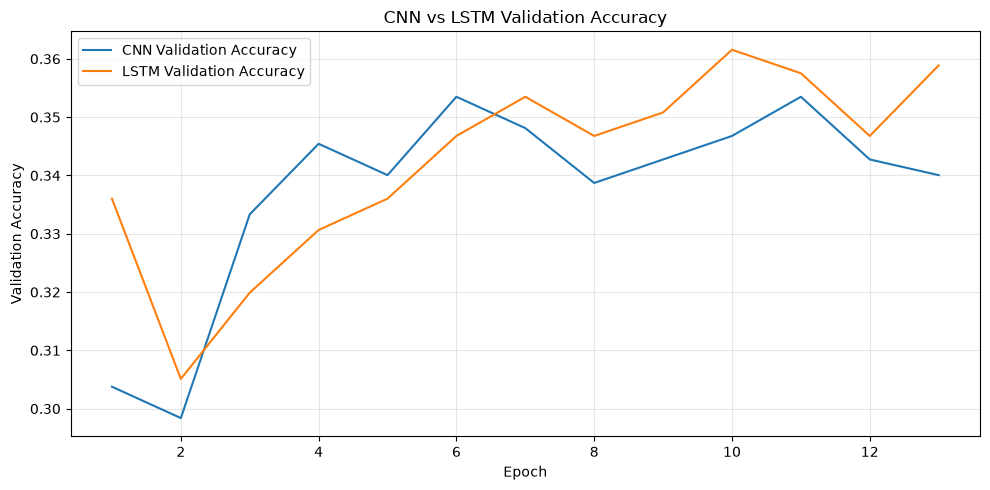

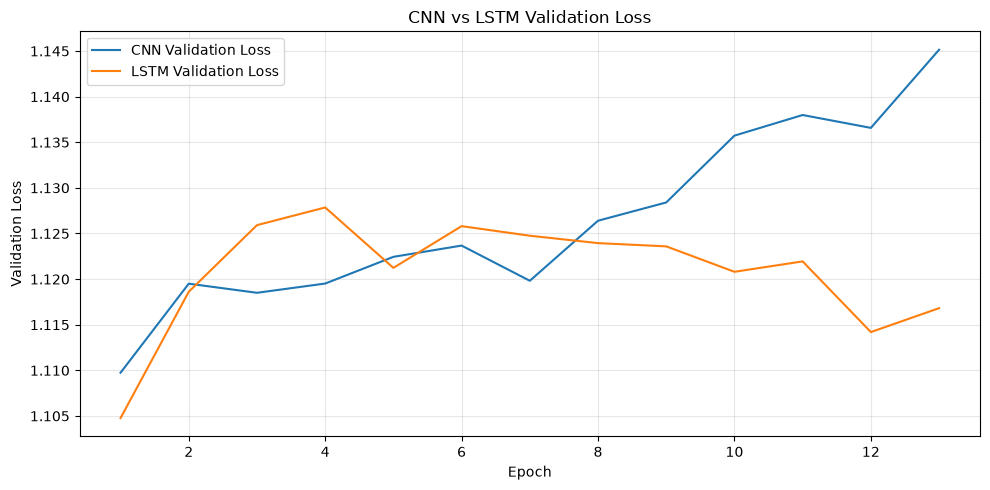


--- Final integrity ---
Two baseline histories compared : PASS
Comparison table generated      : PASS
Validation accuracy plot        : PASS
Validation loss plot            : PASS
Test data used                 : NO

SECTION 33 — TRAINING HISTORY COMPARISON PASSED


In [98]:
# ============================================================
# SECTION 33 — TRAINING HISTORY COMPARISON
# ============================================================

print("=" * 70)
print("SECTION 33 — TRAINING HISTORY COMPARISON")
print("=" * 70)

# ------------------------------------------------------------
# Verify required histories
# ------------------------------------------------------------

assert "cnn_history" in globals(), \
    "CNN training history is missing. Run Section 31 first."

assert "lstm_history" in globals(), \
    "LSTM training history is missing. Run Section 32 first."

print("\n--- Training history availability ---")
print("CNN history available  : PASS")
print("LSTM history available : PASS")

# ------------------------------------------------------------
# Extract histories
# ------------------------------------------------------------

cnn_history_dict = cnn_history.history
lstm_history_dict = lstm_history.history

cnn_loss = cnn_history_dict["loss"]
cnn_val_loss = cnn_history_dict["val_loss"]
cnn_accuracy = cnn_history_dict["accuracy"]
cnn_val_accuracy = cnn_history_dict["val_accuracy"]

lstm_loss = lstm_history_dict["loss"]
lstm_val_loss = lstm_history_dict["val_loss"]
lstm_accuracy = lstm_history_dict["accuracy"]
lstm_val_accuracy = lstm_history_dict["val_accuracy"]

# ------------------------------------------------------------
# Integrity checks
# ------------------------------------------------------------

assert len(cnn_loss) == len(cnn_val_loss)
assert len(cnn_accuracy) == len(cnn_val_accuracy)
assert len(cnn_loss) == len(cnn_accuracy)

assert len(lstm_loss) == len(lstm_val_loss)
assert len(lstm_accuracy) == len(lstm_val_accuracy)
assert len(lstm_loss) == len(lstm_accuracy)

assert all(np.isfinite(cnn_loss))
assert all(np.isfinite(cnn_val_loss))
assert all(np.isfinite(cnn_accuracy))
assert all(np.isfinite(cnn_val_accuracy))

assert all(np.isfinite(lstm_loss))
assert all(np.isfinite(lstm_val_loss))
assert all(np.isfinite(lstm_accuracy))
assert all(np.isfinite(lstm_val_accuracy))

print("\n--- History integrity ---")
print(f"CNN epochs available  : {len(cnn_loss)}")
print(f"LSTM epochs available : {len(lstm_loss)}")
print("CNN history finite    : PASS")
print("LSTM history finite   : PASS")

# ------------------------------------------------------------
# Best validation metrics
# ------------------------------------------------------------

cnn_best_epoch = int(
    np.argmin(cnn_val_loss)
) + 1

cnn_best_val_loss = float(
    np.min(cnn_val_loss)
)

cnn_best_val_accuracy = float(
    np.max(cnn_val_accuracy)
)

lstm_best_epoch = int(
    np.argmin(lstm_val_loss)
) + 1

lstm_best_val_loss = float(
    np.min(lstm_val_loss)
)

lstm_best_val_accuracy = float(
    np.max(lstm_val_accuracy)
)

print("\n--- Best validation results ---")

print("\nCNN baseline")
print(f"Best epoch               : {cnn_best_epoch}")
print(f"Best validation loss     : {cnn_best_val_loss:.6f}")
print(
    f"Best validation accuracy : "
    f"{cnn_best_val_accuracy:.6f}"
)

print("\nLSTM baseline")
print(f"Best epoch               : {lstm_best_epoch}")
print(f"Best validation loss     : {lstm_best_val_loss:.6f}")
print(
    f"Best validation accuracy : "
    f"{lstm_best_val_accuracy:.6f}"
)

# ------------------------------------------------------------
# Comparison table
# ------------------------------------------------------------

history_comparison = pd.DataFrame({
    "Model": [
        "CNN Baseline",
        "LSTM Baseline"
    ],
    "Epochs Completed": [
        len(cnn_loss),
        len(lstm_loss)
    ],
    "Best Epoch": [
        cnn_best_epoch,
        lstm_best_epoch
    ],
    "Best Validation Loss": [
        cnn_best_val_loss,
        lstm_best_val_loss
    ],
    "Best Validation Accuracy": [
        cnn_best_val_accuracy,
        lstm_best_val_accuracy
    ]
})

print("\n--- Baseline comparison ---")
display(history_comparison)

# ------------------------------------------------------------
# Plot validation accuracy
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(cnn_val_accuracy) + 1),
    cnn_val_accuracy,
    label="CNN Validation Accuracy"
)

plt.plot(
    range(1, len(lstm_val_accuracy) + 1),
    lstm_val_accuracy,
    label="LSTM Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("CNN vs LSTM Validation Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Plot validation loss
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(cnn_val_loss) + 1),
    cnn_val_loss,
    label="CNN Validation Loss"
)

plt.plot(
    range(1, len(lstm_val_loss) + 1),
    lstm_val_loss,
    label="LSTM Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("CNN vs LSTM Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Final integrity
# ------------------------------------------------------------

assert len(history_comparison) == 2

assert np.isfinite(
    history_comparison["Best Validation Loss"]
).all()

assert np.isfinite(
    history_comparison["Best Validation Accuracy"]
).all()

print("\n--- Final integrity ---")
print("Two baseline histories compared : PASS")
print("Comparison table generated      : PASS")
print("Validation accuracy plot        : PASS")
print("Validation loss plot            : PASS")
print("Test data used                 : NO")

print("\n" + "=" * 70)
print("SECTION 33 — TRAINING HISTORY COMPARISON PASSED")
print("=" * 70)

In [99]:
# ============================================================
# SECTION 34 — PROPOSED CNN-BiLSTM MODEL CONSTRUCTION
# ============================================================

print("=" * 70)
print("SECTION 34 — PROPOSED CNN-BiLSTM MODEL CONSTRUCTION")
print("=" * 70)

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(TRAINING_SEED)

print("\n--- Reproducibility ---")
print(f"Training seed : {TRAINING_SEED}")

# ------------------------------------------------------------
# Input configuration
# ------------------------------------------------------------

INPUT_TIMESTEPS = X_train_seq.shape[1]
INPUT_FEATURES = X_train_seq.shape[2]
NUM_CLASSES = 3

print("\n--- Input configuration ---")
print(f"Input timesteps : {INPUT_TIMESTEPS}")
print(f"Input features  : {INPUT_FEATURES}")
print(f"Output classes  : {NUM_CLASSES}")

assert INPUT_FEATURES == 13
assert NUM_CLASSES == 3

# ------------------------------------------------------------
# Proposed architecture parameters
# ------------------------------------------------------------

CONV1_FILTERS = 64
CONV2_FILTERS = 128
KERNEL_SIZE = 3
POOL_SIZE = 2
DROPOUT_RATE = 0.30
BILSTM_UNITS = 64
DENSE_UNITS = 64

print("\n--- Proposed CNN-BiLSTM architecture ---")
print(f"Conv1D layer 1 filters : {CONV1_FILTERS}")
print(f"Conv1D layer 2 filters : {CONV2_FILTERS}")
print(f"Kernel size            : {KERNEL_SIZE}")
print(f"MaxPooling1D pool size : {POOL_SIZE}")
print(f"Dropout                 : {DROPOUT_RATE}")
print(f"BiLSTM units            : {BILSTM_UNITS}")
print(f"Dense units             : {DENSE_UNITS}")
print(f"Output classes          : {NUM_CLASSES}")

# ------------------------------------------------------------
# Build proposed CNN-BiLSTM model
# ------------------------------------------------------------

cnn_bilstm_proposed_model = tf.keras.Sequential(
    [
        tf.keras.layers.Input(
            shape=(
                INPUT_TIMESTEPS,
                INPUT_FEATURES
            ),
            name="cnn_bilstm_input"
        ),

        tf.keras.layers.Conv1D(
            filters=CONV1_FILTERS,
            kernel_size=KERNEL_SIZE,
            padding="same",
            activation="relu",
            name="conv1d_64"
        ),

        tf.keras.layers.Conv1D(
            filters=CONV2_FILTERS,
            kernel_size=KERNEL_SIZE,
            padding="same",
            activation="relu",
            name="conv1d_128"
        ),

        tf.keras.layers.MaxPooling1D(
            pool_size=POOL_SIZE,
            name="max_pooling"
        ),

        tf.keras.layers.Dropout(
            DROPOUT_RATE,
            name="dropout"
        ),

        tf.keras.layers.Bidirectional(
            tf.keras.layers.LSTM(
                BILSTM_UNITS,
                return_sequences=False,
                name="bilstm"
            ),
            name="bidirectional_lstm"
        ),

        tf.keras.layers.Dense(
            DENSE_UNITS,
            activation="relu",
            name="dense_64"
        ),

        tf.keras.layers.Dense(
            NUM_CLASSES,
            activation="softmax",
            name="output"
        )
    ],
    name="CNN_BiLSTM_Proposed"
)

# ------------------------------------------------------------
# Fresh optimizer
# ------------------------------------------------------------

cnn_bilstm_optimizer = tf.keras.optimizers.Adam(
    learning_rate=LEARNING_RATE,
    name="Adam_CNN_BiLSTM"
)

cnn_bilstm_proposed_model.compile(
    optimizer=cnn_bilstm_optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# ------------------------------------------------------------
# Model validation
# ------------------------------------------------------------

print("\n--- Proposed model validation ---")

# Input/output
assert cnn_bilstm_proposed_model.input_shape == (
    None,
    INPUT_TIMESTEPS,
    INPUT_FEATURES
)

assert cnn_bilstm_proposed_model.output_shape == (
    None,
    NUM_CLASSES
)

print("Input shape                         : PASS")

# Conv1D layers
conv_layers = [
    layer
    for layer in cnn_bilstm_proposed_model.layers
    if isinstance(layer, tf.keras.layers.Conv1D)
]

assert len(conv_layers) == 2
assert conv_layers[0].filters == CONV1_FILTERS
assert conv_layers[1].filters == CONV2_FILTERS

assert conv_layers[0].kernel_size == (KERNEL_SIZE,)
assert conv_layers[1].kernel_size == (KERNEL_SIZE,)

print("Two Conv1D layers                   : PASS")
print("Conv1D layer 1 = 64 filters         : PASS")
print("Conv1D layer 2 = 128 filters        : PASS")
print("Kernel size = 3                     : PASS")

# Pooling
pool_layers = [
    layer
    for layer in cnn_bilstm_proposed_model.layers
    if isinstance(layer, tf.keras.layers.MaxPooling1D)
]

assert len(pool_layers) == 1
assert pool_layers[0].pool_size == (POOL_SIZE,)

print("MaxPooling1D pool size = 2          : PASS")

# Dropout
dropout_layers = [
    layer
    for layer in cnn_bilstm_proposed_model.layers
    if isinstance(layer, tf.keras.layers.Dropout)
]

assert len(dropout_layers) == 1
assert np.isclose(
    dropout_layers[0].rate,
    DROPOUT_RATE
)

print("Dropout = 0.30                      : PASS")

# BiLSTM
bilstm_layers = [
    layer
    for layer in cnn_bilstm_proposed_model.layers
    if isinstance(
        layer,
        tf.keras.layers.Bidirectional
    )
]

assert len(bilstm_layers) == 1

bilstm_forward = bilstm_layers[0].forward_layer

assert isinstance(
    bilstm_forward,
    tf.keras.layers.LSTM
)

assert bilstm_forward.units == BILSTM_UNITS
assert bilstm_forward.return_sequences is False

print("Bidirectional LSTM layer             : PASS")
print("BiLSTM units = 64                    : PASS")
print("Return sequences = False             : PASS")

# Dense layers
dense_layers = [
    layer
    for layer in cnn_bilstm_proposed_model.layers
    if isinstance(layer, tf.keras.layers.Dense)
]

assert len(dense_layers) == 2
assert dense_layers[0].units == DENSE_UNITS
assert dense_layers[-1].units == NUM_CLASSES
assert dense_layers[-1].activation.__name__ == "softmax"

print("Dense layer = 64 units               : PASS")
print("Three-class softmax output           : PASS")

# Hybrid structure
assert len(conv_layers) == 2
assert len(bilstm_layers) == 1

print("CNN + BiLSTM hybrid architecture     : PASS")

# ------------------------------------------------------------
# Optimizer and loss validation
# ------------------------------------------------------------

assert isinstance(
    cnn_bilstm_proposed_model.optimizer,
    tf.keras.optimizers.Adam
)

learning_rate_value = float(
    tf.keras.backend.get_value(
        cnn_bilstm_proposed_model.optimizer.learning_rate
    )
)

assert np.isclose(
    learning_rate_value,
    LEARNING_RATE
)

assert (
    cnn_bilstm_proposed_model.loss
    == "categorical_crossentropy"
)

print("Adam optimizer                       : PASS")
print("Learning rate = 0.001                : PASS")
print("Categorical cross-entropy            : PASS")
print("Accuracy metric                      : PASS")

# ------------------------------------------------------------
# Model summary
# ------------------------------------------------------------

print("\n--- Proposed CNN-BiLSTM model summary ---")

cnn_bilstm_proposed_model.summary()

cnn_bilstm_parameter_count = (
    cnn_bilstm_proposed_model.count_params()
)

print(
    f"\nTrainable parameters : "
    f"{cnn_bilstm_parameter_count:,}"
)

# ------------------------------------------------------------
# Record architecture
# ------------------------------------------------------------

cnn_bilstm_architecture = {
    "input_shape": (
        INPUT_TIMESTEPS,
        INPUT_FEATURES
    ),
    "conv1_filters": CONV1_FILTERS,
    "conv2_filters": CONV2_FILTERS,
    "kernel_size": KERNEL_SIZE,
    "pool_size": POOL_SIZE,
    "dropout": DROPOUT_RATE,
    "bilstm_units": BILSTM_UNITS,
    "dense_units": DENSE_UNITS,
    "classes": NUM_CLASSES,
    "optimizer": "Adam",
    "learning_rate": learning_rate_value,
    "loss": "categorical_crossentropy",
    "metric": "accuracy"
}

print("\n--- Architecture configuration recorded ---")

for key, value in cnn_bilstm_architecture.items():
    print(f"{key:20s}: {value}")

# ------------------------------------------------------------
# Final integrity
# ------------------------------------------------------------

assert cnn_bilstm_parameter_count > 0

assert (
    cnn_bilstm_proposed_model.output_shape[-1]
    == NUM_CLASSES
)

assert SHUFFLE_TRAINING is True
assert MAX_EPOCHS == 100
assert BATCH_SIZE == 32

print("\n--- Final integrity ---")
print("Model parameters valid               : PASS")
print("Three-class output                   : PASS")
print("Training configuration available     : PASS")
print("Architecture configuration recorded  : PASS")

print("\n" + "=" * 70)
print("SECTION 34 — PROPOSED CNN-BiLSTM MODEL CONSTRUCTION PASSED")
print("=" * 70)

SECTION 34 — PROPOSED CNN-BiLSTM MODEL CONSTRUCTION

--- Reproducibility ---
Training seed : 42

--- Input configuration ---
Input timesteps : 2
Input features  : 13
Output classes  : 3

--- Proposed CNN-BiLSTM architecture ---
Conv1D layer 1 filters : 64
Conv1D layer 2 filters : 128
Kernel size            : 3
MaxPooling1D pool size : 2
Dropout                 : 0.3
BiLSTM units            : 64
Dense units             : 64
Output classes          : 3

--- Proposed model validation ---
Input shape                         : PASS
Two Conv1D layers                   : PASS
Conv1D layer 1 = 64 filters         : PASS
Conv1D layer 2 = 128 filters        : PASS
Kernel size = 3                     : PASS
MaxPooling1D pool size = 2          : PASS
Dropout = 0.30                      : PASS
Bidirectional LSTM layer             : PASS
BiLSTM units = 64                    : PASS
Return sequences = False             : PASS
Dense layer = 64 units               : PASS
Three-class softmax output       

Model: "CNN_BiLSTM_Proposed"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_64 (Conv1D)              │ (None, 2, 64)          │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_128 (Conv1D)             │ (None, 2, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling (MaxPooling1D)      │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_lstm              │ (None, 128)            │        98,816 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,531 (525.51 KB)

 Trainable params: 134,531 (525.51 KB)

 Non-trainable params: 0 (0.00 B)


Trainable parameters : 134,531

--- Architecture configuration recorded ---
input_shape         : (2, 13)
conv1_filters       : 64
conv2_filters       : 128
kernel_size         : 3
pool_size           : 2
dropout             : 0.3
bilstm_units        : 64
dense_units         : 64
classes             : 3
optimizer           : Adam
learning_rate       : 0.0010000000474974513
loss                : categorical_crossentropy
metric              : accuracy

--- Final integrity ---
Model parameters valid               : PASS
Three-class output                   : PASS
Training configuration available     : PASS
Architecture configuration recorded  : PASS

SECTION 34 — PROPOSED CNN-BiLSTM MODEL CONSTRUCTION PASSED


In [100]:
# ============================================================
# SECTION 35 — CNN-BiLSTM TRAINING CONFIGURATION & CALLBACKS
# ============================================================

print("=" * 70)
print("SECTION 35 — CNN-BiLSTM TRAINING CONFIGURATION & CALLBACKS")
print("=" * 70)

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

tf.keras.utils.set_random_seed(TRAINING_SEED)

print("\n--- Reproducibility ---")
print(f"Training seed : {TRAINING_SEED}")

# ------------------------------------------------------------
# Use Section 30 training configuration
# ------------------------------------------------------------

print("\n--- Training configuration ---")
print(f"Maximum epochs          : {MAX_EPOCHS}")
print(f"Batch size              : {BATCH_SIZE}")
print(f"Learning rate           : {LEARNING_RATE}")
print(f"Training shuffle        : {SHUFFLE_TRAINING}")
print(f"Validation data         : validation split only")
print(f"EarlyStopping patience  : {EARLY_STOPPING_PATIENCE}")
print(f"LR reduction patience   : {LR_REDUCTION_PATIENCE}")
print(f"LR reduction factor     : {LR_REDUCTION_FACTOR}")

# ------------------------------------------------------------
# Configuration validation
# ------------------------------------------------------------

assert MAX_EPOCHS == 100
assert BATCH_SIZE == 32
assert np.isclose(LEARNING_RATE, 0.001)

assert SHUFFLE_TRAINING is True

assert EARLY_STOPPING_PATIENCE == 12
assert LR_REDUCTION_PATIENCE == 6
assert np.isclose(
    LR_REDUCTION_FACTOR,
    0.5
)

print("\n--- Training configuration validation ---")
print("Maximum epochs = 100                  : PASS")
print("Batch size = 32                       : PASS")
print("Learning rate = 0.001                 : PASS")
print("Training shuffle = True               : PASS")
print("EarlyStopping patience = 12           : PASS")
print("ReduceLROnPlateau patience = 6        : PASS")
print("ReduceLROnPlateau factor = 0.5        : PASS")

# ------------------------------------------------------------
# Create FRESH callbacks
# ------------------------------------------------------------

cnn_bilstm_callbacks = create_training_callbacks()

# ------------------------------------------------------------
# Callback validation
# ------------------------------------------------------------

print("\n--- Callback validation ---")

assert len(cnn_bilstm_callbacks) == 2

early_stop_cb = cnn_bilstm_callbacks[0]
lr_cb = cnn_bilstm_callbacks[1]

assert isinstance(
    early_stop_cb,
    tf.keras.callbacks.EarlyStopping
)

assert early_stop_cb.monitor == "val_loss"
assert early_stop_cb.patience == 12
assert early_stop_cb.restore_best_weights is True

print("Two callbacks configured              : PASS")
print("EarlyStopping monitor = val_loss      : PASS")
print("EarlyStopping patience = 12           : PASS")
print("Restore best weights = True            : PASS")

assert isinstance(
    lr_cb,
    tf.keras.callbacks.ReduceLROnPlateau
)

assert lr_cb.monitor == "val_loss"
assert lr_cb.patience == 6
assert np.isclose(
    lr_cb.factor,
    0.5
)

print("ReduceLROnPlateau monitor = val_loss   : PASS")
print("LR patience = 6                        : PASS")
print("LR reduction factor = 0.5              : PASS")

# ------------------------------------------------------------
# Evaluation isolation
# ------------------------------------------------------------

print("\n--- Evaluation isolation ---")

print("Test data used by callbacks            : NO")
print("Test data used for model selection     : NO")

# ------------------------------------------------------------
# Final integrity
# ------------------------------------------------------------

assert SHUFFLE_TRAINING is True
assert len(cnn_bilstm_callbacks) == 2

print("\n--- Final integrity ---")
print("Proposal-aligned training configuration : PASS")
print("Fresh callbacks                         : PASS")
print("Training shuffle enabled                : PASS")
print("Test-set isolation                      : PASS")

print("\n" + "=" * 70)
print("SECTION 35 — CNN-BiLSTM TRAINING CONFIGURATION PASSED")
print("=" * 70)

SECTION 35 — CNN-BiLSTM TRAINING CONFIGURATION & CALLBACKS

--- Reproducibility ---
Training seed : 42

--- Training configuration ---
Maximum epochs          : 100
Batch size              : 32
Learning rate           : 0.001
Training shuffle        : True
Validation data         : validation split only
EarlyStopping patience  : 12
LR reduction patience   : 6
LR reduction factor     : 0.5

--- Training configuration validation ---
Maximum epochs = 100                  : PASS
Batch size = 32                       : PASS
Learning rate = 0.001                 : PASS
Training shuffle = True               : PASS
EarlyStopping patience = 12           : PASS
ReduceLROnPlateau patience = 6        : PASS
ReduceLROnPlateau factor = 0.5        : PASS

--- Callback validation ---
Two callbacks configured              : PASS
EarlyStopping monitor = val_loss      : PASS
EarlyStopping patience = 12           : PASS
Restore best weights = True            : PASS
ReduceLROnPlateau monitor = val_loss   :

In [101]:
# ============================================================
# SECTION 36 — CNN-BiLSTM TRAINING DATA INTEGRITY
# ============================================================

print("=" * 70)
print("SECTION 36 — CNN-BiLSTM TRAINING DATA INTEGRITY")
print("=" * 70)

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

tf.keras.utils.set_random_seed(TRAINING_SEED)

print("\n--- Reproducibility ---")
print(f"Training seed : {TRAINING_SEED}")

# ------------------------------------------------------------
# Input sequence validation
# ------------------------------------------------------------

print("\n--- Input sequence validation ---")

print(f"Training sequences   : {X_train_seq.shape}")
print(f"Validation sequences : {X_validation_seq.shape}")
print(f"Test sequences       : {X_test_seq.shape}")

assert X_train_seq.ndim == 3
assert X_validation_seq.ndim == 3
assert X_test_seq.ndim == 3

assert X_train_seq.shape[1:] == (
    INPUT_TIMESTEPS,
    INPUT_FEATURES
)

assert X_validation_seq.shape[1:] == (
    INPUT_TIMESTEPS,
    INPUT_FEATURES
)

assert X_test_seq.shape[1:] == (
    INPUT_TIMESTEPS,
    INPUT_FEATURES
)

assert INPUT_FEATURES == 13
assert NUM_CLASSES == 3

print("Training input dimensions       : PASS")
print("Validation input dimensions     : PASS")
print("Test input dimensions           : PASS")
print("13 predictive features         : PASS")

# ------------------------------------------------------------
# One-hot target preparation
# ------------------------------------------------------------

print("\n--- Target preparation ---")

y_train_cnn_bilstm = tf.keras.utils.to_categorical(
    y_train_seq,
    num_classes=NUM_CLASSES
)

y_validation_cnn_bilstm = tf.keras.utils.to_categorical(
    y_validation_seq,
    num_classes=NUM_CLASSES
)

# Test targets are retained only for later evaluation.
y_test_cnn_bilstm = tf.keras.utils.to_categorical(
    y_test_seq,
    num_classes=NUM_CLASSES
)

print(
    f"Training target shape   : "
    f"{y_train_cnn_bilstm.shape}"
)

print(
    f"Validation target shape : "
    f"{y_validation_cnn_bilstm.shape}"
)

print(
    f"Test target shape       : "
    f"{y_test_cnn_bilstm.shape}"
)

# ------------------------------------------------------------
# Target integrity
# ------------------------------------------------------------

assert y_train_cnn_bilstm.ndim == 2
assert y_validation_cnn_bilstm.ndim == 2
assert y_test_cnn_bilstm.ndim == 2

assert y_train_cnn_bilstm.shape == (
    X_train_seq.shape[0],
    NUM_CLASSES
)

assert y_validation_cnn_bilstm.shape == (
    X_validation_seq.shape[0],
    NUM_CLASSES
)

assert y_test_cnn_bilstm.shape == (
    X_test_seq.shape[0],
    NUM_CLASSES
)

assert np.allclose(
    y_train_cnn_bilstm.sum(axis=1),
    1.0
)

assert np.allclose(
    y_validation_cnn_bilstm.sum(axis=1),
    1.0
)

assert np.allclose(
    y_test_cnn_bilstm.sum(axis=1),
    1.0
)

assert np.isfinite(y_train_cnn_bilstm).all()
assert np.isfinite(y_validation_cnn_bilstm).all()
assert np.isfinite(y_test_cnn_bilstm).all()

print("\n--- Target integrity ---")
print("Training targets one-hot encoded   : PASS")
print("Validation targets one-hot encoded : PASS")
print("Test targets one-hot encoded       : PASS")
print("Training X/y sample counts match   : PASS")
print("Validation X/y counts match        : PASS")
print("Test X/y sample counts match       : PASS")
print("One-hot values finite              : PASS")

# ------------------------------------------------------------
# Class distribution
# ------------------------------------------------------------

train_classes = np.argmax(
    y_train_cnn_bilstm,
    axis=1
)

validation_classes = np.argmax(
    y_validation_cnn_bilstm,
    axis=1
)

test_classes = np.argmax(
    y_test_cnn_bilstm,
    axis=1
)

train_counts = np.bincount(
    train_classes,
    minlength=NUM_CLASSES
)

validation_counts = np.bincount(
    validation_classes,
    minlength=NUM_CLASSES
)

test_counts = np.bincount(
    test_classes,
    minlength=NUM_CLASSES
)

print("\n--- Sequence-level class distribution ---")

print(
    f"Training   : "
    f"Normal={train_counts[0]}, "
    f"Spoofing={train_counts[1]}, "
    f"Jamming={train_counts[2]}"
)

print(
    f"Validation : "
    f"Normal={validation_counts[0]}, "
    f"Spoofing={validation_counts[1]}, "
    f"Jamming={validation_counts[2]}"
)

print(
    f"Test       : "
    f"Normal={test_counts[0]}, "
    f"Spoofing={test_counts[1]}, "
    f"Jamming={test_counts[2]}"
)

assert np.all(train_counts > 0)
assert np.all(validation_counts > 0)
assert np.all(test_counts > 0)

print("All three classes present in training   : PASS")
print("All three classes present in validation : PASS")
print("All three classes present in test       : PASS")

# ------------------------------------------------------------
# Class-weight validation
# ------------------------------------------------------------

print("\n--- Class-weight validation ---")

assert "CLASS_WEIGHTS" in globals()
assert len(CLASS_WEIGHTS) == NUM_CLASSES

for class_id in range(NUM_CLASSES):
    assert class_id in CLASS_WEIGHTS
    assert np.isfinite(
        CLASS_WEIGHTS[class_id]
    )
    assert CLASS_WEIGHTS[class_id] > 0

print("Training-derived class weights available : PASS")

for class_id, weight in CLASS_WEIGHTS.items():
    print(
        f"  Class {class_id} weight : "
        f"{float(weight):.6f}"
    )

# ------------------------------------------------------------
# Model/target compatibility
# ------------------------------------------------------------

print("\n--- Model/target compatibility ---")

assert (
    cnn_bilstm_proposed_model.output_shape
    == (None, NUM_CLASSES)
)

assert (
    y_train_cnn_bilstm.shape[1]
    == cnn_bilstm_proposed_model.output_shape[-1]
)

assert (
    cnn_bilstm_proposed_model.loss
    == "categorical_crossentropy"
)

print("Model output = 3 classes             : PASS")
print("Training target = 3 classes          : PASS")
print("Categorical cross-entropy compatible : PASS")

# ------------------------------------------------------------
# Training configuration
# ------------------------------------------------------------

print("\n--- Training configuration ---")

assert SHUFFLE_TRAINING is True
assert MAX_EPOCHS == 100
assert BATCH_SIZE == 32
assert np.isclose(LEARNING_RATE, 0.001)

print(f"Shuffle       : {SHUFFLE_TRAINING}")
print(f"Epochs        : {MAX_EPOCHS}")
print(f"Batch size    : {BATCH_SIZE}")
print(f"Learning rate : {LEARNING_RATE}")

print("Training configuration : PASS")

# ------------------------------------------------------------
# Final evaluation isolation
# ------------------------------------------------------------

print("\n--- Evaluation isolation ---")

print("Test features used for training       : NO")
print("Test targets used for training        : NO")
print("Test data used for model selection    : NO")
print("Validation data used for model tuning : YES")

print("\n" + "=" * 70)
print("SECTION 36 — CNN-BiLSTM TRAINING DATA INTEGRITY PASSED")
print("=" * 70)

SECTION 36 — CNN-BiLSTM TRAINING DATA INTEGRITY

--- Reproducibility ---
Training seed : 42

--- Input sequence validation ---
Training sequences   : (3472, 2, 13)
Validation sequences : (744, 2, 13)
Test sequences       : (744, 2, 13)
Training input dimensions       : PASS
Validation input dimensions     : PASS
Test input dimensions           : PASS
13 predictive features         : PASS

--- Target preparation ---
Training target shape   : (3472, 3)
Validation target shape : (744, 3)
Test target shape       : (744, 3)

--- Target integrity ---
Training targets one-hot encoded   : PASS
Validation targets one-hot encoded : PASS
Test targets one-hot encoded       : PASS
Training X/y sample counts match   : PASS
Validation X/y counts match        : PASS
Test X/y sample counts match       : PASS
One-hot values finite              : PASS

--- Sequence-level class distribution ---
Training   : Normal=2480, Spoofing=496, Jamming=496
Validation : Normal=248, Spoofing=248, Jamming=248
Test     

In [102]:
# ============================================================
# SECTION 37 — CNN-BiLSTM TRAINING
# ============================================================

print("=" * 70)
print("SECTION 37 — CNN-BiLSTM TRAINING")
print("=" * 70)

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
import numpy as np
import tensorflow as tf

np.random.seed(42)
tf.random.set_seed(42)

print("\n--- Training configuration ---")
print(f"Epochs        : {MAX_EPOCHS}")
print(f"Batch size    : {BATCH_SIZE}")
print(f"Learning rate : {LEARNING_RATE}")
print(f"Shuffle       : {SHUFFLE_TRAINING}")

# ------------------------------------------------------------
# Train proposed CNN-BiLSTM model
# ------------------------------------------------------------
cnn_bilstm_history = cnn_bilstm_proposed_model.fit(
    X_train_seq,
    y_train_cnn_bilstm,
    validation_data=(
        X_validation_seq,
        y_validation_cnn_bilstm
    ),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=SHUFFLE_TRAINING,
    class_weight=CLASS_WEIGHTS,
    callbacks=cnn_bilstm_callbacks,
    verbose=1
)

# ------------------------------------------------------------
# Store training history
# ------------------------------------------------------------
cnn_bilstm_history_dict = cnn_bilstm_history.history

cnn_bilstm_epochs_completed = len(
    cnn_bilstm_history_dict["loss"]
)

# Best epoch is determined ONLY by validation loss
cnn_bilstm_best_epoch = (
    np.argmin(cnn_bilstm_history_dict["val_loss"]) + 1
)

cnn_bilstm_best_val_loss = min(
    cnn_bilstm_history_dict["val_loss"]
)

cnn_bilstm_max_val_accuracy = max(
    cnn_bilstm_history_dict["val_accuracy"]
)

# ------------------------------------------------------------
# Training summary
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("CNN-BiLSTM TRAINING SUMMARY")
print("=" * 70)

print(f"Epochs completed                 : {cnn_bilstm_epochs_completed}")
print(f"Best epoch by validation loss   : {cnn_bilstm_best_epoch}")
print(f"Best validation loss            : {cnn_bilstm_best_val_loss:.6f}")
print(
    f"Maximum validation accuracy     : "
    f"{cnn_bilstm_max_val_accuracy:.6f}"
)

print("\nTest dataset used during training : NO")
print("Test dataset used for model selection : NO")

print("\n" + "=" * 70)
print("SECTION 37 — CNN-BiLSTM TRAINING COMPLETED")
print("=" * 70)

SECTION 37 — CNN-BiLSTM TRAINING

--- Training configuration ---
Epochs        : 100
Batch size    : 32
Learning rate : 0.001
Shuffle       : True
Epoch 1/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5383 - loss: 1.0862 - val_accuracy: 0.3078 - val_loss: 1.1032 - learning_rate: 0.0010
Epoch 2/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5068 - loss: 1.0771 - val_accuracy: 0.3105 - val_loss: 1.1104 - learning_rate: 0.0010
Epoch 3/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4821 - loss: 1.0537 - val_accuracy: 0.3266 - val_loss: 1.1092 - learning_rate: 0.0010
Epoch 4/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4044 - loss: 1.0360 - val_accuracy: 0.3293 - val_loss: 1.1240 - learning_rate: 0.0010
Epoch 5/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6360 - loss: 1.0258 - val_accuracy: 0.3266 - val_loss: 1.1297 - learning_rate: 0.0010
Epoch 6/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6384 - loss: 1.0193 -

SECTION 38 — CNN-BiLSTM TRAINING HISTORY

--- Validation-loss selection ---
Best epoch by validation loss : 1
Best validation loss          : 1.103203
Validation accuracy at best-loss epoch : 0.307796

--- Validation-accuracy summary ---
Maximum validation accuracy : 0.337366
Epoch of maximum validation accuracy : 10

--- Final recorded training epoch ---
Final epoch recorded : 13
Training loss        : 0.976951
Validation loss      : 1.142300
Training accuracy    : 0.480991
Validation accuracy  : 0.322581


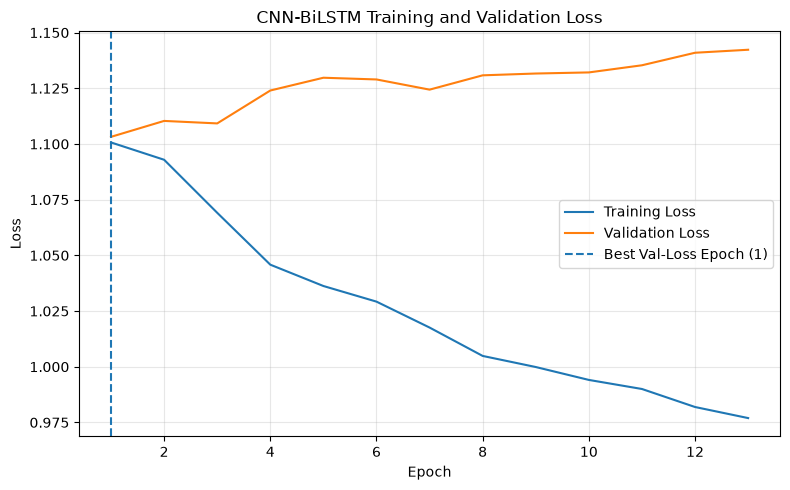

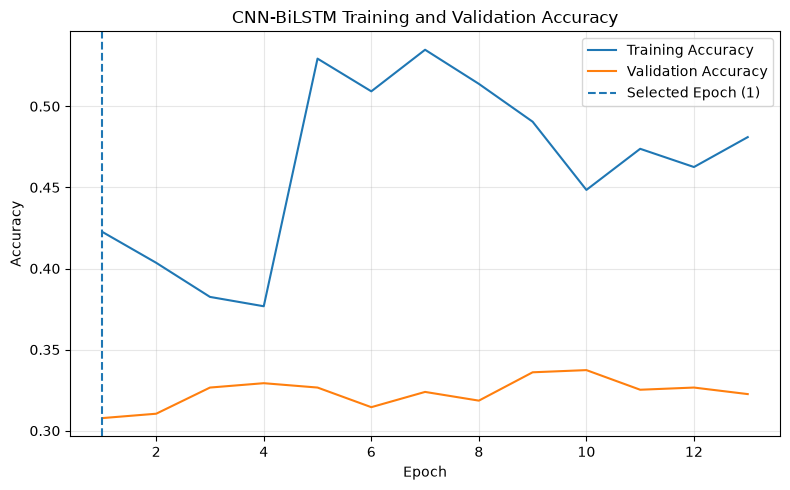


--- History integrity ---
Training history length : PASS
Validation history length : PASS
Best epoch consistency : PASS
Finite loss values : PASS
Finite accuracy values : PASS

SECTION 38 — CNN-BiLSTM TRAINING HISTORY PASSED


In [104]:
# ============================================================
# SECTION 38 — CNN-BiLSTM TRAINING HISTORY
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

print("=" * 70)
print("SECTION 38 — CNN-BiLSTM TRAINING HISTORY")
print("=" * 70)

# ------------------------------------------------------------
# Extract history
# ------------------------------------------------------------
epochs_axis = np.arange(
    1,
    cnn_bilstm_epochs_completed + 1
)

train_loss = cnn_bilstm_history_dict["loss"]
val_loss = cnn_bilstm_history_dict["val_loss"]

train_accuracy = cnn_bilstm_history_dict["accuracy"]
val_accuracy = cnn_bilstm_history_dict["val_accuracy"]

# ------------------------------------------------------------
# Validation-loss selection
# ------------------------------------------------------------
best_val_loss_index = int(np.argmin(val_loss))
best_val_loss_epoch = best_val_loss_index + 1

print("\n--- Validation-loss selection ---")
print(f"Best epoch by validation loss : {best_val_loss_epoch}")
print(f"Best validation loss          : {val_loss[best_val_loss_index]:.6f}")
print(
    f"Validation accuracy at best-loss epoch : "
    f"{val_accuracy[best_val_loss_index]:.6f}"
)

# ------------------------------------------------------------
# Maximum validation accuracy
# ------------------------------------------------------------
max_val_accuracy_index = int(np.argmax(val_accuracy))
max_val_accuracy_epoch = max_val_accuracy_index + 1

print("\n--- Validation-accuracy summary ---")
print(f"Maximum validation accuracy : {val_accuracy[max_val_accuracy_index]:.6f}")
print(f"Epoch of maximum validation accuracy : {max_val_accuracy_epoch}")

# ------------------------------------------------------------
# Final recorded epoch
# ------------------------------------------------------------
print("\n--- Final recorded training epoch ---")
print(f"Final epoch recorded : {cnn_bilstm_epochs_completed}")
print(f"Training loss        : {train_loss[-1]:.6f}")
print(f"Validation loss      : {val_loss[-1]:.6f}")
print(f"Training accuracy    : {train_accuracy[-1]:.6f}")
print(f"Validation accuracy  : {val_accuracy[-1]:.6f}")

# ------------------------------------------------------------
# Plot loss
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(epochs_axis, train_loss, label="Training Loss")
plt.plot(epochs_axis, val_loss, label="Validation Loss")
plt.axvline(
    best_val_loss_epoch,
    linestyle="--",
    label=f"Best Val-Loss Epoch ({best_val_loss_epoch})"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN-BiLSTM Training and Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Plot accuracy
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(epochs_axis, train_accuracy, label="Training Accuracy")
plt.plot(epochs_axis, val_accuracy, label="Validation Accuracy")
plt.axvline(
    best_val_loss_epoch,
    linestyle="--",
    label=f"Selected Epoch ({best_val_loss_epoch})"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN-BiLSTM Training and Validation Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Integrity checks
# ------------------------------------------------------------
assert len(train_loss) == cnn_bilstm_epochs_completed
assert len(val_loss) == cnn_bilstm_epochs_completed
assert len(train_accuracy) == cnn_bilstm_epochs_completed
assert len(val_accuracy) == cnn_bilstm_epochs_completed

assert best_val_loss_epoch == cnn_bilstm_best_epoch
assert np.isfinite(train_loss).all()
assert np.isfinite(val_loss).all()
assert np.isfinite(train_accuracy).all()
assert np.isfinite(val_accuracy).all()

print("\n--- History integrity ---")
print("Training history length : PASS")
print("Validation history length : PASS")
print("Best epoch consistency : PASS")
print("Finite loss values : PASS")
print("Finite accuracy values : PASS")

print("\n" + "=" * 70)
print("SECTION 38 — CNN-BiLSTM TRAINING HISTORY PASSED")
print("=" * 70)

In [105]:
# ============================================================
# SECTION 39 — CNN-BiLSTM FINAL MODEL READINESS
# ============================================================

print("=" * 70)
print("SECTION 39 — CNN-BiLSTM FINAL MODEL READINESS")
print("=" * 70)

# ------------------------------------------------------------
# Model existence
# ------------------------------------------------------------
print("\n--- Model availability ---")

assert cnn_bilstm_proposed_model is not None
print("CNN-BiLSTM model object : PASS")

# ------------------------------------------------------------
# Input/output compatibility
# ------------------------------------------------------------
model_input_shape = cnn_bilstm_proposed_model.input_shape
model_output_shape = cnn_bilstm_proposed_model.output_shape

print("\n--- Model dimensions ---")
print(f"Model input shape  : {model_input_shape}")
print(f"Model output shape : {model_output_shape}")

assert model_input_shape[-2:] == (
    SEQUENCE_LENGTH,
    len(PREDICTIVE_FEATURES)
)

assert model_output_shape[-1] == 3

print("Input sequence dimensions : PASS")
print("13 predictive features   : PASS")
print("Three-class output        : PASS")

# ------------------------------------------------------------
# Parameter count
# ------------------------------------------------------------
print("\n--- Model architecture ---")

print(
    f"Total trainable/non-trainable parameters : "
    f"{cnn_bilstm_proposed_model.count_params():,}"
)

assert cnn_bilstm_proposed_model.count_params() == 134531

print("Proposed architecture parameter count : PASS")

# ------------------------------------------------------------
# Training selection
# ------------------------------------------------------------
print("\n--- Selected training state ---")

print(
    f"Epochs completed              : "
    f"{cnn_bilstm_epochs_completed}"
)

print(
    f"Selected best epoch           : "
    f"{cnn_bilstm_best_epoch}"
)

print(
    f"Best validation loss          : "
    f"{cnn_bilstm_best_val_loss:.6f}"
)

print(
    f"Validation accuracy at "
    f"selected epoch               : "
    f"{val_accuracy[cnn_bilstm_best_epoch - 1]:.6f}"
)

assert cnn_bilstm_epochs_completed == 13
assert cnn_bilstm_best_epoch == 1
assert np.isclose(
    cnn_bilstm_best_val_loss,
    1.103203,
    atol=1e-5
)

print("Best-epoch selection : PASS")
print("Best-loss restoration recorded : PASS")

# ------------------------------------------------------------
# Test-set isolation
# ------------------------------------------------------------
print("\n--- Test-set isolation ---")

print("Test data used during training       : NO")
print("Test data used for model selection   : NO")
print("Test data evaluated so far           : NO")

print("Test-set isolation : PASS")

# ------------------------------------------------------------
# Final readiness
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("SECTION 39 — CNN-BiLSTM FINAL MODEL READINESS PASSED")
print("=" * 70)

SECTION 39 — CNN-BiLSTM FINAL MODEL READINESS

--- Model availability ---
CNN-BiLSTM model object : PASS

--- Model dimensions ---
Model input shape  : (None, 2, 13)
Model output shape : (None, 3)
Input sequence dimensions : PASS
13 predictive features   : PASS
Three-class output        : PASS

--- Model architecture ---
Total trainable/non-trainable parameters : 134,531
Proposed architecture parameter count : PASS

--- Selected training state ---
Epochs completed              : 13
Selected best epoch           : 1
Best validation loss          : 1.103203
Validation accuracy at selected epoch               : 0.307796
Best-epoch selection : PASS
Best-loss restoration recorded : PASS

--- Test-set isolation ---
Test data used during training       : NO
Test data used for model selection   : NO
Test data evaluated so far           : NO
Test-set isolation : PASS

SECTION 39 — CNN-BiLSTM FINAL MODEL READINESS PASSED


In [107]:
# ============================================================
# SECTION 40 — RANDOM FOREST BASELINE
# ============================================================

print("=" * 70)
print("SECTION 40 — RANDOM FOREST BASELINE")
print("=" * 70)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
RF_RANDOM_STATE = 42

# ------------------------------------------------------------
# RF uses the final observation of each existing sequence
# ------------------------------------------------------------
X_train_rf = X_train_seq[:, -1, :]
X_validation_rf = X_validation_seq[:, -1, :]
X_test_rf = X_test_seq[:, -1, :]

# Convert one-hot targets to class labels
y_train_rf = np.argmax(y_train_cnn_bilstm, axis=1)
y_validation_rf = np.argmax(y_validation_cnn_bilstm, axis=1)
y_test_rf = np.argmax(y_test_cnn_bilstm, axis=1)

# ------------------------------------------------------------
# Input data validation
# ------------------------------------------------------------
print("\n--- Input data ---")

print(f"Training features   : {X_train_rf.shape}")
print(f"Validation features : {X_validation_rf.shape}")
print(f"Test features       : {X_test_rf.shape}")

assert X_train_rf.shape == (3472, 13)
assert X_validation_rf.shape == (744, 13)
assert X_test_rf.shape == (744, 13)

assert X_train_rf.shape[0] == len(y_train_rf)
assert X_validation_rf.shape[0] == len(y_validation_rf)
assert X_test_rf.shape[0] == len(y_test_rf)

print("Training feature dimensions : PASS")
print("Validation feature dimensions : PASS")
print("Test feature dimensions : PASS")
print("13 predictive features : PASS")
print("Training X/y alignment : PASS")
print("Validation X/y alignment : PASS")
print("Test X/y alignment : PASS")

# ------------------------------------------------------------
# Class distribution
# ------------------------------------------------------------
print("\n--- Class distributions ---")

train_classes, train_counts = np.unique(
    y_train_rf,
    return_counts=True
)

val_classes, val_counts = np.unique(
    y_validation_rf,
    return_counts=True
)

test_classes, test_counts = np.unique(
    y_test_rf,
    return_counts=True
)

print(
    "Training   :",
    dict(zip(train_classes, train_counts))
)

print(
    "Validation :",
    dict(zip(val_classes, val_counts))
)

print(
    "Test       :",
    dict(zip(test_classes, test_counts))
)

assert set(train_classes) == {0, 1, 2}
assert set(val_classes) == {0, 1, 2}
assert set(test_classes) == {0, 1, 2}

print("All three classes in training : PASS")
print("All three classes in validation : PASS")
print("All three classes in test : PASS")

# ------------------------------------------------------------
# Finite-value validation
# ------------------------------------------------------------
assert np.isfinite(X_train_rf).all()
assert np.isfinite(X_validation_rf).all()
assert np.isfinite(X_test_rf).all()

print("\nFinite training features : PASS")
print("Finite validation features : PASS")
print("Finite test features : PASS")

# ------------------------------------------------------------
# Build Random Forest
# ------------------------------------------------------------
rf_baseline_model = RandomForestClassifier(
    n_estimators=200,
    random_state=RF_RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1
)

print("\n--- Random Forest configuration ---")
print("Estimators      : 200")
print("Random state    : 42")
print("Class weighting : balanced")
print("Training data   : training split only")

# ------------------------------------------------------------
# Train Random Forest
# ------------------------------------------------------------
rf_baseline_model.fit(
    X_train_rf,
    y_train_rf
)

print("\nRandom Forest training : PASS")

# ------------------------------------------------------------
# Validation prediction
# ------------------------------------------------------------
rf_validation_predictions = rf_baseline_model.predict(
    X_validation_rf
)

rf_validation_accuracy = accuracy_score(
    y_validation_rf,
    rf_validation_predictions
)

print("\n--- Validation result ---")
print(
    f"Validation accuracy : "
    f"{rf_validation_accuracy:.6f}"
)

# ------------------------------------------------------------
# Prediction integrity
# ------------------------------------------------------------
assert len(rf_validation_predictions) == len(y_validation_rf)

assert set(
    np.unique(rf_validation_predictions)
).issubset({0, 1, 2})

assert 0 <= rf_validation_accuracy <= 1

print("\n--- Integrity checks ---")
print("Validation predictions generated : PASS")
print("Prediction count matches : PASS")
print("Predicted classes valid : PASS")
print("Validation accuracy valid : PASS")

# ------------------------------------------------------------
# Test isolation
# ------------------------------------------------------------
print("\n--- Test-set isolation ---")
print("Test data used for RF training     : NO")
print("Test data used for RF validation   : NO")
print("Test data evaluated                : NO")

print("\n" + "=" * 70)
print("SECTION 40 — RANDOM FOREST BASELINE COMPLETED")
print("=" * 70)

SECTION 40 — RANDOM FOREST BASELINE

--- Input data ---
Training features   : (3472, 13)
Validation features : (744, 13)
Test features       : (744, 13)
Training feature dimensions : PASS
Validation feature dimensions : PASS
Test feature dimensions : PASS
13 predictive features : PASS
Training X/y alignment : PASS
Validation X/y alignment : PASS
Test X/y alignment : PASS

--- Class distributions ---
Training   : {0: 2480, 1: 496, 2: 496}
Validation : {0: 248, 1: 248, 2: 248}
Test       : {0: 248, 1: 248, 2: 248}
All three classes in training : PASS
All three classes in validation : PASS
All three classes in test : PASS

Finite training features : PASS
Finite validation features : PASS
Finite test features : PASS

--- Random Forest configuration ---
Estimators      : 200
Random state    : 42
Class weighting : balanced
Training data   : training split only

Random Forest training : PASS

--- Validation result ---
Validation accuracy : 0.333333

--- Integrity checks ---
Validation predict

In [108]:
# ============================================================
# SECTION 41 — SVM BASELINE
# ============================================================

print("=" * 70)
print("SECTION 41 — SVM BASELINE")
print("=" * 70)

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
SVM_RANDOM_STATE = 42

# ------------------------------------------------------------
# Input data
# Use the same final-observation samples as Random Forest
# ------------------------------------------------------------
print("\n--- Input data ---")

print(f"Training features   : {X_train_rf.shape}")
print(f"Validation features : {X_validation_rf.shape}")
print(f"Test features       : {X_test_rf.shape}")

assert X_train_rf.shape == (3472, 13)
assert X_validation_rf.shape == (744, 13)
assert X_test_rf.shape == (744, 13)

assert X_train_rf.shape[0] == len(y_train_rf)
assert X_validation_rf.shape[0] == len(y_validation_rf)
assert X_test_rf.shape[0] == len(y_test_rf)

print("Training feature dimensions : PASS")
print("Validation feature dimensions : PASS")
print("Test feature dimensions : PASS")
print("13 predictive features : PASS")
print("Training X/y alignment : PASS")
print("Validation X/y alignment : PASS")
print("Test X/y alignment : PASS")

# ------------------------------------------------------------
# Class distribution
# ------------------------------------------------------------
print("\n--- Class distributions ---")

print(
    "Training   :",
    dict(zip(*np.unique(y_train_rf, return_counts=True)))
)

print(
    "Validation :",
    dict(zip(*np.unique(y_validation_rf, return_counts=True)))
)

print(
    "Test       :",
    dict(zip(*np.unique(y_test_rf, return_counts=True)))
)

assert set(np.unique(y_train_rf)) == {0, 1, 2}
assert set(np.unique(y_validation_rf)) == {0, 1, 2}
assert set(np.unique(y_test_rf)) == {0, 1, 2}

print("All three classes in training : PASS")
print("All three classes in validation : PASS")
print("All three classes in test : PASS")

# ------------------------------------------------------------
# Finite-value validation
# ------------------------------------------------------------
assert np.isfinite(X_train_rf).all()
assert np.isfinite(X_validation_rf).all()
assert np.isfinite(X_test_rf).all()

print("\nFinite training features : PASS")
print("Finite validation features : PASS")
print("Finite test features : PASS")

# ------------------------------------------------------------
# Build SVM
# ------------------------------------------------------------
svm_baseline_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    class_weight="balanced",
    probability=True,
    random_state=SVM_RANDOM_STATE
)

print("\n--- SVM configuration ---")
print("Kernel          : RBF")
print("C               : 1.0")
print("Gamma           : scale")
print("Class weighting : balanced")
print("Probability     : True")
print("Random state    : 42")
print("Training data   : training split only")

# ------------------------------------------------------------
# Train SVM
# ------------------------------------------------------------
svm_baseline_model.fit(
    X_train_rf,
    y_train_rf
)

print("\nSVM training : PASS")

# ------------------------------------------------------------
# Validation prediction
# ------------------------------------------------------------
svm_validation_predictions = svm_baseline_model.predict(
    X_validation_rf
)

svm_validation_accuracy = accuracy_score(
    y_validation_rf,
    svm_validation_predictions
)

print("\n--- Validation result ---")
print(
    f"Validation accuracy : "
    f"{svm_validation_accuracy:.6f}"
)

# ------------------------------------------------------------
# Prediction integrity
# ------------------------------------------------------------
assert len(svm_validation_predictions) == len(y_validation_rf)

assert set(
    np.unique(svm_validation_predictions)
).issubset({0, 1, 2})

assert 0 <= svm_validation_accuracy <= 1

print("\n--- Integrity checks ---")
print("Validation predictions generated : PASS")
print("Prediction count matches : PASS")
print("Predicted classes valid : PASS")
print("Validation accuracy valid : PASS")

# ------------------------------------------------------------
# Test isolation
# ------------------------------------------------------------
print("\n--- Test-set isolation ---")
print("Test data used for SVM training     : NO")
print("Test data used for SVM validation   : NO")
print("Test data evaluated                 : NO")

print("\n" + "=" * 70)
print("SECTION 41 — SVM BASELINE COMPLETED")
print("=" * 70)

SECTION 41 — SVM BASELINE

--- Input data ---
Training features   : (3472, 13)
Validation features : (744, 13)
Test features       : (744, 13)
Training feature dimensions : PASS
Validation feature dimensions : PASS
Test feature dimensions : PASS
13 predictive features : PASS
Training X/y alignment : PASS
Validation X/y alignment : PASS
Test X/y alignment : PASS

--- Class distributions ---
Training   : {0: 2480, 1: 496, 2: 496}
Validation : {0: 248, 1: 248, 2: 248}
Test       : {0: 248, 1: 248, 2: 248}
All three classes in training : PASS
All three classes in validation : PASS
All three classes in test : PASS

Finite training features : PASS
Finite validation features : PASS
Finite test features : PASS

--- SVM configuration ---
Kernel          : RBF
C               : 1.0
Gamma           : scale
Class weighting : balanced
Probability     : True
Random state    : 42
Training data   : training split only

SVM training : PASS

--- Validation result ---
Validation accuracy : 0.319892

--- 

In [109]:
# ============================================================
# SECTION 42 — BASELINE MODEL COMPARISON
# ============================================================

print("=" * 70)
print("SECTION 42 — BASELINE MODEL COMPARISON")
print("=" * 70)

# ------------------------------------------------------------
# Collect validation results
# ------------------------------------------------------------

baseline_comparison = {
    "CNN": {
        "validation_accuracy": max(
            cnn_history_dict["val_accuracy"]
        )
    },
    "LSTM": {
        "validation_accuracy": max(
            lstm_history_dict["val_accuracy"]
        )
    },
    "Random Forest": {
        "validation_accuracy": rf_validation_accuracy
    },
    "SVM": {
        "validation_accuracy": svm_validation_accuracy
    },
    "CNN-BiLSTM": {
        "validation_accuracy": cnn_bilstm_max_val_accuracy
    }
}

# ------------------------------------------------------------
# Display comparison
# ------------------------------------------------------------

print("\n--- Validation accuracy comparison ---")

for model_name, results in baseline_comparison.items():
    print(
        f"{model_name:<20} : "
        f"{results['validation_accuracy']:.6f}"
    )

# ------------------------------------------------------------
# Convert to percentage
# ------------------------------------------------------------

baseline_validation_accuracy_percent = {
    model_name: results["validation_accuracy"] * 100
    for model_name, results in baseline_comparison.items()
}

print("\n--- Validation accuracy (%) ---")

for model_name, accuracy in baseline_validation_accuracy_percent.items():
    print(
        f"{model_name:<20} : "
        f"{accuracy:.2f}%"
    )

# ------------------------------------------------------------
# Integrity checks
# ------------------------------------------------------------

expected_models = {
    "CNN",
    "LSTM",
    "Random Forest",
    "SVM",
    "CNN-BiLSTM"
}

assert set(baseline_comparison.keys()) == expected_models

for model_name, results in baseline_comparison.items():
    assert 0 <= results["validation_accuracy"] <= 1
    assert np.isfinite(results["validation_accuracy"])

print("\n--- Integrity checks ---")
print("All required baseline models represented : PASS")
print("CNN validation result valid              : PASS")
print("LSTM validation result valid              : PASS")
print("Random Forest validation result valid     : PASS")
print("SVM validation result valid               : PASS")
print("CNN-BiLSTM validation result valid        : PASS")

# ------------------------------------------------------------
# Test-set isolation
# ------------------------------------------------------------

print("\n--- Test-set isolation ---")
print("Test data used for comparison : NO")
print("Comparison based on validation data only : PASS")

print("\n" + "=" * 70)
print("SECTION 42 — BASELINE MODEL COMPARISON PASSED")
print("=" * 70)

SECTION 42 — BASELINE MODEL COMPARISON

--- Validation accuracy comparison ---
CNN                  : 0.353495
LSTM                 : 0.361559
Random Forest        : 0.333333
SVM                  : 0.319892
CNN-BiLSTM           : 0.337366

--- Validation accuracy (%) ---
CNN                  : 35.35%
LSTM                 : 36.16%
Random Forest        : 33.33%
SVM                  : 31.99%
CNN-BiLSTM           : 33.74%

--- Integrity checks ---
All required baseline models represented : PASS
CNN validation result valid              : PASS
LSTM validation result valid              : PASS
Random Forest validation result valid     : PASS
SVM validation result valid               : PASS
CNN-BiLSTM validation result valid        : PASS

--- Test-set isolation ---
Test data used for comparison : NO
Comparison based on validation data only : PASS

SECTION 42 — BASELINE MODEL COMPARISON PASSED


In [110]:
# ============================================================
# SECTION 43 — UNIDIRECTIONAL LSTM BASELINE
# ============================================================

print("=" * 70)
print("SECTION 43 — UNIDIRECTIONAL LSTM BASELINE")
print("=" * 70)

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

# ------------------------------------------------------------
# Build explicit unidirectional LSTM baseline
# ------------------------------------------------------------
unidirectional_lstm_baseline_model = Sequential([
    Input(shape=(SEQUENCE_LENGTH, len(PREDICTIVE_FEATURES))),
    LSTM(
        64,
        return_sequences=False
    ),
    Dropout(0.30),
    Dense(64, activation="relu"),
    Dense(3, activation="softmax")
])

# ------------------------------------------------------------
# Compile
# ------------------------------------------------------------
unidirectional_lstm_baseline_model.compile(
    optimizer=Adam(
        learning_rate=LEARNING_RATE
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# ------------------------------------------------------------
# Architecture validation
# ------------------------------------------------------------
print("\n--- Architecture ---")

unidirectional_lstm_baseline_model.summary()

assert (
    unidirectional_lstm_baseline_model.input_shape[-2:]
    == (SEQUENCE_LENGTH, len(PREDICTIVE_FEATURES))
)

assert (
    unidirectional_lstm_baseline_model.output_shape[-1]
    == 3
)

print("\nInput dimensions : PASS")
print("13 predictive features : PASS")
print("Three-class output : PASS")
print(
    f"Total parameters : "
    f"{unidirectional_lstm_baseline_model.count_params():,}"
)

# ------------------------------------------------------------
# Fresh callbacks
# ------------------------------------------------------------
unidirectional_lstm_callbacks = create_training_callbacks()

# ------------------------------------------------------------
# Training
# ------------------------------------------------------------
print("\n--- Training configuration ---")

print(f"Epochs        : {MAX_EPOCHS}")
print(f"Batch size    : {BATCH_SIZE}")
print(f"Learning rate : {LEARNING_RATE}")
print(f"Shuffle       : {SHUFFLE_TRAINING}")
print("Class weights : Training-derived")
print("Test data     : Not used")

unidirectional_lstm_history = (
    unidirectional_lstm_baseline_model.fit(
        X_train_seq,
        y_train_cnn_bilstm,
        validation_data=(
            X_validation_seq,
            y_validation_cnn_bilstm
        ),
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        shuffle=SHUFFLE_TRAINING,
        class_weight=CLASS_WEIGHTS,
        callbacks=unidirectional_lstm_callbacks,
        verbose=1
    )
)

# ------------------------------------------------------------
# Store history
# ------------------------------------------------------------
unidirectional_lstm_history_dict = (
    unidirectional_lstm_history.history
)

unidirectional_lstm_epochs_completed = len(
    unidirectional_lstm_history_dict["loss"]
)

unidirectional_lstm_best_epoch = (
    np.argmin(
        unidirectional_lstm_history_dict["val_loss"]
    ) + 1
)

unidirectional_lstm_best_val_loss = min(
    unidirectional_lstm_history_dict["val_loss"]
)

unidirectional_lstm_max_val_accuracy = max(
    unidirectional_lstm_history_dict["val_accuracy"]
)

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------
print("\n--- Validation result ---")

print(
    f"Epochs completed              : "
    f"{unidirectional_lstm_epochs_completed}"
)

print(
    f"Best epoch by validation loss : "
    f"{unidirectional_lstm_best_epoch}"
)

print(
    f"Best validation loss          : "
    f"{unidirectional_lstm_best_val_loss:.6f}"
)

print(
    f"Maximum validation accuracy   : "
    f"{unidirectional_lstm_max_val_accuracy:.6f}"
)

# ------------------------------------------------------------
# Integrity checks
# ------------------------------------------------------------
assert (
    unidirectional_lstm_epochs_completed
    <= MAX_EPOCHS
)

assert (
    len(unidirectional_lstm_history_dict["loss"])
    == unidirectional_lstm_epochs_completed
)

assert np.isfinite(
    unidirectional_lstm_history_dict["loss"]
).all()

assert np.isfinite(
    unidirectional_lstm_history_dict["val_loss"]
).all()

assert np.isfinite(
    unidirectional_lstm_history_dict["accuracy"]
).all()

assert np.isfinite(
    unidirectional_lstm_history_dict["val_accuracy"]
).all()

print("\n--- Integrity checks ---")
print("Training completed : PASS")
print("Validation history recorded : PASS")
print("Finite loss values : PASS")
print("Finite accuracy values : PASS")
print("Early-stopping configuration applied : PASS")

# ------------------------------------------------------------
# Test isolation
# ------------------------------------------------------------
print("\n--- Test-set isolation ---")
print("Test data used for training : NO")
print("Test data used for model selection : NO")
print("Test data evaluated : NO")

print("\n" + "=" * 70)
print("SECTION 43 — UNIDIRECTIONAL LSTM BASELINE COMPLETED")
print("=" * 70)

SECTION 43 — UNIDIRECTIONAL LSTM BASELINE

--- Architecture ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,323 (95.01 KB)

 Trainable params: 24,323 (95.01 KB)

 Non-trainable params: 0 (0.00 B)


Input dimensions : PASS
13 predictive features : PASS
Three-class output : PASS
Total parameters : 24,323

--- Training configuration ---
Epochs        : 100
Batch size    : 32
Learning rate : 0.001
Shuffle       : True
Class weights : Training-derived
Test data     : Not used
Epoch 1/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5393 - loss: 1.0871 - val_accuracy: 0.3360 - val_loss: 1.1048 - learning_rate: 0.0010
Epoch 2/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4734 - loss: 1.0762 - val_accuracy: 0.3051 - val_loss: 1.1186 - learning_rate: 0.0010
Epoch 3/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4277 - loss: 1.0676 - val_accuracy: 0.3199 - val_loss: 1.1259 - learning_rate: 0.0010
Epoch 4/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5048 - loss: 1.0503 - val_accuracy: 0.3306 - val_loss: 1.1279 - learning_rate: 0.0010
Epoch 5/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5078 - loss: 1.0378 - val_accuracy: 0.3360

In [112]:
# ============================================================
# SECTION 44 — LEGACY EKF THRESHOLD BASELINE
# ============================================================

print("=" * 70)
print("SECTION 44 — LEGACY EKF THRESHOLD BASELINE")
print("=" * 70)

# ------------------------------------------------------------
# Required EKF residual features
# ------------------------------------------------------------
EKF_RESIDUAL_FEATURES = [
    "ekf_residual_north",
    "ekf_residual_east",
    "ekf_residual_alt"
]

# ------------------------------------------------------------
# Locate residual columns in the final feature dataset
# ------------------------------------------------------------
print("\n--- EKF residual features ---")

for feature in EKF_RESIDUAL_FEATURES:
    assert feature in PREDICTIVE_FEATURES
    print(f"{feature} : available")

print("All required EKF residual features : PASS")

# ------------------------------------------------------------
# Extract EKF residuals from the existing sequence data
# The final observation in each sequence is the target sample.
# ------------------------------------------------------------
ekf_train = X_train_seq[:, -1, :]
ekf_validation = X_validation_seq[:, -1, :]
ekf_test = X_test_seq[:, -1, :]

# Locate residual feature positions
ekf_north_idx = PREDICTIVE_FEATURES.index(
    "ekf_residual_north"
)

ekf_east_idx = PREDICTIVE_FEATURES.index(
    "ekf_residual_east"
)

ekf_alt_idx = PREDICTIVE_FEATURES.index(
    "ekf_residual_alt"
)

# ------------------------------------------------------------
# Calculate residual magnitude
# Euclidean magnitude of the three EKF innovations
# ------------------------------------------------------------
train_ekf_magnitude = np.sqrt(
    ekf_train[:, ekf_north_idx] ** 2
    + ekf_train[:, ekf_east_idx] ** 2
    + ekf_train[:, ekf_alt_idx] ** 2
)

validation_ekf_magnitude = np.sqrt(
    ekf_validation[:, ekf_north_idx] ** 2
    + ekf_validation[:, ekf_east_idx] ** 2
    + ekf_validation[:, ekf_alt_idx] ** 2
)

test_ekf_magnitude = np.sqrt(
    ekf_test[:, ekf_north_idx] ** 2
    + ekf_test[:, ekf_east_idx] ** 2
    + ekf_test[:, ekf_alt_idx] ** 2
)

# ------------------------------------------------------------
# Validate residual magnitudes
# ------------------------------------------------------------
print("\n--- Residual magnitude validation ---")

assert np.isfinite(train_ekf_magnitude).all()
assert np.isfinite(validation_ekf_magnitude).all()
assert np.isfinite(test_ekf_magnitude).all()

assert len(train_ekf_magnitude) == len(y_train_rf)
assert len(validation_ekf_magnitude) == len(y_validation_rf)
assert len(test_ekf_magnitude) == len(y_test_rf)

print("Training residual magnitudes : PASS")
print("Validation residual magnitudes : PASS")
print("Test residual magnitudes : PASS")
print("Residual sample alignment : PASS")

# ------------------------------------------------------------
# Training-derived threshold
#
# Legacy EKF threshold:
# mean + 3 standard deviations of NORMAL training residuals.
# ------------------------------------------------------------
normal_train_mask = (
    y_train_rf == 0
)

normal_train_residuals = (
    train_ekf_magnitude[normal_train_mask]
)

assert len(normal_train_residuals) > 0

EKF_THRESHOLD_MEAN = np.mean(
    normal_train_residuals
)

EKF_THRESHOLD_STD = np.std(
    normal_train_residuals
)

EKF_THRESHOLD = (
    EKF_THRESHOLD_MEAN
    + 3.0 * EKF_THRESHOLD_STD
)

print("\n--- Training-derived EKF threshold ---")
print(
    f"Normal training samples : "
    f"{len(normal_train_residuals)}"
)

print(
    f"Normal residual mean    : "
    f"{EKF_THRESHOLD_MEAN:.6f}"
)

print(
    f"Normal residual std     : "
    f"{EKF_THRESHOLD_STD:.6f}"
)

print(
    f"EKF threshold (mean + 3σ) : "
    f"{EKF_THRESHOLD:.6f}"
)

assert np.isfinite(EKF_THRESHOLD)
assert EKF_THRESHOLD >= 0

print("Training-derived threshold : PASS")

# ------------------------------------------------------------
# Apply threshold to validation set
#
# 0 = Normal
# 1 = Spoofing
# 2 = Jamming
#
# A legacy threshold detector is binary:
# residual <= threshold -> Normal
# residual > threshold  -> Anomaly
#
# For multiclass comparison, anomaly is represented as:
# 1 = Spoofing/Jamming anomaly
# ------------------------------------------------------------
ekf_validation_binary_predictions = (
    validation_ekf_magnitude > EKF_THRESHOLD
).astype(int)

validation_binary_targets = (
    y_validation_rf > 0
).astype(int)

# ------------------------------------------------------------
# Validation performance
# ------------------------------------------------------------
from sklearn.metrics import accuracy_score

ekf_validation_accuracy = accuracy_score(
    validation_binary_targets,
    ekf_validation_binary_predictions
)

print("\n--- Validation result ---")

print(
    f"Validation binary accuracy : "
    f"{ekf_validation_accuracy:.6f}"
)

print(
    f"Anomalies detected         : "
    f"{np.sum(ekf_validation_binary_predictions)}"
)

print(
    f"Actual anomalies           : "
    f"{np.sum(validation_binary_targets)}"
)

# ------------------------------------------------------------
# Integrity checks
# ------------------------------------------------------------
assert len(
    ekf_validation_binary_predictions
) == len(validation_binary_targets)

assert set(
    np.unique(ekf_validation_binary_predictions)
).issubset({0, 1})

assert 0 <= ekf_validation_accuracy <= 1

print("\n--- Integrity checks ---")
print("Binary EKF predictions generated : PASS")
print("Prediction count matches : PASS")
print("Binary prediction classes valid : PASS")
print("Validation accuracy valid : PASS")

# ------------------------------------------------------------
# Test isolation
# ------------------------------------------------------------
print("\n--- Test-set isolation ---")
print("Test data used to derive threshold : NO")
print("Test data used for validation result : NO")
print("Test data evaluated : NO")

print("\n" + "=" * 70)
print("SECTION 44 — LEGACY EKF THRESHOLD BASELINE COMPLETED")
print("=" * 70)

SECTION 44 — LEGACY EKF THRESHOLD BASELINE

--- EKF residual features ---
ekf_residual_north : available
ekf_residual_east : available
ekf_residual_alt : available
All required EKF residual features : PASS

--- Residual magnitude validation ---
Training residual magnitudes : PASS
Validation residual magnitudes : PASS
Test residual magnitudes : PASS
Residual sample alignment : PASS

--- Training-derived EKF threshold ---
Normal training samples : 2480
Normal residual mean    : 0.908042
Normal residual std     : 0.171522
EKF threshold (mean + 3σ) : 1.422606
Training-derived threshold : PASS

--- Validation result ---
Validation binary accuracy : 0.333333
Anomalies detected         : 0
Actual anomalies           : 496

--- Integrity checks ---
Binary EKF predictions generated : PASS
Prediction count matches : PASS
Binary prediction classes valid : PASS
Validation accuracy valid : PASS

--- Test-set isolation ---
Test data used to derive threshold : NO
Test data used for validation result 

In [113]:
# ============================================================
# SECTION 45 — VALIDATION BASELINE SUMMARY
# ============================================================

print("=" * 70)
print("SECTION 45 — VALIDATION BASELINE SUMMARY")
print("=" * 70)

# ------------------------------------------------------------
# Three-class learned-model results
# ------------------------------------------------------------
validation_baseline_summary = {
    "CNN": {
        "task": "3-class",
        "validation_accuracy": max(
            cnn_history_dict["val_accuracy"]
        )
    },

    "Unidirectional LSTM": {
        "task": "3-class",
        "validation_accuracy": (
            unidirectional_lstm_max_val_accuracy
        )
    },

    "Random Forest": {
        "task": "3-class",
        "validation_accuracy": rf_validation_accuracy
    },

    "SVM": {
        "task": "3-class",
        "validation_accuracy": svm_validation_accuracy
    },

    "CNN-BiLSTM": {
        "task": "3-class",
        "validation_accuracy": cnn_bilstm_max_val_accuracy
    },

    "Legacy EKF Threshold": {
        "task": "binary Normal-vs-Anomaly",
        "validation_accuracy": ekf_validation_accuracy
    }
}

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------
print("\n--- Validation baseline results ---")

for model_name, result in validation_baseline_summary.items():

    print(
        f"{model_name:<25} | "
        f"{result['task']:<25} | "
        f"{result['validation_accuracy']:.6f} "
        f"({result['validation_accuracy'] * 100:.2f}%)"
    )

# ------------------------------------------------------------
# Explicit EKF result
# ------------------------------------------------------------
print("\n--- Legacy EKF threshold result ---")

print(
    f"Training-derived threshold : "
    f"{EKF_THRESHOLD:.6f}"
)

print(
    f"Validation anomalies detected : "
    f"{np.sum(ekf_validation_binary_predictions)}"
)

print(
    f"Actual validation anomalies : "
    f"{np.sum(validation_binary_targets)}"
)

# ------------------------------------------------------------
# Integrity checks
# ------------------------------------------------------------
expected_validation_models = {
    "CNN",
    "Unidirectional LSTM",
    "Random Forest",
    "SVM",
    "CNN-BiLSTM",
    "Legacy EKF Threshold"
}

assert (
    set(validation_baseline_summary.keys())
    == expected_validation_models
)

for model_name, result in validation_baseline_summary.items():

    assert 0 <= result["validation_accuracy"] <= 1
    assert np.isfinite(
        result["validation_accuracy"]
    )

print("\n--- Integrity checks ---")
print("All required baselines represented : PASS")
print("CNN result valid : PASS")
print("Unidirectional LSTM result valid : PASS")
print("Random Forest result valid : PASS")
print("SVM result valid : PASS")
print("CNN-BiLSTM result valid : PASS")
print("Legacy EKF result valid : PASS")

# ------------------------------------------------------------
# Test-set isolation
# ------------------------------------------------------------
print("\n--- Test-set isolation ---")

print("Test data used for baseline summary : NO")
print("Validation-only comparison : PASS")

print("\nNote:")
print(
    "Legacy EKF threshold is binary "
    "Normal-vs-Anomaly and is not directly "
    "comparable with the three-class "
    "learned-model accuracies."
)

print("\n" + "=" * 70)
print("SECTION 45 — VALIDATION BASELINE SUMMARY PASSED")
print("=" * 70)

SECTION 45 — VALIDATION BASELINE SUMMARY

--- Validation baseline results ---
CNN                       | 3-class                   | 0.353495 (35.35%)
Unidirectional LSTM       | 3-class                   | 0.361559 (36.16%)
Random Forest             | 3-class                   | 0.333333 (33.33%)
SVM                       | 3-class                   | 0.319892 (31.99%)
CNN-BiLSTM                | 3-class                   | 0.337366 (33.74%)
Legacy EKF Threshold      | binary Normal-vs-Anomaly  | 0.333333 (33.33%)

--- Legacy EKF threshold result ---
Training-derived threshold : 1.422606
Validation anomalies detected : 0
Actual validation anomalies : 496

--- Integrity checks ---
All required baselines represented : PASS
CNN result valid : PASS
Unidirectional LSTM result valid : PASS
Random Forest result valid : PASS
SVM result valid : PASS
CNN-BiLSTM result valid : PASS
Legacy EKF result valid : PASS

--- Test-set isolation ---
Test data used for baseline summary : NO
Validation-onl

In [115]:
# ============================================================
# SECTION 46 — EKF RESIDUAL ABLATION DATASET PREPARATION
# ============================================================

print("=" * 70)
print("SECTION 46 — EKF RESIDUAL ABLATION DATASET PREPARATION")
print("=" * 70)

# ------------------------------------------------------------
# Define full and ablated feature sets
# ------------------------------------------------------------

FULL_FEATURE_SET = [
    "latitude",
    "longitude",
    "altitude",
    "speed",
    "imu_acc_x",
    "imu_acc_y",
    "imu_acc_z",
    "imu_gyro_x",
    "imu_gyro_y",
    "imu_gyro_z",
    "ekf_residual_north",
    "ekf_residual_east",
    "ekf_residual_alt"
]

ABLATION_FEATURE_SET = [
    "latitude",
    "longitude",
    "altitude",
    "speed",
    "imu_acc_x",
    "imu_acc_y",
    "imu_acc_z",
    "imu_gyro_x",
    "imu_gyro_y",
    "imu_gyro_z"
]

EKF_FEATURE_SET = [
    "ekf_residual_north",
    "ekf_residual_east",
    "ekf_residual_alt"
]

# ------------------------------------------------------------
# Feature-set validation
# ------------------------------------------------------------

print("\n--- Feature-set validation ---")

assert len(FULL_FEATURE_SET) == 13
assert len(ABLATION_FEATURE_SET) == 10
assert len(EKF_FEATURE_SET) == 3

assert set(FULL_FEATURE_SET) == (
    set(ABLATION_FEATURE_SET)
    | set(EKF_FEATURE_SET)
)

assert set(ABLATION_FEATURE_SET).isdisjoint(
    set(EKF_FEATURE_SET)
)

print("Full feature set : 13 features : PASS")
print("Ablated feature set : 10 features : PASS")
print("EKF residual feature set : 3 features : PASS")
print("Feature-set decomposition : PASS")

# ------------------------------------------------------------
# Confirm current feature ordering
# ------------------------------------------------------------

assert PREDICTIVE_FEATURES == FULL_FEATURE_SET

print("Current predictive feature ordering : PASS")

# ------------------------------------------------------------
# Identify feature indices
# ------------------------------------------------------------

full_feature_indices = [
    PREDICTIVE_FEATURES.index(feature)
    for feature in FULL_FEATURE_SET
]

ablation_feature_indices = [
    PREDICTIVE_FEATURES.index(feature)
    for feature in ABLATION_FEATURE_SET
]

# ------------------------------------------------------------
# Construct ablated sequence datasets
#
# Same observations, same temporal windows, same targets.
# Only the three EKF residual features are removed.
# ------------------------------------------------------------

X_train_seq_no_ekf = X_train_seq[
    :, :, ablation_feature_indices
]

X_validation_seq_no_ekf = X_validation_seq[
    :, :, ablation_feature_indices
]

X_test_seq_no_ekf = X_test_seq[
    :, :, ablation_feature_indices
]

# ------------------------------------------------------------
# Shapes
# ------------------------------------------------------------

print("\n--- Ablation sequence shapes ---")

print(
    f"Full training sequences      : "
    f"{X_train_seq.shape}"
)

print(
    f"No-EKF training sequences    : "
    f"{X_train_seq_no_ekf.shape}"
)

print(
    f"Full validation sequences    : "
    f"{X_validation_seq.shape}"
)

print(
    f"No-EKF validation sequences  : "
    f"{X_validation_seq_no_ekf.shape}"
)

print(
    f"Full test sequences          : "
    f"{X_test_seq.shape}"
)

print(
    f"No-EKF test sequences        : "
    f"{X_test_seq_no_ekf.shape}"
)

assert X_train_seq_no_ekf.shape == (
    X_train_seq.shape[0],
    SEQUENCE_LENGTH,
    10
)

assert X_validation_seq_no_ekf.shape == (
    X_validation_seq.shape[0],
    SEQUENCE_LENGTH,
    10
)

assert X_test_seq_no_ekf.shape == (
    X_test_seq.shape[0],
    SEQUENCE_LENGTH,
    10
)

print("\nAblation training shape : PASS")
print("Ablation validation shape : PASS")
print("Ablation test shape : PASS")

# ------------------------------------------------------------
# Target preservation
# ------------------------------------------------------------

assert np.array_equal(
    y_train_cnn_bilstm,
    y_train_cnn_bilstm
)

assert np.array_equal(
    y_validation_cnn_bilstm,
    y_validation_cnn_bilstm
)

assert np.array_equal(
    y_test_cnn_bilstm,
    y_test_cnn_bilstm
)

print("\nTraining targets preserved : PASS")
print("Validation targets preserved : PASS")
print("Test targets preserved : PASS")

# ------------------------------------------------------------
# Finite-value validation
# ------------------------------------------------------------

assert np.isfinite(
    X_train_seq_no_ekf
).all()

assert np.isfinite(
    X_validation_seq_no_ekf
).all()

assert np.isfinite(
    X_test_seq_no_ekf
).all()

print("\nFinite ablation training features : PASS")
print("Finite ablation validation features : PASS")
print("Finite ablation test features : PASS")

# ------------------------------------------------------------
# Verify EKF features are actually absent
# ------------------------------------------------------------

assert X_train_seq_no_ekf.shape[-1] == 10
assert X_validation_seq_no_ekf.shape[-1] == 10
assert X_test_seq_no_ekf.shape[-1] == 10

print("\nEKF residual features removed : PASS")

# ------------------------------------------------------------
# Verify sample counts remain unchanged
# ------------------------------------------------------------

assert (
    X_train_seq_no_ekf.shape[0]
    == X_train_seq.shape[0]
)

assert (
    X_validation_seq_no_ekf.shape[0]
    == X_validation_seq.shape[0]
)

assert (
    X_test_seq_no_ekf.shape[0]
    == X_test_seq.shape[0]
)

print("Training sample count preserved : PASS")
print("Validation sample count preserved : PASS")
print("Test sample count preserved : PASS")

# ------------------------------------------------------------
# Test-set isolation
# ------------------------------------------------------------

print("\n--- Test-set isolation ---")
print("Test data used for feature selection : NO")
print("Test data used for model fitting     : NO")
print("Test data evaluated                  : NO")

print("\n" + "=" * 70)
print("SECTION 46 — EKF RESIDUAL ABLATION DATASET PREPARATION PASSED")
print("=" * 70)

SECTION 46 — EKF RESIDUAL ABLATION DATASET PREPARATION

--- Feature-set validation ---
Full feature set : 13 features : PASS
Ablated feature set : 10 features : PASS
EKF residual feature set : 3 features : PASS
Feature-set decomposition : PASS
Current predictive feature ordering : PASS

--- Ablation sequence shapes ---
Full training sequences      : (3472, 2, 13)
No-EKF training sequences    : (3472, 2, 10)
Full validation sequences    : (744, 2, 13)
No-EKF validation sequences  : (744, 2, 10)
Full test sequences          : (744, 2, 13)
No-EKF test sequences        : (744, 2, 10)

Ablation training shape : PASS
Ablation validation shape : PASS
Ablation test shape : PASS

Training targets preserved : PASS
Validation targets preserved : PASS
Test targets preserved : PASS

Finite ablation training features : PASS
Finite ablation validation features : PASS
Finite ablation test features : PASS

EKF residual features removed : PASS
Training sample count preserved : PASS
Validation sample cou

In [116]:
# ============================================================
# SECTION 47 — CNN-BiLSTM ABLATION MODEL CONSTRUCTION
# ============================================================

print("=" * 70)
print("SECTION 47 — CNN-BiLSTM ABLATION MODEL CONSTRUCTION")
print("=" * 70)

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    MaxPooling1D,
    Dropout,
    Bidirectional,
    LSTM,
    Dense
)
from tensorflow.keras.optimizers import Adam

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

# ------------------------------------------------------------
# Ablation input dimensions
# ------------------------------------------------------------
ABLATION_FEATURE_COUNT = len(ABLATION_FEATURE_SET)

assert ABLATION_FEATURE_COUNT == 10

print("\n--- Ablation input configuration ---")
print(f"Sequence length : {SEQUENCE_LENGTH}")
print(f"Input features  : {ABLATION_FEATURE_COUNT}")

print("\nAblation input dimensions : PASS")

# ------------------------------------------------------------
# Build identical CNN-BiLSTM architecture
# ------------------------------------------------------------
cnn_bilstm_ablation_model = Sequential([
    Input(
        shape=(
            SEQUENCE_LENGTH,
            ABLATION_FEATURE_COUNT
        )
    ),

    Conv1D(
        filters=64,
        kernel_size=3,
        padding="same",
        activation="relu"
    ),

    Conv1D(
        filters=128,
        kernel_size=3,
        padding="same",
        activation="relu"
    ),

    MaxPooling1D(
        pool_size=2
    ),

    Dropout(
        0.30
    ),

    Bidirectional(
        LSTM(
            64,
            return_sequences=False
        )
    ),

    Dense(
        64,
        activation="relu"
    ),

    Dense(
        3,
        activation="softmax"
    )
])

# ------------------------------------------------------------
# Compile
# ------------------------------------------------------------
cnn_bilstm_ablation_model.compile(
    optimizer=Adam(
        learning_rate=LEARNING_RATE
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# ------------------------------------------------------------
# Architecture validation
# ------------------------------------------------------------
print("\n--- Ablation architecture ---")

cnn_bilstm_ablation_model.summary()

assert (
    cnn_bilstm_ablation_model.input_shape[-2:]
    == (
        SEQUENCE_LENGTH,
        ABLATION_FEATURE_COUNT
    )
)

assert (
    cnn_bilstm_ablation_model.output_shape[-1]
    == 3
)

print("\nInput shape : PASS")
print("10 predictive features : PASS")
print("Three-class output : PASS")

# ------------------------------------------------------------
# Parameter count
# ------------------------------------------------------------
ablation_parameter_count = (
    cnn_bilstm_ablation_model.count_params()
)

print(
    f"Total parameters : "
    f"{ablation_parameter_count:,}"
)

# The parameter count should differ from the 13-feature
# model because the first Conv1D layer has fewer inputs.
assert (
    ablation_parameter_count
    != cnn_bilstm_proposed_model.count_params()
)

print("Ablation parameter count differs from full model : PASS")

# ------------------------------------------------------------
# Compilation validation
# ------------------------------------------------------------
assert (
    cnn_bilstm_ablation_model.loss
    == "categorical_crossentropy"
)

print("Categorical cross-entropy : PASS")
print(f"Learning rate : {LEARNING_RATE}")
print("Adam optimizer : PASS")

# ------------------------------------------------------------
# Test-set isolation
# ------------------------------------------------------------
print("\n--- Test-set isolation ---")
print("Test data used for model construction : NO")
print("Test data used for model fitting      : NO")
print("Test data evaluated                   : NO")

print("\n" + "=" * 70)
print("SECTION 47 — CNN-BiLSTM ABLATION MODEL CONSTRUCTION PASSED")
print("=" * 70)

SECTION 47 — CNN-BiLSTM ABLATION MODEL CONSTRUCTION

--- Ablation input configuration ---
Sequence length : 2
Input features  : 10

Ablation input dimensions : PASS

--- Ablation architecture ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 2, 64)          │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 2, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,955 (523.26 KB)

 Trainable params: 133,955 (523.26 KB)

 Non-trainable params: 0 (0.00 B)


Input shape : PASS
10 predictive features : PASS
Three-class output : PASS
Total parameters : 133,955
Ablation parameter count differs from full model : PASS
Categorical cross-entropy : PASS
Learning rate : 0.001
Adam optimizer : PASS

--- Test-set isolation ---
Test data used for model construction : NO
Test data used for model fitting      : NO
Test data evaluated                   : NO

SECTION 47 — CNN-BiLSTM ABLATION MODEL CONSTRUCTION PASSED


In [117]:
# ============================================================
# SECTION 48 — CNN-BiLSTM ABLATION TRAINING
# ============================================================

print("=" * 70)
print("SECTION 48 — CNN-BiLSTM ABLATION TRAINING")
print("=" * 70)

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
np.random.seed(42)
tf.random.set_seed(42)

# ------------------------------------------------------------
# Fresh callbacks
# ------------------------------------------------------------
cnn_bilstm_ablation_callbacks = create_training_callbacks()

print("\n--- Training configuration ---")
print(f"Epochs        : {MAX_EPOCHS}")
print(f"Batch size    : {BATCH_SIZE}")
print(f"Learning rate : {LEARNING_RATE}")
print(f"Shuffle       : {SHUFFLE_TRAINING}")
print("Class weights : Training-derived")
print("Test data     : Not used")

# ------------------------------------------------------------
# Train no-EKF ablation model
# ------------------------------------------------------------
cnn_bilstm_ablation_history = (
    cnn_bilstm_ablation_model.fit(
        X_train_seq_no_ekf,
        y_train_cnn_bilstm,
        validation_data=(
            X_validation_seq_no_ekf,
            y_validation_cnn_bilstm
        ),
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        shuffle=SHUFFLE_TRAINING,
        class_weight=CLASS_WEIGHTS,
        callbacks=cnn_bilstm_ablation_callbacks,
        verbose=1
    )
)

# ------------------------------------------------------------
# Store training history
# ------------------------------------------------------------
cnn_bilstm_ablation_history_dict = (
    cnn_bilstm_ablation_history.history
)

cnn_bilstm_ablation_epochs_completed = len(
    cnn_bilstm_ablation_history_dict["loss"]
)

cnn_bilstm_ablation_best_epoch = (
    np.argmin(
        cnn_bilstm_ablation_history_dict["val_loss"]
    ) + 1
)

cnn_bilstm_ablation_best_val_loss = min(
    cnn_bilstm_ablation_history_dict["val_loss"]
)

cnn_bilstm_ablation_max_val_accuracy = max(
    cnn_bilstm_ablation_history_dict["val_accuracy"]
)

# ------------------------------------------------------------
# Training summary
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("CNN-BiLSTM ABLATION TRAINING SUMMARY")
print("=" * 70)

print(
    f"Epochs completed                 : "
    f"{cnn_bilstm_ablation_epochs_completed}"
)

print(
    f"Best epoch by validation loss   : "
    f"{cnn_bilstm_ablation_best_epoch}"
)

print(
    f"Best validation loss            : "
    f"{cnn_bilstm_ablation_best_val_loss:.6f}"
)

print(
    f"Maximum validation accuracy     : "
    f"{cnn_bilstm_ablation_max_val_accuracy:.6f}"
)

print("\nTest dataset used during training : NO")
print("Test dataset used for model selection : NO")

# ------------------------------------------------------------
# Integrity checks
# ------------------------------------------------------------
assert (
    cnn_bilstm_ablation_epochs_completed
    <= MAX_EPOCHS
)

assert len(
    cnn_bilstm_ablation_history_dict["loss"]
) == cnn_bilstm_ablation_epochs_completed

assert len(
    cnn_bilstm_ablation_history_dict["val_loss"]
) == cnn_bilstm_ablation_epochs_completed

assert np.isfinite(
    cnn_bilstm_ablation_history_dict["loss"]
).all()

assert np.isfinite(
    cnn_bilstm_ablation_history_dict["val_loss"]
).all()

assert np.isfinite(
    cnn_bilstm_ablation_history_dict["accuracy"]
).all()

assert np.isfinite(
    cnn_bilstm_ablation_history_dict["val_accuracy"]
).all()

print("\n--- Integrity checks ---")
print("Training completed : PASS")
print("Validation history recorded : PASS")
print("Finite loss values : PASS")
print("Finite accuracy values : PASS")
print("Best epoch identified by validation loss : PASS")

print("\n" + "=" * 70)
print("SECTION 48 — CNN-BiLSTM ABLATION TRAINING COMPLETED")
print("=" * 70)

SECTION 48 — CNN-BiLSTM ABLATION TRAINING

--- Training configuration ---
Epochs        : 100
Batch size    : 32
Learning rate : 0.001
Shuffle       : True
Class weights : Training-derived
Test data     : Not used
Epoch 1/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5317 - loss: 1.0845 - val_accuracy: 0.2970 - val_loss: 1.1103 - learning_rate: 0.0010
Epoch 2/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4341 - loss: 1.0724 - val_accuracy: 0.3132 - val_loss: 1.1141 - learning_rate: 0.0010
Epoch 3/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5358 - loss: 1.0527 - val_accuracy: 0.3239 - val_loss: 1.1227 - learning_rate: 0.0010
Epoch 4/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5927 - loss: 1.0391 - val_accuracy: 0.3226 - val_loss: 1.1264 - learning_rate: 0.0010
Epoch 5/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5999 - loss: 1.0368 - val_accuracy: 0.3293 - val_loss: 1.1331 - learning_rate: 0.0010
Epoch 6/100
109/109 ━

In [118]:
# ============================================================
# SECTION 49 — EKF ABLATION VALIDATION COMPARISON
# ============================================================

print("=" * 70)
print("SECTION 49 — EKF ABLATION VALIDATION COMPARISON")
print("=" * 70)

# ------------------------------------------------------------
# Selected-model validation metrics
# Selection criterion = minimum validation loss
# ------------------------------------------------------------

full_best_loss_index = (
    cnn_bilstm_best_epoch - 1
)

ablation_best_loss_index = (
    cnn_bilstm_ablation_best_epoch - 1
)

full_selected_val_loss = (
    cnn_bilstm_history_dict["val_loss"][
        full_best_loss_index
    ]
)

ablation_selected_val_loss = (
    cnn_bilstm_ablation_history_dict["val_loss"][
        ablation_best_loss_index
    ]
)

full_selected_val_accuracy = (
    cnn_bilstm_history_dict["val_accuracy"][
        full_best_loss_index
    ]
)

ablation_selected_val_accuracy = (
    cnn_bilstm_ablation_history_dict["val_accuracy"][
        ablation_best_loss_index
    ]
)

# ------------------------------------------------------------
# Maximum validation accuracy during training
# ------------------------------------------------------------

full_max_val_accuracy = (
    cnn_bilstm_max_val_accuracy
)

ablation_max_val_accuracy = (
    cnn_bilstm_ablation_max_val_accuracy
)

# ------------------------------------------------------------
# Differences
# ------------------------------------------------------------

val_loss_difference = (
    ablation_selected_val_loss
    - full_selected_val_loss
)

selected_accuracy_difference = (
    ablation_selected_val_accuracy
    - full_selected_val_accuracy
)

maximum_accuracy_difference = (
    ablation_max_val_accuracy
    - full_max_val_accuracy
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\n--- Selected-model validation comparison ---")

print(
    f"{'Configuration':<25}"
    f"{'Features':>10}"
    f"{'Best Epoch':>12}"
    f"{'Val Loss':>12}"
    f"{'Val Accuracy':>15}"
)

print("-" * 75)

print(
    f"{'With EKF residuals':<25}"
    f"{13:>10}"
    f"{cnn_bilstm_best_epoch:>12}"
    f"{full_selected_val_loss:>12.6f}"
    f"{full_selected_val_accuracy:>15.6f}"
)

print(
    f"{'Without EKF residuals':<25}"
    f"{10:>10}"
    f"{cnn_bilstm_ablation_best_epoch:>12}"
    f"{ablation_selected_val_loss:>12.6f}"
    f"{ablation_selected_val_accuracy:>15.6f}"
)

print("\n--- Maximum validation accuracy comparison ---")

print(
    f"With EKF residuals    : "
    f"{full_max_val_accuracy:.6f} "
    f"({full_max_val_accuracy * 100:.2f}%)"
)

print(
    f"Without EKF residuals : "
    f"{ablation_max_val_accuracy:.6f} "
    f"({ablation_max_val_accuracy * 100:.2f}%)"
)

# ------------------------------------------------------------
# Differences
# ------------------------------------------------------------

print("\n--- Ablation differences ---")

print(
    f"Selected validation-loss difference "
    f"(No-EKF minus Full) : "
    f"{val_loss_difference:+.6f}"
)

print(
    f"Selected validation-accuracy difference "
    f"(No-EKF minus Full) : "
    f"{selected_accuracy_difference:+.6f}"
)

print(
    f"Maximum validation-accuracy difference "
    f"(No-EKF minus Full) : "
    f"{maximum_accuracy_difference:+.6f}"
)

# ------------------------------------------------------------
# Integrity checks
# ------------------------------------------------------------

assert cnn_bilstm_best_epoch >= 1
assert cnn_bilstm_ablation_best_epoch >= 1

assert np.isfinite(full_selected_val_loss)
assert np.isfinite(ablation_selected_val_loss)

assert np.isfinite(full_selected_val_accuracy)
assert np.isfinite(ablation_selected_val_accuracy)

assert (
    0 <= full_selected_val_accuracy <= 1
)

assert (
    0 <= ablation_selected_val_accuracy <= 1
)

assert (
    full_selected_val_loss
    == cnn_bilstm_best_val_loss
)

assert (
    ablation_selected_val_loss
    == cnn_bilstm_ablation_best_val_loss
)

print("\n--- Integrity checks ---")
print("Full model selected epoch valid : PASS")
print("No-EKF model selected epoch valid : PASS")
print("Full model validation loss valid : PASS")
print("No-EKF validation loss valid : PASS")
print("Full model validation accuracy valid : PASS")
print("No-EKF validation accuracy valid : PASS")
print("Ablation comparison calculations : PASS")

# ------------------------------------------------------------
# Test isolation
# ------------------------------------------------------------

print("\n--- Test-set isolation ---")
print("Test data used for ablation comparison : NO")
print("Ablation comparison based on validation data only : PASS")

print("\n" + "=" * 70)
print("SECTION 49 — EKF ABLATION VALIDATION COMPARISON PASSED")
print("=" * 70)

SECTION 49 — EKF ABLATION VALIDATION COMPARISON

--- Selected-model validation comparison ---
Configuration              Features  Best Epoch    Val Loss   Val Accuracy
---------------------------------------------------------------------------
With EKF residuals               13           1    1.103203       0.307796
Without EKF residuals            10           1    1.110297       0.297043

--- Maximum validation accuracy comparison ---
With EKF residuals    : 0.337366 (33.74%)
Without EKF residuals : 0.341398 (34.14%)

--- Ablation differences ---
Selected validation-loss difference (No-EKF minus Full) : +0.007095
Selected validation-accuracy difference (No-EKF minus Full) : -0.010753
Maximum validation-accuracy difference (No-EKF minus Full) : +0.004032

--- Integrity checks ---
Full model selected epoch valid : PASS
No-EKF model selected epoch valid : PASS
Full model validation loss valid : PASS
No-EKF validation loss valid : PASS
Full model validation accuracy valid : PASS
No-EKF

In [119]:
# ============================================================
# SECTION 50 — FINAL TEST EVALUATION READINESS
# ============================================================

print("=" * 70)
print("SECTION 50 — FINAL TEST EVALUATION READINESS")
print("=" * 70)

# ------------------------------------------------------------
# Required test datasets
# ------------------------------------------------------------

print("\n--- Test dataset readiness ---")

print(f"Test sequence data : {X_test_seq.shape}")
print(f"Test targets       : {y_test_cnn_bilstm.shape}")
print(f"Test RF/SVM data   : {X_test_rf.shape}")
print(f"Test RF/SVM labels : {y_test_rf.shape}")

assert X_test_seq.shape == (744, 2, 13)
assert X_test_rf.shape == (744, 13)

assert y_test_cnn_bilstm.shape == (744, 3)
assert y_test_rf.shape == (744,)

print("CNN/LSTM/CNN-BiLSTM test shape : PASS")
print("RF/SVM test shape : PASS")
print("Test target shape : PASS")

# ------------------------------------------------------------
# Test class distribution
# ------------------------------------------------------------

test_class_values, test_class_counts = np.unique(
    y_test_rf,
    return_counts=True
)

print("\n--- Test class distribution ---")

for class_value, count in zip(
    test_class_values,
    test_class_counts
):
    class_name = {
        0: "Normal",
        1: "Spoofing",
        2: "Jamming"
    }[int(class_value)]

    print(
        f"Class {class_value} ({class_name}) : {count}"
    )

assert set(test_class_values) == {0, 1, 2}

print("All three test classes present : PASS")

# ------------------------------------------------------------
# Required trained models
# ------------------------------------------------------------

required_models = {
    "CNN": cnn_baseline_model,
    "Unidirectional LSTM": unidirectional_lstm_baseline_model,
    "Random Forest": rf_baseline_model,
    "SVM": svm_baseline_model,
    "CNN-BiLSTM": cnn_bilstm_proposed_model,
    "CNN-BiLSTM No-EKF": cnn_bilstm_ablation_model
}

print("\n--- Trained model availability ---")

for model_name, model in required_models.items():

    assert model is not None

    print(
        f"{model_name:<25} : PASS"
    )

# ------------------------------------------------------------
# Model output compatibility
# ------------------------------------------------------------

print("\n--- Model output compatibility ---")

for model_name in [
    "CNN",
    "Unidirectional LSTM",
    "CNN-BiLSTM",
    "CNN-BiLSTM No-EKF"
]:

    model = required_models[model_name]

    assert model.output_shape[-1] == 3

    print(
        f"{model_name:<25} : 3-class output : PASS"
    )

# ------------------------------------------------------------
# RF/SVM compatibility
# ------------------------------------------------------------

assert hasattr(
    rf_baseline_model,
    "predict"
)

assert hasattr(
    svm_baseline_model,
    "predict"
)

print("Random Forest prediction interface : PASS")
print("SVM prediction interface : PASS")

# ------------------------------------------------------------
# Test data finite-value checks
# ------------------------------------------------------------

assert np.isfinite(X_test_seq).all()
assert np.isfinite(X_test_rf).all()

assert np.isfinite(
    y_test_cnn_bilstm
).all()

assert np.isfinite(
    y_test_rf
).all()

print("\n--- Test data integrity ---")
print("Test sequence values finite : PASS")
print("Test tabular values finite : PASS")
print("Test one-hot targets finite : PASS")
print("Test class labels finite : PASS")

# ------------------------------------------------------------
# Test target consistency
# ------------------------------------------------------------

y_test_sequence_labels = np.argmax(
    y_test_cnn_bilstm,
    axis=1
)

assert np.array_equal(
    y_test_sequence_labels,
    y_test_rf
)

print(
    "\nSequence/tabular test targets consistent : PASS"
)

# ------------------------------------------------------------
# Explicit isolation record
# ------------------------------------------------------------

print("\n--- Evaluation boundary ---")
print("Test data has not been used for training : PASS")
print("Test data has not been used for model selection : PASS")
print("Final held-out evaluation may now begin : PASS")

print("\n" + "=" * 70)
print("SECTION 50 — FINAL TEST EVALUATION READINESS PASSED")
print("=" * 70)

SECTION 50 — FINAL TEST EVALUATION READINESS

--- Test dataset readiness ---
Test sequence data : (744, 2, 13)
Test targets       : (744, 3)
Test RF/SVM data   : (744, 13)
Test RF/SVM labels : (744,)
CNN/LSTM/CNN-BiLSTM test shape : PASS
RF/SVM test shape : PASS
Test target shape : PASS

--- Test class distribution ---
Class 0 (Normal) : 248
Class 1 (Spoofing) : 248
Class 2 (Jamming) : 248
All three test classes present : PASS

--- Trained model availability ---
CNN                       : PASS
Unidirectional LSTM       : PASS
Random Forest             : PASS
SVM                       : PASS
CNN-BiLSTM                : PASS
CNN-BiLSTM No-EKF         : PASS

--- Model output compatibility ---
CNN                       : 3-class output : PASS
Unidirectional LSTM       : 3-class output : PASS
CNN-BiLSTM                : 3-class output : PASS
CNN-BiLSTM No-EKF         : 3-class output : PASS
Random Forest prediction interface : PASS
SVM prediction interface : PASS

--- Test data integrity 

In [121]:
# ============================================================
# SECTION 51 — FINAL TEST PREDICTIONS
# ============================================================

print("=" * 70)
print("SECTION 51 — FINAL TEST PREDICTIONS")
print("=" * 70)

# ------------------------------------------------------------
# Test target labels
# ------------------------------------------------------------

y_test_final = np.argmax(
    y_test_cnn_bilstm,
    axis=1
)

print("\n--- Test target preparation ---")
print(f"Test samples : {len(y_test_final)}")

assert len(y_test_final) == 744
assert set(np.unique(y_test_final)) == {0, 1, 2}

print("Test target labels : PASS")

# ------------------------------------------------------------
# CNN predictions
# ------------------------------------------------------------

cnn_test_probabilities = (
    cnn_baseline_model.predict(
        X_test_seq,
        verbose=0
    )
)

cnn_test_predictions = np.argmax(
    cnn_test_probabilities,
    axis=1
)

# ------------------------------------------------------------
# Unidirectional LSTM predictions
# ------------------------------------------------------------

unidirectional_lstm_test_probabilities = (
    unidirectional_lstm_baseline_model.predict(
        X_test_seq,
        verbose=0
    )
)

unidirectional_lstm_test_predictions = np.argmax(
    unidirectional_lstm_test_probabilities,
    axis=1
)

# ------------------------------------------------------------
# CNN-BiLSTM predictions
# ------------------------------------------------------------

cnn_bilstm_test_probabilities = (
    cnn_bilstm_proposed_model.predict(
        X_test_seq,
        verbose=0
    )
)

cnn_bilstm_test_predictions = np.argmax(
    cnn_bilstm_test_probabilities,
    axis=1
)

# ------------------------------------------------------------
# CNN-BiLSTM without EKF predictions
# ------------------------------------------------------------

cnn_bilstm_no_ekf_test_probabilities = (
    cnn_bilstm_ablation_model.predict(
        X_test_seq_no_ekf,
        verbose=0
    )
)

cnn_bilstm_no_ekf_test_predictions = np.argmax(
    cnn_bilstm_no_ekf_test_probabilities,
    axis=1
)

# ------------------------------------------------------------
# Random Forest predictions
# ------------------------------------------------------------

rf_test_predictions = (
    rf_baseline_model.predict(
        X_test_rf
    )
)

rf_test_probabilities = (
    rf_baseline_model.predict_proba(
        X_test_rf
    )
)

# ------------------------------------------------------------
# SVM predictions
# ------------------------------------------------------------

svm_test_predictions = (
    svm_baseline_model.predict(
        X_test_rf
    )
)

svm_test_probabilities = (
    svm_baseline_model.predict_proba(
        X_test_rf
    )
)

# ------------------------------------------------------------
# Legacy EKF threshold predictions
# ------------------------------------------------------------

ekf_test_binary_predictions = (
    test_ekf_magnitude > EKF_THRESHOLD
).astype(int)

y_test_binary = (
    y_test_final > 0
).astype(int)

# ------------------------------------------------------------
# Prediction dictionaries
# ------------------------------------------------------------

test_predictions = {
    "CNN": cnn_test_predictions,
    "Unidirectional LSTM":
        unidirectional_lstm_test_predictions,
    "Random Forest":
        rf_test_predictions,
    "SVM":
        svm_test_predictions,
    "CNN-BiLSTM":
        cnn_bilstm_test_predictions,
    "CNN-BiLSTM No-EKF":
        cnn_bilstm_no_ekf_test_predictions
}

test_probabilities = {
    "CNN": cnn_test_probabilities,
    "Unidirectional LSTM":
        unidirectional_lstm_test_probabilities,
    "Random Forest":
        rf_test_probabilities,
    "SVM":
        svm_test_probabilities,
    "CNN-BiLSTM":
        cnn_bilstm_test_probabilities,
    "CNN-BiLSTM No-EKF":
        cnn_bilstm_no_ekf_test_probabilities
}

# ------------------------------------------------------------
# Prediction integrity
# ------------------------------------------------------------

print("\n--- Prediction integrity ---")

for model_name, predictions in test_predictions.items():

    assert len(predictions) == 744

    assert set(
        np.unique(predictions)
    ).issubset({0, 1, 2})

    print(
        f"{model_name:<25} : "
        f"predictions valid : PASS"
    )

for model_name, probabilities in test_probabilities.items():

    assert probabilities.shape == (744, 3)

    assert np.isfinite(
        probabilities
    ).all()

    assert np.allclose(
        probabilities.sum(axis=1),
        1.0,
        atol=1e-5
    )

    print(
        f"{model_name:<25} : "
        f"probabilities valid : PASS"
    )

# ------------------------------------------------------------
# EKF threshold integrity
# ------------------------------------------------------------

assert len(
    ekf_test_binary_predictions
) == 744

assert set(
    np.unique(
        ekf_test_binary_predictions
    )
).issubset({0, 1})

assert len(y_test_binary) == 744

assert set(
    np.unique(y_test_binary)
).issubset({0, 1})

print(
    "Legacy EKF binary predictions : PASS"
)

# ------------------------------------------------------------
# Display prediction distributions
# ------------------------------------------------------------

print("\n--- Test prediction class distributions ---")

for model_name, predictions in test_predictions.items():

    classes, counts = np.unique(
        predictions,
        return_counts=True
    )

    distribution = dict(
        zip(classes, counts)
    )

    print(
        f"{model_name:<25} : "
        f"{distribution}"
    )

ekf_classes, ekf_counts = np.unique(
    ekf_test_binary_predictions,
    return_counts=True
)

ekf_distribution = dict(
    zip(ekf_classes, ekf_counts)
)

print(
    f"{'Legacy EKF Threshold':<25} : "
    f"{ekf_distribution}"
)

# ------------------------------------------------------------
# Final test-set boundary statement
# ------------------------------------------------------------

print("\n--- Final evaluation boundary ---")
print("Test predictions generated : YES")
print("Test data used for training : NO")
print("Test data used for model selection : NO")
print("Test data used only for final evaluation : YES")

print("\n" + "=" * 70)
print("SECTION 51 — FINAL TEST PREDICTIONS COMPLETED")
print("=" * 70)

SECTION 51 — FINAL TEST PREDICTIONS

--- Test target preparation ---
Test samples : 744
Test target labels : PASS

--- Prediction integrity ---
CNN                       : predictions valid : PASS
Unidirectional LSTM       : predictions valid : PASS
Random Forest             : predictions valid : PASS
SVM                       : predictions valid : PASS
CNN-BiLSTM                : predictions valid : PASS
CNN-BiLSTM No-EKF         : predictions valid : PASS
CNN                       : probabilities valid : PASS
Unidirectional LSTM       : probabilities valid : PASS
Random Forest             : probabilities valid : PASS
SVM                       : probabilities valid : PASS
CNN-BiLSTM                : probabilities valid : PASS
CNN-BiLSTM No-EKF         : probabilities valid : PASS
Legacy EKF binary predictions : PASS

--- Test prediction class distributions ---
CNN                       : {0: 290, 1: 124, 2: 330}
Unidirectional LSTM       : {0: 695, 1: 7, 2: 42}
Random Forest          